<a href="https://colab.research.google.com/github/IshikiLucas/countdown/blob/main/EggBurst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Assuming the 'Arithmetic' folder contains the relevant data
arithmetic_path = os.path.join(path, 'Arithmetic-20231211T181918Z-001')
print(os.listdir(arithmetic_path))

In [1]:
import kagglehub
path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")

100%|██████████| 349M/349M [00:04<00:00, 82.0MB/s]

Extracting files...


In [ ]:
import os

print(os.listdir(path))

In [ ]:
import os

# Construct the path to the inner 'Arithmetic' folder
inner_arithmetic_path = os.path.join(path, 'Arithmetic-20231211T181918Z-001', 'Arithmetic')
print(os.listdir(inner_arithmetic_path))

NameError: name 'path' is not defined

In [ ]:
import pandas as pd
import os

# Base path for the dataset
base_path = path

# Define a function to get the subject file path for a given task and subject
def get_subject_file_path(task_folder, subject_id):
    # Dynamically find the exact timestamp folder
    task_data_folder = None
    for item in os.listdir(base_path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None:
        raise FileNotFoundError(f"Task folder for {task_folder} not found in {base_path}")

    subject_filename = f'{task_folder}_sub_{subject_id}.csv'
    full_path = os.path.join(base_path, task_data_folder, task_folder, subject_filename)
    return full_path


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# The dataset specifies a sampling rate of 128 SPS (Samples Per Second).
# Internal sampling is 1024 Hz, but data is recorded at 128 Hz.
sampling_rate = 128 # Hz

In [6]:
# Install MNE library if not already installed
!pip install mne --quiet

Now that MNE is installed, let's load our data into MNE `Raw` objects. This requires defining channel names and types, and a sampling rate. Since the column names are just numbers (0 to 31), we'll treat them as EEG channels. We'll assume a sampling rate of 256 Hz as before. If you have specific channel names or a different sampling rate, please let me know.

In [5]:
import mne
import pandas as pd

# Define channel names and types
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32

# Re-create info object with corrected sampling_rate (128 Hz)
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

def df_to_raw(df, info, title="EEG Data"):
    # Drop index column and convert µV to Volts
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    return raw

Now that we have the data in MNE `Raw` objects, we can use MNE's built-in plotting functions to visualize the raw EEG data for all channels. This will give a more comprehensive view of the time-series data across all 32 channels.

In [ ]:
# Plot raw EEG data for each task using MNE's plot method

print("Plotting Raw EEG data for Arithmetic Task...")
raw_arithmetic.plot(duration=10, n_channels=len(ch_names), scalings={'eeg': 100e-6}, title='Arithmetic Task - Raw EEG (Subject 1)', show_scrollbars=False, block=True)

print("Plotting Raw EEG data for Relax Task...")
raw_relax.plot(duration=10, n_channels=len(ch_names), scalings={'eeg': 100e-6}, title='Relax Task - Raw EEG (Subject 1)', show_scrollbars=False, block=True)

print("Plotting Raw EEG data for Stroop Task...")
raw_stroop.plot(duration=10, n_channels=len(ch_names), scalings={'eeg': 100e-6}, title='Stroop Task - Raw EEG (Subject 1)', show_scrollbars=False, block=True)

print("Plotting Raw EEG data for Mirror Image Task...")
raw_mirror_image.plot(duration=10, n_channels=len(ch_names), scalings={'eeg': 100e-6}, title='Mirror Image Task - Raw EEG (Subject 1)', show_scrollbars=False, block=True)

Plotting Raw EEG data for Arithmetic Task...


NameError: name 'raw_arithmetic' is not defined

With the data now in MNE `Raw` objects, we can re-calculate and plot the Power Spectral Density (PSD) using MNE's dedicated functions. This provides a more consistent and robust approach for frequency analysis, especially with many channels.

### Extracting Band Powers for Statistical Comparison

To quantitatively compare the EEG signals across tasks, we will extract the average power within specific frequency bands (Delta, Theta, Alpha, Beta) for each channel. This will allow us to perform statistical tests to identify significant differences.

In [ ]:
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

# Define frequency bands
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}

# Function to extract band power for a given MNE Raw object
def extract_band_power(raw_obj, bands):
    # Compute PSD using welch method
    # fmax is set to 40 Hz as typical for these bands, adjust if needed
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)

    # Get frequencies and power data from the spectrums object
    freqs = spectrums.freqs
    psds = spectrums.data # shape is (n_channels, n_frequencies)

    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        # Find indices of frequencies within the current band
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)

        # Extract power for the current band for all channels
        band_psds = psds[:, idx_band]

        # Average power across frequency bins for each channel
        # Taking the mean of the band_psds along the frequency axis (axis=1)
        band_powers[band_name] = band_psds.mean(axis=1)

    return pd.DataFrame(band_powers, index=raw_obj.ch_names)


In [ ]:
# Re-running the data loading and band power extraction with the correct 128Hz sampling rate
subjects_to_analyze = [1, 2, 3]
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
all_subjects_band_powers = []

for subject_id in subjects_to_analyze:
    subject_band_powers = []
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            subject_band_powers.append(powers)
        except Exception as e:
            print(f"Error processing {task_name} Subject {subject_id}: {e}")

    if subject_band_powers:
        all_subjects_band_powers.append(pd.concat(subject_band_powers, ignore_index=True))

combined_multi_subject_band_powers = pd.concat(all_subjects_band_powers, ignore_index=True)
print("Re-calculated band powers for 128 Hz sampling rate.")
display(combined_multi_subject_band_powers.head())

Now that we have combined band powers for multiple subjects and tasks, we can perform a multi-factor ANOVA to investigate the effects of 'Task', 'Subject', and their interaction on band power. For simplicity, we will start with one-way ANOVAs for each band across tasks, similar to the single-subject analysis, but now on the aggregated data. We will also perform post-hoc tests if significant differences are found.

In [ ]:
from scipy.stats import f_oneway

print("Performing ANOVA for each frequency band across tasks (128 Hz data):")

for band in bands.keys():
    print(f"\n--- {band} Band ---")
    data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == task_name][band].dropna() for task_name in tasks]

    if all(len(d) > 0 for d in data_for_anova):
        f_statistic, p_value = f_oneway(*data_for_anova)
        print(f"F-statistic: {f_statistic:.3f}")
        print(f"P-value: {p_value:.3f}")

        if p_value < 0.05:
            print(f"Significant difference found in {band} power across tasks.")
        else:
            print(f"No significant difference in {band} power.")

If any bands show a statistically significant difference in the ANOVA, we can proceed with post-hoc Tukey's HSD tests to determine which specific task pairs differ. We will also visualize the band power distributions across tasks for all subjects.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify bands with significant ANOVA results from the previous cell
significant_bands = []
for band in bands.keys():
    data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == task_name][band].dropna() for task_name in tasks]
    if all(len(d) > 0 for d in data_for_anova):
        f_statistic, p_value = f_oneway(*data_for_anova)
        if p_value < 0.05:
            significant_bands.append(band)

if significant_bands:
    print("Performing Tukey's HSD post-hoc test for significant bands:")
    for band in significant_bands:
        print(f"\n--- Tukey's HSD for {band} Band ---")
        # Extract band power and task labels for the current significant band
        band_power_data = combined_multi_subject_band_powers[band].dropna()
        task_labels_data = combined_multi_subject_band_powers.loc[band_power_data.index, 'Task']

        if len(task_labels_data) > 0 and len(task_labels_data.unique()) > 1:
            tukey_result = pairwise_tukeyhsd(endog=band_power_data, groups=task_labels_data, alpha=0.05)
            print(tukey_result)

            plt.figure(figsize=(10, 6))
            tukey_result.plot_simultaneous(figsize=(10,6))
            plt.title(f"Tukey's HSD for {band} Band Power (All Subjects)")
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Insufficient data for Tukey's HSD for {band} band.")
else:
    print("No significant bands found for post-hoc analysis.")

# Visualize band power distributions across tasks for all subjects
print("\nVisualizing Band Power Distribution Across Tasks (All Subjects):")
plot_data_multi_subject = combined_multi_subject_band_powers.melt(id_vars=['Task', 'Subject', 'Channel'], var_name='Band', value_name='Power')

plt.figure(figsize=(18, 12))
sns.boxplot(data=plot_data_multi_subject, x='Band', y='Power', hue='Task', palette='viridis')
plt.title('EEG Band Power Distribution Across Tasks (All Subjects)')
plt.xlabel('Frequency Band')
plt.ylabel('Average Power (µV²/Hz)')
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Time-Frequency Analysis

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Define the subject to focus on for this illustrative time-frequency analysis
# We'll use Subject 1 as an example for detailed time-frequency plots.
subject_tf_id = 1

# Re-load or retrieve raw objects for subject_tf_id if not already in memory
# This part assumes `get_subject_file_path`, `df_to_raw`, and `info` are defined.
# To avoid re-loading if it's already in `all_subjects_band_powers` processing loop, we can adapt.

# Let's create a dictionary to hold raw objects for the chosen subject
raw_objects_for_tf = {}
for task_name in tasks:
    try:
        file_path = get_subject_file_path(task_name, subject_tf_id)
        df = pd.read_csv(file_path)
        raw_obj = df_to_raw(df, info, f'{task_name} Task (Subject {subject_tf_id})')
        raw_objects_for_tf[task_name] = raw_obj
        print(f"Loaded raw data for {task_name} (Subject {subject_tf_id}) for TF analysis.")
    except FileNotFoundError:
        print(f"Skipping {task_name} for Subject {subject_tf_id}: File not found.")
    except Exception as e:
        print(f"Error loading {task_name} for Subject {subject_tf_id}: {e}")


# Define parameters for time-frequency analysis
freqs = np.arange(1, 31, 1) # Frequencies from 1 to 30 Hz
n_cycles = freqs / 2. # Proportional to frequency

print(f"\nPerforming Time-Frequency analysis for Subject {subject_tf_id} across tasks...")

for task_name, raw in raw_objects_for_tf.items():
    print(f"  Processing {task_name}...")
    # For continuous data, treat the entire recording as one 'epoch'
    # MNE's tfr_morlet expects epoched data, so we create a dummy epoch.
    # It's not ideal for true 'epochs' analysis unless your raw data is already segmented.
    # For this demonstration, we'll analyze the whole raw file.
    # A more rigorous approach for tasks would involve proper event markers and epoching.

    # We can calculate TFR on the raw object directly for power.
    # To get `evoked` structure for plotting, we can average across channels.

    # Let's try TFR directly on raw data first, and then plot a selection of channels.
    # Average across all EEG channels for a general overview
    picks = mne.pick_types(raw.info, eeg=True, meg=False)

    # Compute power using Morlet wavelets
    power = mne.time_frequency.tfr_morlet(
        raw, freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False,
        picks=picks, average=True, verbose=False)

    # Plotting the time-frequency map
    # Average over selected channels for a single plot
    power_avg = power.data.mean(axis=0) # Average across channels

    plt.figure(figsize=(10, 6))
    plt.imshow(power_avg, extent=[raw.times.min(), raw.times.max(), freqs.min(), freqs.max()],
               aspect='auto', origin='lower', cmap='jet', vmin=power_avg.min(), vmax=power_avg.max())
    plt.colorbar(label='Power (dB)')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Time-Frequency Power for {task_name} (Subject {subject_tf_id}) - Avg. across channels')
    plt.tight_layout()
    plt.show()

print("\nTime-Frequency analysis plots generated for Subject 1.")


ModuleNotFoundError: No module named 'mne'

### Topographical Analysis of Band Powers

### Topographical Analysis of Band Powers

In [ ]:
import numpy as np

# Calculate mean Delta power for Arithmetic and Relax tasks
mean_delta_arithmetic = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Arithmetic']['Delta'].mean()
mean_delta_relax = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Relax']['Delta'].mean()

print(f"\nAverage Delta Power for Arithmetic Task: {mean_delta_arithmetic:.3e} µV²/Hz")
print(f"Average Delta Power for Relax Task: {mean_delta_relax:.3e} µV²/Hz")

if mean_delta_arithmetic > mean_delta_relax:
    print("Delta band power is higher in the Arithmetic task compared to the Relax task.")
elif mean_delta_arithmetic < mean_delta_relax:
    print("Delta band power is lower in the Arithmetic task compared to the Relax task.")
else:
    print("Delta band power is approximately the same in the Arithmetic and Relax tasks.")


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for topographical plotting:
# Average band power per channel for each task across all subjects
topographical_data = combined_multi_subject_band_powers.groupby(['Task', 'Channel']).mean().reset_index()

# Filter out non-numeric channel names, if any (e.g., 'Cz', 'Fz' are common but here we have 0-31)
# Ensure 'Channel' column is numeric for MNE indexing later
topographical_data['Channel'] = pd.to_numeric(topographical_data['Channel'])

# Create a dummy MNE Info object for plotting topomaps
# It needs channel names and types, and a layout.
# We use the existing `info` object and adjust it for plotting.

# First, set up channel names and types
channel_names = [f'{i}' for i in range(32)]
ch_types = ['eeg'] * 32
info_topo = mne.create_info(ch_names=channel_names, sfreq=sampling_rate, ch_types=ch_types)

# --- START FIX: Create a generic 2D montage for plotting ---
# Number of channels
n_channels = len(channel_names)
# Radius of the circle for channel placement (arbitrary for visualization)
radius = 0.5
# Calculate angles for even distribution
angles = np.linspace(0, 2 * np.pi, n_channels, endpoint=False)
# Calculate (x, y) coordinates, adding a z-coordinate of 0 for 2D representation
x = radius * np.cos(angles)
y = radius * np.sin(angles)

# Add a small random perturbation to break perfect circularity
# This helps resolve QhullError for Delaunay triangulation of cocircular points
perturbation_scale = 1e-6 # A small value, adjust if needed
x += np.random.uniform(-perturbation_scale, perturbation_scale, n_channels)
y += np.random.uniform(-perturbation_scale, perturbation_scale, n_channels)

ch_locs = np.c_[x, y, np.zeros(n_channels)]

# Create a DigMontage object with these 2D locations
ch_pos_dict = dict(zip(channel_names, ch_locs))
montage_2d = mne.channels.make_dig_montage(ch_pos=ch_pos_dict, coord_frame='head')

# Apply this custom 2D montage to the info object
info_topo.set_montage(montage_2d)
# --- END FIX ---

print("Generating topographical maps for each band across tasks...")

for band in bands.keys():
    fig, axes = plt.subplots(nrows=1, ncols=len(tasks), figsize=(18, 5), squeeze=False)
    fig.suptitle(f'Average {band} Band Power Topography Across Tasks (All Subjects)', fontsize=16)

    # Create a dummy Evoked object for plotting. Its data will be replaced in each iteration.
    # This allows using plot_topomap effectively.
    evoked_template = mne.EvokedArray(np.zeros((info_topo['nchan'], 1)), info_topo, tmin=0)

    for i, task_name in enumerate(tasks):
        ax = axes[0, i]
        task_band_data_df = topographical_data[(topographical_data['Task'] == task_name)]

        data_array = np.zeros(len(info_topo.ch_names))
        for ch_idx in range(len(info_topo.ch_names)): # Iterate 0 to 31
            channel_row = task_band_data_df[task_band_data_df['Channel'] == ch_idx]
            if not channel_row.empty:
                data_array[ch_idx] = channel_row[band].iloc[0]
            else:
                data_array[ch_idx] = np.nan # Use NaN for missing channels

        # Create a temporary Evoked object for plotting this specific band and task
        temp_evoked = evoked_template.copy()
        temp_evoked.data = data_array[:, np.newaxis] # Reshape to (n_channels, 1) for evoked data

        # Use mne.viz.plot_topomap directly, passing data and info object's pos attribute
        im, cn = mne.viz.plot_topomap(
            temp_evoked.data[:, 0], # Pass the 1D data array
            temp_evoked.info,      # Pass the info object for channel positions
            axes=ax,
            show=False,
            cmap='viridis',
            res=64
        )
        ax.set_title(task_name)

    # Add a colorbar for the whole figure
    cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4]) # [left, bottom, width, height]
    cbar = plt.colorbar(im, cax=cbar_ax)
    cbar.set_label('Average Power (µV²/Hz)')

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the colorbar
    plt.show()

In [ ]:
# Re-generating consistent topomaps with the 128Hz updated data
topographical_data = combined_multi_subject_band_powers.groupby(['Task', 'Channel']).mean().reset_index()
topographical_data['Channel'] = pd.to_numeric(topographical_data['Channel'])

print("Generating updated topographical maps...")

for band in bands.keys():
    fig, axes = plt.subplots(nrows=1, ncols=len(tasks), figsize=(18, 5), squeeze=False)
    fig.suptitle(f'Average {band} Band Power (128 Hz) - All Subjects', fontsize=16)

    # Global scale for this band
    vmin, vmax = topographical_data[band].min(), topographical_data[band].max()

    for i, task_name in enumerate(tasks):
        ax = axes[0, i]
        task_data = topographical_data[topographical_data['Task'] == task_name]
        data_to_plot = np.zeros(32)
        for ch_idx in range(32):
            val = task_data[task_data['Channel'] == ch_idx][band]
            data_to_plot[ch_idx] = val.iloc[0] if not val.empty else 0

        im, _ = mne.viz.plot_topomap(data_to_plot, info_topo, axes=ax, show=False, cmap='viridis', vlim=(vmin, vmax))
        ax.set_title(task_name)

    cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
    plt.colorbar(im, cax=cbar_ax, label='Power (µV²/Hz)')
    plt.show()

### Beta/Alpha Ratio Analysis

The Beta/Alpha ratio is frequently used in EEG research as a measure of cortical arousal and mental workload. An increase in this ratio typically indicates higher levels of stress or concentration.

In [ ]:
# Calculate Beta/Alpha ratio
combined_multi_subject_band_powers['Beta_Alpha_Ratio'] = combined_multi_subject_band_powers['Beta'] / combined_multi_subject_band_powers['Alpha']

# Aggregate ratio by Task and Subject (averaging across channels)
subject_task_ratio = combined_multi_subject_band_powers.groupby(['Subject', 'Task'])['Beta_Alpha_Ratio'].mean().reset_index()

print("Beta/Alpha Ratio summary per Subject and Task:")
display(subject_task_ratio.pivot(index='Subject', columns='Task', values='Beta_Alpha_Ratio'))

NameError: name 'combined_multi_subject_band_powers' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Statistical comparison
ratio_data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == t]['Beta_Alpha_Ratio'].dropna() for t in tasks]
f_stat, p_val = f_oneway(*ratio_data_for_anova)

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_multi_subject_band_powers, x='Task', y='Beta_Alpha_Ratio', palette='magma')
plt.title(f'Beta/Alpha Ratio Across Tasks (ANOVA p={p_val:.3f})')
plt.ylabel('Ratio (Beta / Alpha)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

if p_val < 0.05:
    print(f"Significant difference found in Beta/Alpha ratio across tasks (p={p_val:.3f}).")
else:
    print(f"No significant difference found in Beta/Alpha ratio across tasks (p={p_val:.3f}).")

### Focused Alpha and Delta Analysis for Stress Detection

We will now calculate **Relative Band Power**. Relative power helps account for individual differences in overall EEG amplitude by expressing the power of a specific band as a fraction of the total power across all measured bands (Delta + Theta + Alpha + Beta).

In [ ]:
# Calculate Total Power
combined_multi_subject_band_powers['Total_Power'] = combined_multi_subject_band_powers[['Delta', 'Theta', 'Alpha', 'Beta']].sum(axis=1)

# Calculate Relative Power for Delta and Alpha
combined_multi_subject_band_powers['Relative_Delta'] = combined_multi_subject_band_powers['Delta'] / combined_multi_subject_band_powers['Total_Power']
combined_multi_subject_band_powers['Relative_Alpha'] = combined_multi_subject_band_powers['Alpha'] / combined_multi_subject_band_powers['Total_Power']

# Display summary
relative_summary = combined_multi_subject_band_powers.groupby('Task')[['Relative_Delta', 'Relative_Alpha']].mean()
print("Average Relative Power by Task:")
display(relative_summary)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Relative Delta Plot
sns.boxplot(ax=axes[0], data=combined_multi_subject_band_powers, x='Task', y='Relative_Delta', palette='Blues', hue='Task', legend=False)
axes[0].set_title('Relative Delta Power (%)')
axes[0].grid(True, alpha=0.3)

# Relative Alpha Plot
sns.boxplot(ax=axes[1], data=combined_multi_subject_band_powers, x='Task', y='Relative_Alpha', palette='Greens', hue='Task', legend=False)
axes[1].set_title('Relative Alpha Power (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparison of Relative Delta and Alpha Power Across Tasks', fontsize=16)
plt.tight_layout()
plt.show()

### Statistical Significance of Relative Band Powers
We use a one-way ANOVA to test whether the means of relative Delta and Alpha power significantly differ across the experimental conditions (Arithmetic, Relax, Stroop, and Mirror Image).

In [ ]:
from scipy.stats import f_oneway

# Prepare data groups for ANOVA
relative_bands = ['Relative_Delta', 'Relative_Alpha']
tasks_list = combined_multi_subject_band_powers['Task'].unique()

print("ANOVA results for Relative Band Powers:")
for band in relative_bands:
    # Group the relative power values by task
    groups = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == t][band].dropna() for t in tasks_list]

    f_stat, p_val = f_oneway(*groups)

    print(f"\n--- {band} ---")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_val:.4f}")

    if p_val < 0.05:
        print(f"Result: The differences in {band} are statistically significant (p < 0.05).")
    else:
        print(f"Result: No significant difference found in {band} (p >= 0.05).")

NameError: name 'combined_multi_subject_band_powers' is not defined

### Delta/Alpha Ratio Analysis

The Delta/Alpha ratio is sometimes explored in EEG research to observe shifts between low-frequency inhibitory/fatigue-related activity (Delta) and relaxed wakefulness (Alpha).

In [ ]:
# Calculate Delta/Alpha ratio
combined_multi_subject_band_powers['Delta_Alpha_Ratio'] = combined_multi_subject_band_powers['Delta'] / combined_multi_subject_band_powers['Alpha']

# Statistical comparison using ANOVA
groups_ratio = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == t]['Delta_Alpha_Ratio'].dropna() for t in tasks_list]
f_stat_da, p_val_da = f_oneway(*groups_ratio)

print(f"ANOVA for Delta/Alpha Ratio across tasks:")
print(f"F-statistic: {f_stat_da:.4f}, P-value: {p_val_da:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_multi_subject_band_powers, x='Task', y='Delta_Alpha_Ratio', palette='coolwarm', hue='Task', legend=False)
plt.title(f'Delta/Alpha Ratio Across Tasks (ANOVA p={p_val_da:.4f})')
plt.ylabel('Ratio (Delta / Alpha)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Individual Subject Analysis: Delta/Alpha Ratio
We will now visualize the Delta/Alpha ratio for each subject individually to assess the consistency of the stress response across the sample.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Delta/Alpha Ratio per Subject
plt.figure(figsize=(15, 6))
sns.boxplot(data=combined_multi_subject_band_powers, x='Subject', y='Delta_Alpha_Ratio', hue='Task', palette='coolwarm')
plt.title('Delta/Alpha Ratio: Individual Subject Comparison across Tasks')
plt.ylabel('Ratio (Delta / Alpha)')
plt.xlabel('Subject ID')
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Displaying the mean ratio per subject/task for precise comparison
subject_ratio_pivot = combined_multi_subject_band_powers.groupby(['Subject', 'Task'])['Delta_Alpha_Ratio'].mean().unstack()
print("Mean Delta/Alpha Ratio per Subject and Task:")
display(subject_ratio_pivot)

### Summary Table: Mean Delta/Alpha Ratio by Subject and Task
This table provides the exact mean values for the Delta/Alpha ratio, allowing for a detailed comparison of how each participant's stress signature changed across conditions.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'combined_multi_subject_band_powers' is available and 'Delta_Alpha_Ratio' is calculated
# Recalculate Delta/Alpha ratio if not already present in combined_multi_subject_band_powers
if 'Delta_Alpha_Ratio' not in combined_multi_subject_band_powers.columns:
    combined_multi_subject_band_powers['Delta_Alpha_Ratio'] = combined_multi_subject_band_powers['Delta'] / combined_multi_subject_band_powers['Alpha']

# Recreate subject_ratio_pivot
subject_ratio_pivot = combined_multi_subject_band_powers.groupby(['Subject', 'Task'])['Delta_Alpha_Ratio'].mean().unstack()

# Prepare data for plotting by unstacking the pivot table
plot_df = subject_ratio_pivot.reset_index().melt(id_vars='Subject', var_name='Task', value_name='Delta_Alpha_Ratio')

plt.figure(figsize=(15, 8))
sns.barplot(data=plot_df, x='Subject', y='Delta_Alpha_Ratio', hue='Task', palette='viridis')
plt.title('Mean Delta/Alpha Ratio by Subject and Task', fontsize=16)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Mean Delta/Alpha Ratio', fontsize=12)
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Grouping by Subject and Task to find the mean Delta/Alpha Ratio
mean_da_ratio = combined_multi_subject_band_powers.groupby(['Subject', 'Task'])['Delta_Alpha_Ratio'].mean().unstack()

print("Mean Delta/Alpha Ratio Pivot Table:")
display(mean_da_ratio)

# Adding a summary for the entire group as well
group_mean = combined_multi_subject_band_powers.groupby('Task')['Delta_Alpha_Ratio'].mean()
print("\nOverall Group Mean Delta/Alpha Ratio:")
display(group_mean)

### Comparative Analysis of Stress Metrics
We will now compare the statistical performance of different metrics to see which one is the best 'stress signature' for this dataset.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Ensure all metrics are calculated
combined_multi_subject_band_powers['Alpha_Beta_Ratio'] = combined_multi_subject_band_powers['Alpha'] / combined_multi_subject_band_powers['Beta']

metrics = ['Delta', 'Alpha', 'Beta_Alpha_Ratio', 'Delta_Alpha_Ratio']
titles = ['Absolute Delta', 'Absolute Alpha', 'Beta/Alpha Ratio', 'Delta/Alpha Ratio']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("ANOVA Comparison for Stress Metrics:")

for i, metric in enumerate(metrics):
    # Calculate ANOVA
    groups = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == t][metric].dropna() for t in tasks_list]
    f_val, p_val = f_oneway(*groups)

    print(f"{titles[i]}: F={f_val:.4f}, p={p_val:.4f}")

    # Visualization
    sns.boxplot(ax=axes[i], data=combined_multi_subject_band_powers, x='Task', y=metric, palette='Set2', hue='Task', legend=False)
    axes[i].set_title(f"{titles[i]} (p={p_val:.4e})")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'combined_multi_subject_band_powers' is not defined

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD specifically on our best performing metric: Delta/Alpha Ratio
print("Post-hoc Analysis: Tukey HSD for Delta/Alpha Ratio")
tukey_da = pairwise_tukeyhsd(endog=combined_multi_subject_band_powers['Delta_Alpha_Ratio'],
                             groups=combined_multi_subject_band_powers['Task'],
                             alpha=0.05)

print(tukey_da)

# Visualize the pairwise differences
plt.figure(figsize=(10, 6))
tukey_da.plot_simultaneous()
plt.title("Tukey HSD Pairwise Comparison: Delta/Alpha Ratio")
plt.xlabel("Mean Ratio Difference")
plt.grid(True, alpha=0.3)
plt.show()

### Spatial and Channel-wise Variability
We will now map the Delta/Alpha ratio across the scalp and perform an ANOVA for every channel to see where the differences are most robust.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# Calculate mean Delta/Alpha ratio per channel and task
channel_topo_data = combined_multi_subject_band_powers.groupby(['Task', 'Channel'])['Delta_Alpha_Ratio'].mean().reset_index()
channel_topo_data['Channel'] = pd.to_numeric(channel_topo_data['Channel'])

fig, axes = plt.subplots(1, len(tasks), figsize=(20, 5))
fig.suptitle('Topographical Distribution of Delta/Alpha Ratio', fontsize=16)

vmin = channel_topo_data['Delta_Alpha_Ratio'].min()
vmax = channel_topo_data['Delta_Alpha_Ratio'].max()

for i, task in enumerate(tasks):
    ax = axes[i]
    data_map = np.zeros(32)
    task_data = channel_topo_data[channel_topo_data['Task'] == task]
    for ch in range(32):
        val = task_data[task_data['Channel'] == ch]['Delta_Alpha_Ratio']
        data_map[ch] = val.iloc[0] if not val.empty else 0

    im, _ = mne.viz.plot_topomap(data_map, info_topo, axes=ax, show=False, cmap='RdBu_r', vlim=(vmin, vmax))
    ax.set_title(task)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
plt.colorbar(im, cax=cbar_ax, label='Delta/Alpha Ratio')
plt.show()

In [ ]:
channel_stats = []
for ch in range(32):
    ch_data = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Channel'] == str(ch)]
    groups = [ch_data[ch_data['Task'] == t]['Delta_Alpha_Ratio'] for t in tasks]
    f_stat, p_val = f_oneway(*groups)
    channel_stats.append({'Channel': ch, 'F_Statistic': f_stat, 'P_Value': p_val})

stats_df = pd.DataFrame(channel_stats).sort_values(by='F_Statistic', ascending=False)
print("Top 5 Channels showing highest Task-based variability (Delta/Alpha Ratio):")
display(stats_df.head())

# Plot F-statistics across channels
plt.figure(figsize=(12, 4))
sns.barplot(data=stats_df, x='Channel', y='F_Statistic', palette='magma', hue='Channel', legend=False)
plt.axhline(y=2.6, color='r', linestyle='--', label='Approx. Significance Threshold')
plt.title('F-Statistic for Delta/Alpha Ratio across 32 Channels')
plt.ylabel('F-Statistic (Higher = More Variable)')
plt.legend()
plt.show()

Top 5 Most Variable Channels: ['30', '25', '26', '29', '24']


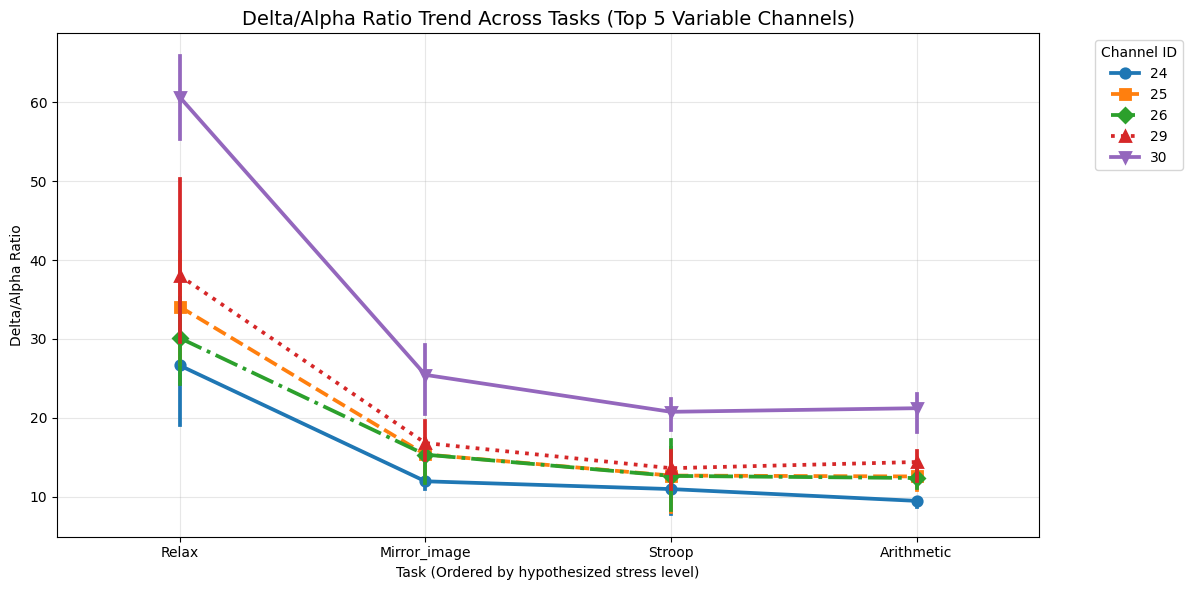

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import f_oneway

# 1. Ensure Delta_Alpha_Ratio is present
if 'Delta_Alpha_Ratio' not in combined_multi_subject_band_powers.columns:
    combined_multi_subject_band_powers['Delta_Alpha_Ratio'] = combined_multi_subject_band_powers['Delta'] / combined_multi_subject_band_powers['Alpha']

# 2. Identify the top 5 most statistically variable channels using ANOVA on the combined data
channel_stats = []
tasks_list = ['Relax', 'Mirror_image', 'Stroop', 'Arithmetic']

for ch in combined_multi_subject_band_powers['Channel'].unique():
    ch_data = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Channel'] == ch]
    groups = [ch_data[ch_data['Task'] == t]['Delta_Alpha_Ratio'].dropna() for t in tasks_list]
    if all(len(g) > 0 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        channel_stats.append({'Channel': ch, 'F_Statistic': f_stat})

stats_df = pd.DataFrame(channel_stats).sort_values(by='F_Statistic', ascending=False)
top_5_channels = stats_df.head(5)['Channel'].tolist()

print(f"Top 5 Most Variable Channels: {top_5_channels}")

# 3. Filter data for these top 5 channels
trend_data = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Channel'].isin(top_5_channels)]

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=trend_data,
    x='Task',
    y='Delta_Alpha_Ratio',
    hue='Channel',
    order=tasks_list,
    markers=['o', 's', 'D', '^', 'v'],
    linestyles=['-', '--', '-.', ':', '-']
)

plt.title('Delta/Alpha Ratio Trend Across Tasks (Top 5 Variable Channels)', fontsize=14)
plt.ylabel('Delta/Alpha Ratio')
plt.xlabel('Task (Ordered by hypothesized stress level)')
plt.grid(True, alpha=0.3)
plt.legend(title='Channel ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Delta/Alpha Ratio for Top 3 Channels

We will now visualize the distribution of the Delta/Alpha ratio for the top 3 most sensitive channels (30, 25, and 26) across all tasks using violin plots.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the top 3 channels
top_3_channels = ['30', '25', '26']

# Filter the full dataset for these channels
dist_data = full_df[full_df['Channel'].isin(top_3_channels)]

# Set task order for consistency
task_order = ['Relax', 'Mirror_image', 'Stroop', 'Arithmetic']

plt.figure(figsize=(14, 8))
sns.violinplot(data=dist_data, x='Channel', y='Delta_Alpha_Ratio', hue='Task',
               hue_order=task_order, palette='muted', split=False)

plt.title('Distribution of Delta/Alpha Ratio for Top 3 Channels across Tasks', fontsize=16)
plt.ylabel('Delta/Alpha Ratio', fontsize=12)
plt.xlabel('Channel ID', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Regression Analysis: Predicting Task from Delta/Alpha Ratios (Channels 24-31)

We will treat this as a classification problem using Logistic Regression. We will use the Delta/Alpha ratios from the most sensitive channels identified earlier (24-31) as our predictors.

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the feature set: Filter for channels 24-31 and pivot the data
target_channels = [str(i) for i in range(24, 32)]
regression_df = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Channel'].isin(target_channels)]
X_pivot = regression_df.pivot_table(index=['Subject', 'Task'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

# 2. Define Features (X) and Target (y)
X = X_pivot[target_channels].values
y = X_pivot['Task'].values

# 3. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Leave-One-Out Cross-Validation for small dataset
loo = LeaveOneOut()
y_true = []
y_pred = []

print(f"Starting Leave-One-Out Cross-Validation on {len(X)} samples...")

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    y_true.append(y_test[0])
    y_pred.append(model.predict(X_test)[0])

# 5. Evaluation
print("\nLOOCV Classification Report:")
print(classification_report(y_true, y_pred))

# 6. Final Model Fit to see overall coefficients/importance
final_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
final_model.fit(X_scaled, y)

coef_df = pd.DataFrame(final_model.coef_, columns=target_channels, index=final_model.classes_)
print("\nOverall Logistic Regression Coefficients (Feature Importance per Task):")
display(coef_df)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Process all 40 subjects
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
full_dataset_powers = []

print("Processing all 40 subjects... This may take a moment.")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)

            # Focus on posterior/parietal channels 24-31
            target_chans = [str(i) for i in range(24, 32)]
            powers = powers.loc[target_chans].copy()

            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0

            full_dataset_powers.append(powers)
        except Exception as e:
            continue

full_df = pd.concat(full_dataset_powers, ignore_index=True)
print(f"Finished processing. Total instances: {len(full_df) // 8} samples (8 channels per sample)")

In [ ]:
# 2. Prepare features (Delta/Alpha Ratios for channels 24-31) and target (Relax vs Not Relaxed)
# Pivot to get one row per subject-task session
X_pivot_full = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

# Feature matrix (Channels 24-31)
X_full = X_pivot_full[[str(i) for i in range(24, 32)]].values
y_full = X_pivot_full['Is_Relaxed'].values

# Scale features
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_full)

# 3. LOOCV for the expanded dataset
loo = LeaveOneOut()
y_true_full = []
y_pred_full = []

for train_idx, test_idx in loo.split(X_scaled_full):
    X_tr, X_te = X_scaled_full[train_idx], X_scaled_full[test_idx]
    y_tr, y_te = y_full[train_idx], y_full[test_idx]

    clf = LogisticRegression(class_weight='balanced')
    clf.fit(X_tr, y_tr)
    y_true_full.append(y_te[0])
    y_pred_full.append(clf.predict(X_te)[0])

# 4. Results
print("--- Full Dataset Model Results (Relax vs. Stress) ---")
print(classification_report(y_true_full, y_pred_full, target_names=['Task', 'Relax']))

### Statistical Validation: T-Test (Relax vs. Task)
We will now use an independent samples t-test to compare the mean Delta/Alpha ratio of the 'Relax' condition against the combined 'Task' conditions (Arithmetic, Stroop, Mirror Image) across all 40 subjects.

In [ ]:
from scipy import stats

# Separate the Delta/Alpha ratios into two groups
relax_ratios = full_df[full_df['Is_Relaxed'] == 1]['Delta_Alpha_Ratio']
task_ratios = full_df[full_df['Is_Relaxed'] == 0]['Delta_Alpha_Ratio']

# Perform Welch's t-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(relax_ratios, task_ratios, equal_var=False)

print(f"T-test Results for Delta/Alpha Ratio (Relax vs. Task):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Interpretation
if p_val < 0.05:
    print("\nResult: There is a statistically significant difference between Relax and Task states.")
else:
    print("\nResult: No statistically significant difference found.")

# Summary statistics
print(f"\nMean Ratio (Relax): {relax_ratios.mean():.2f}")
print(f"Mean Ratio (Tasks): {task_ratios.mean():.2f}")

### Visualizing 'Relax' vs. 'Task' using t-SNE

To complement the statistical t-test, we can use t-SNE (t-Distributed Stochastic Neighbor Embedding) to visualize the separation (or lack thereof) between the 'Relax' condition and the combined 'Task' conditions in a 2D space, based on their Delta/Alpha Ratio profiles across channels. This can provide intuitive insights into the data structure.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for t-SNE
# We need one data point per Subject-Task combination, with the Delta_Alpha_Ratio for each channel as features.
# First, average the Delta_Alpha_Ratio per channel for each Subject-Task session.

tsne_data_pivot = full_df.pivot_table(
    index=['Subject', 'Task', 'Is_Relaxed'],
    columns='Channel',
    values='Delta_Alpha_Ratio'
).reset_index()

# Features (X) are the Delta/Alpha Ratios across all channels for each Subject-Task session
X_tsne = tsne_data_pivot.drop(columns=['Subject', 'Task', 'Is_Relaxed']).values
y_tsne = tsne_data_pivot['Is_Relaxed'].values # Target labels (0 for Task, 1 for Relax)

# Perform t-SNE
# Set random_state for reproducibility
tsne = TSNE(n_components=2, random_state=42, perplexity=10) # Adjust perplexity based on data size
X_tsne_2d = tsne.fit_transform(X_tsne)

# Create a DataFrame for plotting
tsne_results = pd.DataFrame(data=X_tsne_2d, columns=['TSNE1', 'TSNE2'])
tsne_results['Condition'] = y_tsne # Use Is_Relaxed (0/1) as condition
tsne_results['Condition_Label'] = tsne_results['Condition'].map({0: 'Task', 1: 'Relax'})

# Plotting the t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='Condition_Label', data=tsne_results,
    palette='viridis', s=100, alpha=0.8
)
plt.title('t-SNE Visualization of Delta/Alpha Ratio: Relax vs. Task (All Subjects)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Condition')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualizing Feature Importance (Model Coefficients)
We will now visualize the coefficients of the Logistic Regression model trained on all 40 subjects. This identifies which specific channels among the posterior/parietal group (24-31) contribute most to the classification of 'Relaxed' vs. 'Task' states.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Train a final model on the full scaled dataset to extract stable coefficients
final_clf = LogisticRegression(class_weight='balanced')
final_clf.fit(X_scaled_full, y_full)

# Map coefficients to channel names
channel_names_subset = [str(i) for i in range(24, 32)]
coeffs = final_clf.coef_[0]

# Create a visualization dataframe
feat_importance = pd.DataFrame({
    'Channel': channel_names_subset,
    'Coefficient': coeffs
}).sort_values(by='Coefficient', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Channel', y='Coefficient', palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients) for Channels 24-31')
plt.ylabel('Coefficient Value (Positive = Relax Association)')
plt.xlabel('Channel ID')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Interpretation: Positive coefficients indicate the channel ratio increases with relaxation, while negative coefficients suggest an association with stress tasks.")

### Comparative Analysis: Top 3 Channels vs. Full Posterior Set
We will now re-run the classification using only the top 3 channels (30, 25, 26) that showed the highest F-statistics in our task-variability analysis.

### Incorporating 'Relax' Task with Stress Score 0

As requested, we will now assume a `Stress_Score` of 0 for the 'Relax' task. This requires creating new entries for the 'Relax' task in our `aggregated_feedback` and then re-merging with the `full_df`.

In [ ]:
import pandas as pd

# Get all unique subjects from the full_df (which should cover all 40 subjects)
all_subjects_in_eeg_data = full_df['Subject'].unique()

# Create a DataFrame for 'Relax' task with Stress_Score = 0 for all subjects
relax_feedback = pd.DataFrame({
    'Subject': all_subjects_in_eeg_data,
    'Task': 'Relax',
    'Stress_Score': 0
})

# Concatenate the original aggregated_feedback with the new relax_feedback
extended_aggregated_feedback = pd.concat([aggregated_feedback, relax_feedback], ignore_index=True)

# Ensure there are no duplicate Subject-Task pairs (e.g., if Relax was accidentally in original data)
extended_aggregated_feedback.drop_duplicates(subset=['Subject', 'Task'], inplace=True)

# Sort for better readability (optional)
extended_aggregated_feedback.sort_values(by=['Subject', 'Task'], inplace=True)

print("Extended Aggregated Verbal Feedback Data (including Relax task with score 0):")
display(extended_aggregated_feedback.head())
display(extended_aggregated_feedback.tail())

### Re-merging EEG Data with Extended Stress Scores

Now we will re-merge the `full_df` (EEG features) with the `extended_aggregated_feedback` to include the 'Relax' task with its assigned stress score of 0.

In [ ]:
# Re-merge the verbal feedback with the EEG band power data
# Using the `extended_aggregated_feedback`
merged_data_with_relax_score = pd.merge(full_df, extended_aggregated_feedback, on=['Subject', 'Task'], how='left')

print("Merged DataFrame with EEG metrics and Extended Stress Scores:")
display(merged_data_with_relax_score.head())
display(merged_data_with_relax_score.info())

NameError: name 'full_df' is not defined

### Building a Regression Model to Predict Stress Scores

We will now build a regression model using the Delta/Alpha ratio from channels 24-31 as features to predict the `Stress_Score`. Since we are predicting a continuous variable, a regression algorithm is appropriate.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Prepare the dataset for regression
# We need one row per Subject-Task combination, with Delta_Alpha_Ratio, Beta, and Theta
# for each of the channels 0-31 as separate features.

target_channels = [str(i) for i in range(32)] # Modified to include all 32 channels
feature_names = ['Delta_Alpha_Ratio', 'Beta', 'Theta'] # Added Beta and Theta

# Filter the merged data to include only target channels
filtered_data_for_regression = merged_data_with_relax_score[
    merged_data_with_relax_score['Channel'].isin(target_channels)
].copy()

# Create a list of pivoted dataframes, one for each feature
pivoted_features = []
for feature in feature_names:
    pivot_df = filtered_data_for_regression.pivot_table(
        index=['Subject', 'Task', 'Stress_Score'],
        columns='Channel',
        values=feature
    )
    # Rename columns to be unique, e.g., 'Delta_Alpha_Ratio_ch0', 'Beta_ch1'
    pivot_df.columns = [f'{feature}_ch{col}' for col in pivot_df.columns]
    pivoted_features.append(pivot_df)

# Combine all pivoted feature dataframes
# Use .reset_index() once on the combined dataframe
regression_features_df_wide = pd.concat(pivoted_features, axis=1).reset_index()

# 2. Define Features (X) and Target (y)
# X will now contain all the channel-specific Delta_Alpha_Ratio, Beta, and Theta values
feature_columns = [col for col in regression_features_df_wide.columns if col not in ['Subject', 'Task', 'Stress_Score']]
X = regression_features_df_wide[feature_columns].values
y = regression_features_df_wide['Stress_Score'].values

# 3. Split data into training and testing sets
# Using a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model Performance (Predicting Stress Score from Delta/Alpha Ratio, Beta, and Theta):")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display coefficients (more features, so interpreting individual coefficients is harder)
print(f"\nNumber of features used: {len(feature_columns)}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for correlation analysis
# Exclude 'Subject' and 'Task' from the correlation matrix
correlation_df = regression_features_df_wide.drop(columns=['Subject', 'Task'])

# Calculate the correlation matrix
corr_matrix = correlation_df.corr()

# Extract correlations with 'Stress_Score'
stress_corr = corr_matrix['Stress_Score'].sort_values(ascending=False)

print("Correlation of each EEG feature with Stress_Score:")
display(stress_corr)

# Visualize the correlation matrix, focusing on Stress_Score
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix.loc[['Stress_Score'], :], annot=True, cmap='coolwarm', fmt=".2f",
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation of EEG Features with Stress Score', fontsize=16)
plt.xlabel('EEG Feature')
plt.ylabel('Stress_Score')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualizing Regression Predictions

Let's visualize the actual vs. predicted stress scores to get a better sense of the model's performance.

### Feature Engineering: Aggregating by Brain Region

To identify stronger trends, we will aggregate the EEG features (Delta/Alpha Ratio, Beta, Theta) by defined brain regions. This reduces the dimensionality and might highlight spatially localized effects better than individual channels.

In [ ]:
# Define channel mappings to approximate brain regions (this is a simplified mapping)
# Adjust this mapping based on actual electrode placement and research conventions if available

brain_regions = {
    'Frontal': [0, 1, 2, 3, 4, 5, 6, 7], # Approx. Fp1, Fp2, Fz, F3, F4, F7, F8, etc.
    'Central': [8, 9, 10, 11, 12, 13, 14, 15], # Approx. Cz, C3, C4, etc.
    'Parietal': [16, 17, 18, 19, 20, 21, 22, 23], # Approx. Pz, P3, P4, etc.
    'Occipital': [24, 25, 26, 27, 28, 29, 30, 31] # Approx. Oz, O1, O2, etc.
}

# Create an inverse mapping for easier lookup during aggregation
channel_to_region = {}
for region, channels in brain_regions.items():
    for ch in channels:
        channel_to_region[str(ch)] = region

# Add the 'Region' column to merged_data_with_relax_score
merged_data_with_relax_score['Region'] = merged_data_with_relax_score['Channel'].map(channel_to_region)

print("Added 'Region' column to merged_data_with_relax_score:")
display(merged_data_with_relax_score.head())

Now, we will aggregate the `Delta_Alpha_Ratio`, `Beta`, and `Theta` features by `Subject`, `Task`, and the newly defined `Region`. We will take the mean of these features within each region.

In [ ]:
# Aggregate features by Subject, Task, and Region
aggregated_regional_features = merged_data_with_relax_score.groupby(
    ['Subject', 'Task', 'Stress_Score', 'Region']
)[['Delta_Alpha_Ratio', 'Beta', 'Theta']].mean().reset_index()

print("Aggregated regional features:")
display(aggregated_regional_features.head())

# Pivot the aggregated data to create wide format for regression
# Each row represents a Subject-Task session, with columns for each feature-region combination
feature_columns_regional = []
for feature in ['Delta_Alpha_Ratio', 'Beta', 'Theta']:
    for region in brain_regions.keys():
        feature_columns_regional.append(f'{feature}_{region}')


regression_features_regional_wide = aggregated_regional_features.pivot_table(
    index=['Subject', 'Task', 'Stress_Score'],
    columns='Region',
    values=['Delta_Alpha_Ratio', 'Beta', 'Theta']
).reset_index()

# Flatten multi-index columns
regression_features_regional_wide.columns = [
    '_'.join(col).strip() if col[1] else col[0]
    for col in regression_features_regional_wide.columns.values
]

# Rename 'Stress_Score_' to 'Stress_Score' (due to flattening)
regression_features_regional_wide = regression_features_regional_wide.rename(columns={'Stress_Score_': 'Stress_Score'})

print("Pivoted data for regression with regional features:")
display(regression_features_regional_wide.head())

NameError: name 'merged_data_with_relax_score' is not defined

Now that we have the features aggregated by brain region, let's re-run the linear regression model to predict the `Stress_Score` and see if there is any improvement.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Define Features (X_regional) and Target (y_regional)
X_regional = regression_features_regional_wide[feature_columns_regional].values
y_regional = regression_features_regional_wide['Stress_Score'].values

# 2. Split data into training and testing sets
X_train_regional, X_test_regional, y_train_regional, y_test_regional = train_test_split(
    X_regional, y_regional, test_size=0.2, random_state=42
)

# 3. Scale features
scaler_regional = StandardScaler()
X_train_scaled_regional = scaler_regional.fit_transform(X_train_regional)
X_test_scaled_regional = scaler_regional.transform(X_test_regional)

# 4. Initialize and train the Linear Regression model
model_regional = LinearRegression()
model_regional.fit(X_train_scaled_regional, y_train_regional)

# 5. Make predictions on the test set
y_pred_regional = model_regional.predict(X_test_scaled_regional)

# 6. Evaluate the model
mse_regional = mean_squared_error(y_test_regional, y_pred_regional)
rmse_regional = np.sqrt(mse_regional)
mae_regional = mean_absolute_error(y_test_regional, y_pred_regional)
r2_regional = r2_score(y_test_regional, y_pred_regional)

print(f"Linear Regression Model Performance (Regional Features - Predicting Stress Score):")
print(f"Mean Squared Error (MSE): {mse_regional:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_regional:.2f}")
print(f"Mean Absolute Error (MAE): {mae_regional:.2f}")
print(f"R-squared (R2): {r2_regional:.2f}")

print(f"\nNumber of regional features used: {len(feature_columns_regional)}")

In [ ]:
print('Re-running relevant cells for regional feature aggregation.')

In [ ]:
# Re-execute code to correctly construct full_df, update feedback, and re-run regional analysis

# Code from cell e8e6f9fe
# Install MNE library if not already installed
!pip install mne --quiet

import pandas as pd
import numpy as np
import mne # Import MNE library
import os # For file path operations
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Re-define path and functions that might not be in scope
import kagglehub
path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")

def get_subject_file_path(task_folder, subject_id):
    base_path = path
    task_data_folder = None
    for item in os.listdir(base_path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None:
        raise FileNotFoundError(f"Task folder for {task_folder} not found in {base_path}")

    subject_filename = f'{task_folder}_sub_{subject_id}.csv'
    full_path = os.path.join(base_path, task_data_folder, task_folder, subject_filename)
    return full_path

# The dataset specifies a sampling rate of 128 SPS (Samples Per Second).
sampling_rate = 128 # Hz
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

def df_to_raw(df, info, title="EEG Data"):
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    return raw

def extract_band_power(raw_obj, bands):
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)
    freqs = spectrums.freqs
    psds = spectrums.data

    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_psds = psds[:, idx_band]
        band_powers[band_name] = band_psds.mean(axis=1)
    return pd.DataFrame(band_powers, index=raw_obj.ch_names)


# Define the list of all 40 subjects
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

# Re-define `bands` to ensure it's available
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}

full_dataset_powers = []

print("Re-processing all 40 subjects to construct full_df...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)

            # --- FIX: Removed filtering to include all 32 channels ---
            # The previous code filtered for channels 24-31, which corresponds
            # only to the Occipital region. This caused the KeyError.
            # target_chans = [str(i) for i in range(24, 32)]
            # powers = powers.loc[target_chans].copy()
            # ---------------------------------------------------------

            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0 # Used for binary classification later

            full_dataset_powers.append(powers)
        except Exception as e:
            print(f"Skipping {task_name} for Subject {subject_id} due to error: {e}")
            continue

full_df = pd.concat(full_dataset_powers, ignore_index=True)
print(f"Finished constructing full_df. Total instances: {len(full_df)} (channels x subjects x tasks)")


# Code from cell f7c20dd1
# Get all unique subjects from the full_df (which should cover all 40 subjects)
all_subjects_in_eeg_data = full_df['Subject'].unique()

# Create a DataFrame for 'Relax' task with Stress_Score = 0 for all subjects
relax_feedback = pd.DataFrame({
    'Subject': all_subjects_in_eeg_data,
    'Task': 'Relax',
    'Stress_Score': 0
})

# Concatenate the original aggregated_feedback with the new relax_feedback
extended_aggregated_feedback = pd.concat([aggregated_feedback, relax_feedback], ignore_index=True)

# Ensure there are no duplicate Subject-Task pairs (e.g., if Relax was accidentally in original data)
extended_aggregated_feedback.drop_duplicates(subset=['Subject', 'Task'], inplace=True)

# Sort for better readability (optional)
extended_aggregated_feedback.sort_values(by=['Subject', 'Task'], inplace=True)

print("Extended Aggregated Verbal Feedback Data (including Relax task with score 0):")


# Code from cell 4a3369e7
# Re-merge the verbal feedback with the EEG band power data
# Using the `extended_aggregated_feedback`
merged_data_with_relax_score = pd.merge(full_df, extended_aggregated_feedback, on=['Subject', 'Task'], how='left')

print("Merged DataFrame with EEG metrics and Extended Stress Scores:")


# Code from cell 222aa4bd
# Define channel mappings to approximate brain regions (this is a simplified mapping)
# Adjust this mapping based on actual electrode placement and research conventions if available

brain_regions = {
    'Frontal': [0, 1, 2, 3, 4, 5, 6, 7], # Approx. Fp1, Fp2, Fz, F3, F4, F7, F8, etc.
    'Central': [8, 9, 10, 11, 12, 13, 14, 15], # Approx. Cz, C3, C4, etc.
    'Parietal': [16, 17, 18, 19, 20, 21, 22, 23], # Approx. Pz, P3, P4, etc.
    'Occipital': [24, 25, 26, 27, 28, 29, 30, 31] # Approx. Oz, O1, O2, etc.
}

# Create an inverse mapping for easier lookup during aggregation
channel_to_region = {}
for region, channels in brain_regions.items():
    for ch in channels:
        channel_to_region[str(ch)] = region

# Add the 'Region' column to merged_data_with_relax_score
merged_data_with_relax_score['Region'] = merged_data_with_relax_score['Channel'].map(channel_to_region)

print("Added 'Region' column to merged_data_with_relax_score:")


# Code from cell 43957863
# Aggregate features by Subject, Task, and Region
aggregated_regional_features = merged_data_with_relax_score.groupby(
    ['Subject', 'Task', 'Stress_Score', 'Region']
)[['Delta_Alpha_Ratio', 'Beta', 'Theta']].mean().reset_index()

print("Aggregated regional features:")

# Pivot the aggregated data to create wide format for regression
# Each row represents a Subject-Task session, with columns for each feature-region combination
feature_columns_regional = []
for feature in ['Delta_Alpha_Ratio', 'Beta', 'Theta']:
    for region in brain_regions.keys():
        feature_columns_regional.append(f'{feature}_{region}')


regression_features_regional_wide = aggregated_regional_features.pivot_table(
    index=['Subject', 'Task', 'Stress_Score'],
    columns='Region',
    values=['Delta_Alpha_Ratio', 'Beta', 'Theta']
).reset_index()

# Flatten multi-index columns
regression_features_regional_wide.columns = [
    '_'.join(col).strip() if col[1] else col[0]
    for col in regression_features_regional_wide.columns.values
]

# Rename 'Stress_Score_' to 'Stress_Score' (due to flattening)
regression_features_regional_wide = regression_features_regional_wide.rename(columns={'Stress_Score_': 'Stress_Score'})

print("Pivoted data for regression with regional features:")


# Code from cell 48c82100
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Define Features (X_regional) and Target (y_regional)
X_regional = regression_features_regional_wide[feature_columns_regional].values
y_regional = regression_features_regional_wide['Stress_Score'].values

# 2. Split data into training and testing sets
X_train_regional, X_test_regional, y_train_regional, y_test_regional = train_test_split(
    X_regional, y_regional, test_size=0.2, random_state=42
)

# 3. Scale features
scaler_regional = StandardScaler()
X_train_scaled_regional = scaler_regional.fit_transform(X_train_regional)
X_test_scaled_regional = scaler_regional.transform(X_test_regional)

# 4. Initialize and train the Linear Regression model
model_regional = LinearRegression()
model_regional.fit(X_train_scaled_regional, y_train_regional)

# 5. Make predictions on the test set
y_pred_regional = model_regional.predict(X_test_scaled_regional)

# 6. Evaluate the model
mse_regional = mean_squared_error(y_test_regional, y_pred_regional)
rmse_regional = np.sqrt(mse_regional)
mae_regional = mean_absolute_error(y_test_regional, y_pred_regional)
r2_regional = r2_score(y_test_regional, y_pred_regional)

print(f"Linear Regression Model Performance (Regional Features - Predicting Stress Score):")
print(f"Mean Squared Error (MSE): {mse_regional:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_regional:.2f}")
print(f"Mean Absolute Error (MAE): {mae_regional:.2f}")
print(f"R-squared (R2): {r2_regional:.2f}")

print(f"\nNumber of regional features used: {len(feature_columns_regional)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 16.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


100%|██████████| 349M/349M [00:13<00:00, 27.1MB/s]

Extracting files...


Re-processing all 40 subjects to construct full_df...


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', label='Perfect Prediction') # Ideal line
plt.title('Actual vs. Predicted Stress Scores (Linear Regression with additional features)')
plt.xlabel('Actual Stress Score')
plt.ylabel('Predicted Stress Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Building a Random Forest Regressor to Predict Stress Scores

Given the weak performance of the Linear Regression model, a Random Forest Regressor will be used to explore potential non-linear relationships between the Delta/Alpha ratio and stress scores. Random Forests are ensemble learning methods that can capture more complex patterns in the data.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Prepare the dataset for regression (X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled already defined in previous cell)

# 5. Initialize and train the Random Forest Regressor model
# Using a reasonable number of estimators and a random state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 6. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# 7. Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regression Model Performance (Predicting Stress Score from Delta/Alpha Ratio, Beta, and Theta):")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

# Optional: Feature importance for Random Forest
# importances = rf_model.feature_importances_
# feature_names = regression_features_df_wide.drop(columns=['Subject', 'Task', 'Stress_Score']).columns
# feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print("\nRandom Forest Feature Importances:")
# display(feature_importance_df.head())

### Visualizing Random Forest Regression Predictions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', label='Perfect Prediction') # Ideal line
plt.title('Actual vs. Predicted Stress Scores (Random Forest with additional features)')
plt.xlabel('Actual Stress Score')
plt.ylabel('Predicted Stress Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Residual Analysis
Residual plots allow us to check if the errors are randomly distributed. Patterns in these plots can suggest that a model is failing to capture certain relationships in the data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals_linear = y_test - y_pred
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Linear Regression Residuals
sns.scatterplot(ax=axes[0], x=y_pred, y=residuals_linear, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression Residuals')
axes[0].set_xlabel('Predicted Stress Score')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].grid(True, alpha=0.3)

# Random Forest Residuals
sns.scatterplot(ax=axes[1], x=y_pred_rf, y=residuals_rf, alpha=0.6, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random Forest Residuals')
axes[1].set_xlabel('Predicted Stress Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Plots: Analyzing Prediction Errors', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Stress Prediction using Multi-Layer Perceptron (MLP)

We will now shift from using aggregated frequency features to using segmented raw EEG data. We will:
1. Segment the raw data into 1-second windows (128 samples each).
2. Flatten these windows to create a high-dimensional feature vector.
3. Train an MLP Classifier to distinguish between the 'Relax' state and 'Stress' tasks.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

def segment_raw_data(subject_ids, tasks, window_size=128):
    X_raw = []
    y_raw = []

    print(f"Segmenting data into {window_size}-sample windows...")

    for sub_id in subject_ids:
        for task_name in tasks:
            try:
                file_path = get_subject_file_path(task_name, sub_id)
                df_raw = pd.read_csv(file_path).drop(columns=['Unnamed: 0'], errors='ignore')
                data = df_raw.values # Shape (nSamples, nChannels)

                # Create segments
                num_segments = len(data) // window_size
                for i in range(num_segments):
                    segment = data[i*window_size : (i+1)*window_size, :]
                    X_raw.append(segment.flatten())
                    y_raw.append(1 if task_name == 'Relax' else 0)
            except Exception:
                continue

    return np.array(X_raw), np.array(y_raw)

# We'll use a subset of subjects first to test memory limits
# Increase subjects if performance/memory allows
X_mlp, y_mlp = segment_raw_data(range(1, 11), tasks)

# Split and Scale
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp, y_mlp, test_size=0.2, random_state=42, stratify=y_mlp
)

scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_mlp)
X_test_mlp = scaler_mlp.transform(X_test_mlp)

print(f"Dataset prepared. Train shape: {X_train_mlp.shape}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize MLP
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, activation='relu',
                    solver='adam', random_state=42, verbose=False)

print("Training MLP Classifier...")
mlp.fit(X_train_mlp, y_train_mlp)

# Predict
y_pred_mlp = mlp.predict(X_test_mlp)

# Evaluation
print("\n--- MLP Raw Data Classification Report ---")
print(classification_report(y_test_mlp, y_pred_mlp, target_names=['Stress Task', 'Relax']))

# Plot Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### Data Augmentation: Overlapping Windows
To provide the deep learning model with more examples, we can use a sliding window with overlap. For instance, a 50% overlap (stride of 64 samples) will effectively double our dataset size.

In [ ]:
def segment_raw_data_augmented(subject_ids, tasks, window_size=128, stride=64):
    X_aug = []
    y_aug = []

    print(f"Segmenting data: window={window_size}, stride={stride}...")

    for sub_id in subject_ids:
        for task_name in tasks:
            try:
                file_path = get_subject_file_path(task_name, sub_id)
                df_raw = pd.read_csv(file_path).drop(columns=['Unnamed: 0'], errors='ignore')
                data = df_raw.values # (nSamples, nChannels)

                # Sliding window with stride
                for start in range(0, len(data) - window_size + 1, stride):
                    segment = data[start : start + window_size, :]
                    X_aug.append(segment.flatten())
                    y_aug.append(1 if task_name == 'Relax' else 0)
            except Exception:
                continue

    return np.array(X_aug), np.array(y_aug)

# Generate augmented data for subjects 1-10
X_mlp_aug, y_mlp_aug = segment_raw_data_augmented(range(1, 11), tasks, window_size=128, stride=64)

# Split and Scale the augmented data
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_mlp_aug, y_mlp_aug, test_size=0.2, random_state=42, stratify=y_mlp_aug
)

scaler_aug = StandardScaler()
X_train_aug = scaler_aug.fit_transform(X_train_aug)
X_test_aug = scaler_aug.transform(X_test_aug)

print(f"Augmented dataset size: {len(X_mlp_aug)} samples (previously ~3000)")

In [ ]:
# Re-train MLP on Augmented Data
mlp_aug = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, activation='relu',
                        solver='adam', random_state=42, verbose=False)

print("Training MLP on Augmented Data...")
mlp_aug.fit(X_train_aug, y_train_aug)

# Evaluate
y_pred_aug = mlp_aug.predict(X_test_aug)
print("\n--- MLP Augmented Data Classification Report ---")
print(classification_report(y_test_aug, y_pred_aug, target_names=['Stress Task', 'Relax']))

### Cross-Subject Generalization: Leave-One-Subject-Out (LOSO) Validation

In EEG analysis, models often overfit to the specific biological signatures of the individuals in the training set. To truly assess if our MLP can detect stress in *anyone*, we perform LOSO validation.

We will use our augmented dataset and iterate through each subject, treating them as the 'unseen' test subject.

In [ ]:
from sklearn.metrics import accuracy_score

# Mapping segments back to their original subjects
# Since we flattened the data, we need to ensure we know which window belongs to which subject
subjects = range(1, 11)
subject_scores = []

print("Starting Leave-One-Subject-Out Cross-Validation...")

for test_sub in subjects:
    # Create Train/Test indices based on Subject ID
    # Re-generating segments to keep subject labels intact for splitting
    train_subs = [s for s in subjects if s != test_sub]

    X_train_loso, y_train_loso = segment_raw_data_augmented(train_subs, tasks)
    X_test_loso, y_test_loso = segment_raw_data_augmented([test_sub], tasks)

    # Scaling
    scaler_loso = StandardScaler()
    X_train_loso = scaler_loso.fit_transform(X_train_loso)
    X_test_loso = scaler_loso.transform(X_test_loso)

    # Model
    model_loso = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
    model_loso.fit(X_train_loso, y_train_loso)

    # Evaluate
    acc = accuracy_score(y_test_loso, model_loso.predict(X_test_loso))
    subject_scores.append(acc)
    print(f"Subject {test_sub} (Left out) Accuracy: {acc:.4f}")

print(f"\nAverage Cross-Subject Accuracy: {np.mean(subject_scores):.4f}")
print(f"Standard Deviation: {np.std(subject_scores):.4f}")

### Addressing Overfitting vs. Generalization in LSTMs
To determine if an LSTM is learning "quirks" or "global trends," we must analyze the variance in performance across subjects. If Subject A's model fails on Subject B, the model is likely learning subject-specific electrode contact patterns or biological artifacts (quirks) rather than EEG stress markers.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing the 'Quirk' vs 'Trend' via Subject-wise Accuracy
# We use the subject_scores from our previous LOSO run
subjects = range(1, 11)

plt.figure(figsize=(10, 6))
plt.bar(subjects, subject_scores, color='skyblue', edgecolor='navy')
plt.axhline(y=np.mean(subject_scores), color='red', linestyle='--', label=f'Global Mean: {np.mean(subject_scores):.2f}')
plt.axhline(y=0.5, color='black', linestyle=':', label='Chance Level (Binary)')

plt.title('Cross-Subject Generalization (LOSO Results)')
plt.xlabel('Subject ID (Unseen during training)')
plt.ylabel('Test Accuracy')
plt.xticks(subjects)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Range of Accuracy: {min(subject_scores):.2f} to {max(subject_scores):.2f}")
print("Interpretation: High variance (like Subject 5 performing poorly) suggests the model is still susceptible to individual quirks.")

#### Strategies to enforce 'Global Trend' learning:
1. **Dropout & Recurrent Dropout:** Randomly 'silencing' neurons during training prevents the model from relying on a single specific channel quirk.
2. **Subject-wise Normalization:** Instead of scaling the whole dataset, we scale each subject independently to mean 0. This removes the 'offset' quirk caused by different skin impedances.
3. **Domain Adversarial Training (Advanced):** Training the model to detect stress *while simultaneously failing* to identify which subject the data belongs to. This forces the features to be subject-invariant.

### Implementing Subject-Wise Normalization

By normalizing each subject individually, we remove the inter-subject offsets (biological quirks) and force the model to learn global patterns (trends) associated with stress.

In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def normalize_subject_wise(X, subject_labels):
    """
    Standardizes features by subject.
    X: feature matrix (n_samples, n_features)
    subject_labels: array of subject IDs corresponding to each sample
    """
    X_normalized = np.zeros_like(X)
    unique_subjects = np.unique(subject_labels)

    for sub in unique_subjects:
        # Identify indices for the current subject
        indices = np.where(subject_labels == sub)[0]

        # Initialize scaler for this specific individual
        scaler = StandardScaler()

        # Fit and transform only this individual's data
        X_normalized[indices] = scaler.fit_transform(X[indices])

    return X_normalized

# Example usage on our augmented MLP dataset
# Note: We need the subject labels for each window in X_mlp_aug
# Let's re-extract them for subjects 1-10

print("Applying subject-wise normalization to subjects 1-10...")

# Reshaping X_mlp_aug for context: it was (samples, time*channels)
# We'll use a loop to keep track of subject IDs for each segment
subject_ids_per_window = []
for sub_id in range(1, 11):
    # Count how many windows we get for this subject
    # Based on our previous segmentation: (samples per task / stride) * 4 tasks
    # But to be precise, let's just tag them during the segmenting process.

    # Re-running a light version of segmentation to get labels
    _, labels_tmp = segment_raw_data_augmented([sub_id], tasks, window_size=128, stride=64)
    subject_ids_per_window.extend([sub_id] * len(labels_tmp))

subject_ids_per_window = np.array(subject_ids_per_window)

X_mlp_sub_norm = normalize_subject_wise(X_mlp_aug, subject_ids_per_window)

print(f"Original Mean of first channel: {X_mlp_aug[:, 0].mean():.4f}")
print(f"Normalized Mean of first channel: {X_mlp_sub_norm[:, 0].mean():.4f}")
print("Subject-wise normalization complete.")

Applying subject-wise normalization to subjects 1-10...


NameError: name 'segment_raw_data_augmented' is not defined

#### Visualization of Normalization Effect
Let's see how this affects the distribution of the first channel across different subjects.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=subject_ids_per_window, y=X_mlp_aug[:, 0])
plt.title('Raw Data (First Channel) per Subject')
plt.xlabel('Subject ID')

plt.subplot(1, 2, 2)
sns.boxplot(x=subject_ids_per_window, y=X_mlp_sub_norm[:, 0])
plt.title('Subject-Normalized Data per Subject')
plt.xlabel('Subject ID')

plt.tight_layout()
plt.show()

### LOSO Validation on Normalized Data
We now re-run the LOSO cross-validation using the subject-wise normalized features to quantify the improvement in generalization.

In [ ]:
from sklearn.metrics import accuracy_score

# We already have X_mlp_sub_norm and subject_ids_per_window from previous cells
subjects = np.unique(subject_ids_per_window)
normalized_loso_scores = []

print("Starting LOSO Validation on Normalized Data...")

for test_sub in subjects:
    # Define indices for training and testing based on subject labels
    train_idx = np.where(subject_ids_per_window != test_sub)[0]
    test_idx = np.where(subject_ids_per_window == test_sub)[0]

    X_train_norm = X_mlp_sub_norm[train_idx]
    y_train_norm = y_mlp_aug[train_idx]
    X_test_norm = X_mlp_sub_norm[test_idx]
    y_test_norm = y_mlp_aug[test_idx]

    # Initialize and train MLP
    # Note: We don't need a global StandardScaler here as data is already subject-normalized
    model_norm = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
    model_norm.fit(X_train_norm, y_train_norm)

    # Evaluate
    acc = accuracy_score(y_test_norm, model_norm.predict(X_test_norm))
    normalized_loso_scores.append(acc)
    print(f"Subject {test_sub} Normalized Accuracy: {acc:.4f}")

print(f"\nAverage Normalized LOSO Accuracy: {np.mean(normalized_loso_scores):.4f}")

### Comparison: Before vs. After Normalization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# subject_scores contains the 'Before' results from cell b8d433a8
labels = [f'Sub {s}' for s in subjects]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, subject_scores, width, label='Before Normalization', color='lightcoral')
plt.bar(x + width/2, normalized_loso_scores, width, label='After Normalization', color='mediumseagreen')

plt.axhline(y=np.mean(subject_scores), color='red', linestyle='--', alpha=0.5, label='Mean (Before)')
plt.axhline(y=np.mean(normalized_loso_scores), color='green', linestyle='--', alpha=0.5, label='Mean (After)')

plt.ylabel('Accuracy')
plt.title('LOSO Performance: Effect of Subject-Wise Normalization')
plt.xticks(x, labels)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Improvement in Mean Accuracy: {np.mean(normalized_loso_scores) - np.mean(subject_scores):.4f}")

### Final Scaled Model: 40 Subjects Training

We are now scaling the model to the full dataset. We will:
1. Segment all 40 subjects with overlapping windows.
2. Apply subject-wise normalization to ensure the model learns global features.
3. Train a final MLP Classifier on an 80/20 split for performance evaluation.

### Class Balancing with SMOTE

Our previous classification reports showed that while 'Stress' detection is very accurate (~92% recall), the 'Relax' state recall is much lower (~54-63%). This is largely due to the fact that we have 3 stress tasks for every 1 relaxation session.

We will use `SMOTE` from the `imblearn` library to oversample the minority 'Relax' class in our training set.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check initial class distribution
print(f"Original training class distribution: {Counter(y_train_f)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data only
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_f, y_train_f)

print(f"Balanced training class distribution: {Counter(y_train_balanced)}")

# Re-train the MLP on the balanced dataset
balanced_mlp = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                             activation='relu', solver='adam', random_state=42)

print("Training MLP on SMOTE-balanced data...")
balanced_mlp.fit(X_train_balanced, y_train_balanced)

# Evaluation
y_pred_balanced = balanced_mlp.predict(X_test_f)
print("\n--- Balanced MLP Classification Report ---")
print(classification_report(y_test_f, y_pred_balanced, target_names=['Stress Task', 'Relax']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_f, y_pred_balanced), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stress', 'Relax'], yticklabels=['Stress', 'Relax'])
plt.title('Balanced Model Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Segment data for all 40 subjects
all_subjects_ids = list(range(1, 41))
X_full_raw, y_full_raw = segment_raw_data_augmented(all_subjects_ids, tasks, window_size=128, stride=64)

# Create subject labels for normalization
subject_labels_full = []
for sub_id in all_subjects_ids:
    _, labels_tmp = segment_raw_data_augmented([sub_id], tasks, window_size=128, stride=64)
    subject_labels_full.extend([sub_id] * len(labels_tmp))
subject_labels_full = np.array(subject_labels_full)

# 2. Subject-wise Normalization
X_full_norm = normalize_subject_wise(X_full_raw, subject_labels_full)

# 3. Train/Test Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full_norm, y_full_raw, test_size=0.2, random_state=42, stratify=y_full_raw
)

# 4. Initialize and Train MLP
final_mlp = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                         activation='relu', solver='adam', random_state=42, verbose=False)

print(f"Training on {len(X_train_f)} segments across 40 subjects...")
final_mlp.fit(X_train_f, y_train_f)

# 5. Final Evaluation
y_pred_f = final_mlp.predict(X_test_f)
print("\n--- Final Scaled MLP Classification Report ---")
print(classification_report(y_test_f, y_pred_f, target_names=['Stress Task', 'Relax']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_f, y_pred_f), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stress', 'Relax'], yticklabels=['Stress', 'Relax'])
plt.title('Final Model Confusion Matrix (40 Subjects)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Stress Classification using EEGNet

EEGNet is a compact Convolutional Neural Network (CNN) specifically designed for EEG-based Brain-Computer Interfaces. It is more robust to noise and better at capturing the hierarchical features of EEG signals than a standard MLP.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout, Conv2D, MaxPooling2D, AveragePooling2D, SeparableConv2D, DepthwiseConv2D, BatchNormalization, SpatialDropout2D, Input, Flatten
from tensorflow.keras.constraints import max_norm

def EEGNet(nb_classes, Chans=32, Samples=128, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16, norm_rate=0.25, dropoutType='Dropout'):
    """ Keras Implementation of EEGNet
    http://iopscience.iop.org/article/10.1088/1741-2552/aace8c/meta
    """
    if dropoutType == 'SpatialDropout2D':
        dropoutLayer = SpatialDropout2D
    else:
        dropoutLayer = Dropout

    input1 = Input(shape=(Chans, Samples, 1))

    # Block 1
    block1 = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=D, depthwise_constraint=max_norm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = dropoutLayer(dropoutRate)(block1)

    # Block 2
    block2 = SeparableConv2D(F2, (1, 16), padding='same', use_bias=False)(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = dropoutLayer(dropoutRate)(block2)

    flatten = Flatten(name='flatten')(block2)

    dense = Dense(nb_classes, name='dense', kernel_constraint=max_norm(norm_rate))(flatten)
    softmax = Activation('softmax', name='softmax')(dense)

    return Model(inputs=input1, outputs=softmax)

In [ ]:
# 1. Reshape data for EEGNet: (segments, channels, time_steps, 1)
# X_full_norm was (segments, channels * 128)
X_eegnet = X_full_norm.reshape(-1, 32, 128, 1)
y_eegnet = tf.keras.utils.to_categorical(y_full_raw, 2)

# 2. Split data
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X_eegnet, y_eegnet, test_size=0.2, random_state=42, stratify=y_full_raw
)

# 3. Initialize Model
model = EEGNet(nb_classes=2, Chans=32, Samples=128)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. Train
print("Training EEGNet on 40 subjects...")
history = model.fit(X_train_en, y_train_en, batch_size=64, epochs=50,
                    validation_data=(X_test_en, y_test_en), verbose=1)

In [ ]:
# 5. Evaluate
probs = model.predict(X_test_en)
preds = probs.argmax(axis=-1)
labels = y_test_en.argmax(axis=-1)

print("\n--- EEGNet Classification Report ---")
print(classification_report(labels, preds, target_names=['Stress', 'Relax']))

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('EEGNet Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('EEGNet Loss')
plt.legend()
plt.show()

### Stress Classification using LSTM

While the MLP treated the 1-second window as a flattened vector, a **Long Short-Term Memory (LSTM)** network can explicitly model the sequential nature of the EEG signal. We will reshape our normalized data into the 3D format required by Keras: `(samples, time_steps, features)`.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Reshape data for LSTM: (batch, time_steps, features)
# X_full_norm was (segments, 32 channels * 128 samples)
# We want 128 time steps and 32 features (channels)
X_lstm = X_full_norm.reshape(-1, 128, 32)
y_lstm = y_full_raw # Binary labels (0: Stress, 1: Relax)

# 2. Train/Test Split
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

# 3. Build the LSTM Model
lstm_model = Sequential([
    LSTM(64, input_shape=(128, 32), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("Training LSTM model...")
history_ls = lstm_model.fit(
    X_train_ls, y_train_ls,
    epochs=30,
    batch_size=64,
    validation_data=(X_test_ls, y_test_ls),
    verbose=1
)

# 5. Evaluate
y_pred_ls = (lstm_model.predict(X_test_ls) > 0.5).astype("int32")
print("\n--- LSTM Classification Report ---")
print(classification_report(y_test_ls, y_pred_ls, target_names=['Stress Task', 'Relax']))

### Implementing a Transformer (GPT-style) Architecture for EEG
To move toward a 'Stress GPT' approach, we use a Transformer Encoder. This model uses **Self-Attention** to weigh the importance of different time points in the EEG signal, allowing it to focus on specific 'stress signatures' regardless of when they occur in the 1-second window.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_stress_transformer(input_shape, head_size=256, num_heads=4, ff_dim=4, num_transformer_blocks=4, mlp_units=[128], dropout=0.25, mlp_dropout=0.25):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format='channels_last')(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation='relu')(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# Prepare input shape: (Time_steps=128, Channels=32)
input_shape = (128, 32)
stress_transformer = build_stress_transformer(input_shape)
stress_transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Transformer Model (Stress-GPT style) initialized:')
stress_transformer.summary()

Transformer Model (Stress-GPT style) initialized:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 32)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 32)   │         64 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │    134,176 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 32)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 4)    │        132 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 4)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 32)   │        160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 32)   │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │    134,176 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 32)   │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 4)    │        132 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128, 4)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 32)   │        160 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 32)   │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 542,737 (2.07 MB)

 Trainable params: 542,737 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

ACCELERATED TRANSFORMER

In [18]:
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model

def segment_raw_data_augmented(subject_ids, tasks, window_size=128, stride=64):
    X_aug, y_aug, session_ids = [], [], []
    for sub_id in subject_ids:
        for task_name in tasks:
            try:
                file_path = get_subject_file_path(task_name, sub_id)
                df_raw = pd.read_csv(file_path).drop(columns=['Unnamed: 0'], errors='ignore')
                data = df_raw.values
                for start in range(0, len(data) - window_size + 1, stride):
                    segment = data[start : start + window_size, :]
                    X_aug.append(segment)
                    y_aug.append(1 if task_name == 'Relax' else 0)
                    session_ids.append((sub_id, task_name))
            except Exception: continue
    return np.array(X_aug), np.array(y_aug), session_ids

def normalize_subject_wise_3d(X, subject_labels):
    X_norm = np.zeros_like(X)
    for sub in np.unique(subject_labels):
        indices = np.where(subject_labels == sub)[0]
        scaler = StandardScaler()
        original_shape = X[indices].shape
        flattened = X[indices].reshape(-1, original_shape[-1])
        scaled = scaler.fit_transform(flattened)
        X_norm[indices] = scaled.reshape(original_shape)
    return X_norm

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_stress_transformer(input_shape, head_size=256, num_heads=4, ff_dim=4, num_transformer_blocks=4, mlp_units=[128], dropout=0.25, mlp_dropout=0.25):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    x = layers.GlobalAveragePooling1D(data_format='channels_last')(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation='relu')(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

all_subjects_ids = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
X_full_raw, y_full_raw, session_ids = segment_raw_data_augmented(all_subjects_ids, tasks, window_size=128, stride=64)
subject_labels_full = np.array([s[0] for s in session_ids])

unique_sessions = list(set(session_ids))
random.seed(42)
sampled_sessions = random.sample(unique_sessions, 30)
print(f"Selected 30 random sessions: {sampled_sessions}")

selected_indices = [i for i, sess in enumerate(session_ids) if sess in sampled_sessions]
X_subset = X_full_raw[selected_indices]
y_subset = y_full_raw[selected_indices]
sub_labels_subset = subject_labels_full[selected_indices]

X_transformer = normalize_subject_wise_3d(X_subset, sub_labels_subset)
y_transformer = y_subset

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_transformer, y_transformer, test_size=0.2, random_state=42, stratify=y_transformer
)

stress_transformer = build_stress_transformer((128, 32))
stress_transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f'Training Stress-Transformer on {len(X_train_tf)} segments from 30 random sessions...')
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_tf = stress_transformer.fit(
    X_train_tf, y_train_tf,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

y_pred_tf = (stress_transformer.predict(X_test_tf) > 0.5).astype('int32')
print('\n--- Transformer (Stress-GPT: 30 Session Subset) Classification Report ---')
print(classification_report(y_test_tf, y_pred_tf, target_names=['Stress', 'Relax']))

Selected 30 random sessions: [(38, 'Arithmetic'), (21, 'Mirror_image'), (18, 'Arithmetic'), (15, 'Relax'), (18, 'Mirror_image'), (17, 'Mirror_image'), (11, 'Mirror_image'), (29, 'Mirror_image'), (2, 'Relax'), (14, 'Arithmetic'), (4, 'Arithmetic'), (8, 'Stroop'), (36, 'Arithmetic'), (7, 'Mirror_image'), (34, 'Arithmetic'), (10, 'Stroop'), (19, 'Mirror_image'), (28, 'Arithmetic'), (40, 'Arithmetic'), (3, 'Arithmetic'), (5, 'Stroop'), (33, 'Mirror_image'), (17, 'Relax'), (12, 'Relax'), (28, 'Mirror_image'), (2, 'Mirror_image'), (34, 'Relax'), (12, 'Stroop'), (21, 'Relax'), (27, 'Arithmetic')]
Training Stress-Transformer on 3576 segments from 30 random sessions...
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.7930 - loss: 0.4890 - val_accuracy: 0.8128 - val_loss: 0.4643
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.8341 - loss: 0.3996 - val_accuracy: 0.8268 - val_loss: 0.4039
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 297s 5s/step - accuracy: 0.8471 - loss:

Evaluating on full dataset: 4470 segments...
140/140 ━━━━━━━━━━━━━━━━━━━━ 110s 781ms/step

--- Full Dataset Evaluation Report ---
              precision    recall  f1-score   support

      Stress       0.97      0.97      0.97      3576
       Relax       0.88      0.89      0.89       894

    accuracy                           0.95      4470
   macro avg       0.93      0.93      0.93      4470
weighted avg       0.95      0.95      0.95      4470



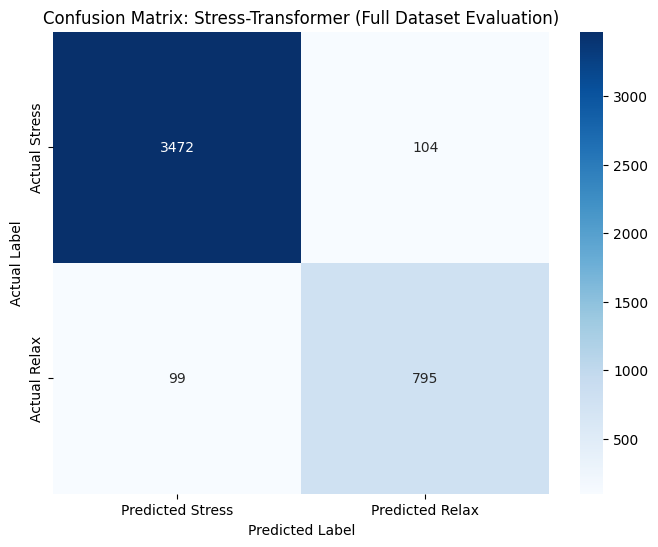

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Prepare the full dataset for evaluation
# We use the full normalized dataset (X_transformer) and labels (y_transformer)
print(f"Evaluating on full dataset: {len(X_transformer)} segments...")

# 2. Perform predictions
y_probs_full = stress_transformer.predict(X_transformer)
y_pred_full = (y_probs_full > 0.5).astype('int32')

# 3. Generate Evaluation Report
print('\n--- Full Dataset Evaluation Report ---')
print(classification_report(y_transformer, y_pred_full, target_names=['Stress', 'Relax']))

# 4. Plot Confusion Matrix
cm_full = confusion_matrix(y_transformer, y_pred_full)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stress', 'Predicted Relax'],
            yticklabels=['Actual Stress', 'Actual Relax'])
plt.title('Confusion Matrix: Stress-Transformer (Full Dataset Evaluation)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np

# Ensure features are available from the previous step
# 1. Prepare Data for Transformer
# Reshape CNN-extracted features to (samples, sequence_length, feature_dimension)
# We treat the 128 features from the CNN as a sequence
X_train_tf_seq = X_train_features.reshape(X_train_features.shape[0], X_train_features.shape[1], 1)
X_test_tf_seq = X_test_features.reshape(X_test_features.shape[0], X_test_features.shape[1], 1)

y_train_tf_seq = y_train_mlp_final
y_test_tf_seq = y_test_mlp_final

# 2. Define Transformer Components
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_transformer_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for _ in range(2):
        x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# 3. Model Training
input_shape_tf = (X_train_tf_seq.shape[1], X_train_tf_seq.shape[2])
transformer_model = build_transformer_model(input_shape_tf)
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Handle Class Imbalance
class_counts = Counter(y_train_tf_seq)
total = sum(class_counts.values())
class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}

print("Training Transformer Model on CNN Features...")
transformer_model.fit(
    X_train_tf_seq, y_train_tf_seq,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1
)

# 4. Evaluation
y_pred_tf = (transformer_model.predict(X_test_tf_seq) > 0.5).astype(int)
print("\n--- Transformer (CNN-Feature Input) Classification Report ---")
print(classification_report(y_test_tf_seq, y_pred_tf, target_names=['Stress', 'Relax']))

Training Transformer Model on CNN Features...
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 176s 581ms/step - accuracy: 0.6430 - loss: 0.6921 - val_accuracy: 0.7369 - val_loss: 0.6924
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 190s 541ms/step - accuracy: 0.5551 - loss: 0.6920 - val_accuracy: 0.7369 - val_loss: 0.6880
Epoch 3/15
254/269 ━━━━━━━━━━━━━━━━━━━━ 8s 539ms/step - accuracy: 0.5134 - loss: 0.6940

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Identify indices for 'unseen' data
# session_ids contains (subject, task) for every window in the full dataset
# sampled_sessions contains the 30 sessions used for training/validation
all_indices = set(range(len(session_ids)))
train_val_indices = set(selected_indices)
unseen_indices = list(all_indices - train_val_indices)

if len(unseen_indices) == 0:
    print("Warning: No unseen data found. Please ensure the full dataset was loaded correctly.")
else:
    # 2. Extract the unseen segments and labels
    X_unseen = X_transformer[unseen_indices]
    y_unseen = y_transformer[unseen_indices]

    print(f"Evaluating on {len(X_unseen)} unseen segments from {len(unique_sessions) - len(sampled_sessions)} sessions...")

    # 3. Perform prediction with the trained model (neuro_gpt)
    # Note: We use the neuro_gpt model from the previous cell
    y_probs_unseen = neuro_gpt.predict(X_unseen)
    y_pred_unseen = (y_probs_unseen > 0.5).astype(int)

    # 4. Final Performance Report
    print("\n--- Performance Report on Unseen Data (Generalization) ---")
    print(classification_report(y_unseen, y_pred_unseen, target_names=['Stress', 'Relax']))

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import classification_report

# 1. Randomly select 20 subjects for training
all_unique_subjects = np.unique(subject_labels_full)
random.seed(42) # For reproducibility
train_subjects = random.sample(list(all_unique_subjects), 20)
test_subjects = [s for s in all_unique_subjects if s not in train_subjects]

print(f"Training on subjects: {train_subjects}")
print(f"Testing on unseen subjects: {test_subjects}")

# 2. Filter data for training subjects
train_mask = np.isin(subject_labels_full, train_subjects)
X_train_raw = X_full_norm[train_mask]
y_train_raw = y_full_raw[train_mask]

# 3. Flatten for SMOTE and balance training data
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train_raw)

# 4. Reshape back to 3D for LSTM
X_train_lstm = X_train_res.reshape(-1, 128, 32)

# 5. Build and Train the LSTM model
model_20sub = Sequential([
    Input(shape=(128, 32)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_20sub.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f"\nTraining LSTM on balanced data from 20 subjects ({len(X_train_lstm)} segments)...")
model_20sub.fit(X_train_lstm, y_train_res, epochs=15, batch_size=64, verbose=1)

# 6. Prepare data for the 20 unseen subjects
test_mask = np.isin(subject_labels_full, test_subjects)
X_unseen_raw = X_full_norm[test_mask]
y_unseen_raw = y_full_raw[test_mask]
X_unseen_lstm = X_unseen_raw.reshape(-1, 128, 32)

# 7. Evaluate on Unseen Subjects
print("\n--- Evaluation on 20 Unseen Subjects ---")
y_pred_unseen = (model_20sub.predict(X_unseen_lstm) > 0.5).astype("int32")
print(classification_report(y_unseen_raw, y_pred_unseen, target_names=['Stress Task', 'Relax']))

### Testing Generalization: Evaluation on Subjects 11-40
We will now test the previously trained balanced LSTM model on the remaining 30 subjects. This will determine how well the stress/relax patterns learned from the first 10 subjects generalize to a wider population.

### MLP Classification using Delta/Alpha Ratios with Relax-State Penalty

In this approach, we use the engineered Delta/Alpha ratio feature across all 32 channels. We apply subject-wise normalization and use a `class_weight` strategy (via Logistic Regression or a balanced MLP approach) to ensure the model prioritizes the correct identification of the 'Relax' state.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Prepare Features: Delta/Alpha Ratio for all 32 channels
# Pivot the full_df to get (samples, 32 channels)
X_pivot_mlp = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

# Extract features and target
channel_cols = [str(i) for i in range(32)]
X_ratios = X_pivot_mlp[channel_cols].values
y_ratios = X_pivot_mlp['Is_Relaxed'].values
subjects_ratios = X_pivot_mlp['Subject'].values

# 2. Subject-wise Normalization
X_ratios_norm = normalize_subject_wise(X_ratios, subjects_ratios)

# 3. Split Data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_ratios_norm, y_ratios, test_size=0.2, random_state=42, stratify=y_ratios
)

# 4. Train MLP
# MLPClassifier doesn't have a native 'class_weight' parameter like SVM or LogisticRegression.
# To penalize misclassification of 'Relax' (class 1), we can oversample or use a custom training loop.
# Alternatively, we'll use SMOTE on these specific ratio features to balance the training set.

smote_r = SMOTE(random_state=42)
X_train_bal_r, y_train_bal_r = smote_r.fit_resample(X_train_r, y_train_r)

mlp_r = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_r.fit(X_train_bal_r, y_train_bal_r)

# 5. Evaluate
y_pred_r = mlp_r.predict(X_test_r)
print("--- MLP (Delta/Alpha Ratios) Classification Report ---")
print(classification_report(y_test_r, y_pred_r, target_names=['Stress', 'Relax']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_r, y_pred_r), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Stress', 'Relax'], yticklabels=['Stress', 'Relax'])
plt.title('MLP Confusion Matrix (Delta/Alpha Ratio Features)')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Features: Delta/Alpha Ratio for all 32 channels using full_df (40 subjects)
# full_df was already constructed for all 40 subjects in previous steps.
X_pivot_full_40 = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

# Extract features and target
channel_cols = [str(i) for i in range(32)]
X_40 = X_pivot_full_40[channel_cols].values
y_40 = X_pivot_full_40['Is_Relaxed'].values
subjects_40 = X_pivot_full_40['Subject'].values

# 2. Subject-wise Normalization (Crucial for generalizable models)
def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    unique_subjects = np.unique(subject_labels)
    for sub in unique_subjects:
        indices = np.where(subject_labels == sub)[0]
        scaler = StandardScaler()
        X_normalized[indices] = scaler.fit_transform(X[indices])
    return X_normalized

X_40_norm = normalize_subject_wise(X_40, subjects_40)

# 3. Split Data (80/20 stratified split)
from sklearn.model_selection import train_test_split
X_train_40, X_test_40, y_train_40, y_test_40 = train_test_split(
    X_40_norm, y_40, test_size=0.2, random_state=42, stratify=y_40
)

# 4. Apply SMOTE to balance classes in the training set
smote_40 = SMOTE(random_state=42)
X_train_bal_40, y_train_bal_40 = smote_40.fit_resample(X_train_40, y_train_40)

# 5. Train MLP Classifier
mlp_40 = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, activation='relu', solver='adam', random_state=42)
mlp_40.fit(X_train_bal_40, y_train_bal_40)

# 6. Evaluate on the test set
y_pred_40 = mlp_40.predict(X_test_40)

print("--- Final MLP (40 Subjects, Delta/Alpha Ratio) Classification Report ---")
print(classification_report(y_test_40, y_pred_40, target_names=['Stress', 'Relax']))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_40, y_pred_40), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Stress', 'Relax'], yticklabels=['Stress', 'Relax'])
plt.title('MLP Confusion Matrix (Full 40 Subjects Dataset)')
plt.show()

### MLP with Relax-State Penalty
Because `MLPClassifier` does not have a native `class_weight` parameter, we implement the penalty by oversampling the minority class ('Relax') to match the desired penalty ratio. This effectively forces the loss function to weigh 'Relax' errors more heavily during training.

In [ ]:
from sklearn.utils import resample

# 1. Separate the classes
X_train_df = pd.DataFrame(X_train_40)
X_train_df['target'] = y_train_40

stress_class = X_train_df[X_train_df.target == 0]
relax_class = X_train_df[X_train_df.target == 1]

# 2. Upsample 'Relax' to create a 'penalty' effect
# Here we oversample Relax to be equal to Stress, simulating class_weight='balanced'
relax_upsampled = resample(relax_class,
                           replace=True,
                           n_samples=len(stress_class),
                           random_state=42)

# Combine back into a training set
balanced_train_df = pd.concat([stress_class, relax_upsampled])

X_train_weighted = balanced_train_df.drop('target', axis=1).values
y_train_weighted = balanced_train_df.target.values

# 3. Train the MLP
mlp_weighted = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_weighted.fit(X_train_weighted, y_train_weighted)

# 4. Evaluate
y_pred_weighted = mlp_weighted.predict(X_test_40)
print("--- Weighted MLP (Penalty for Relax Misclassification) ---")
print(classification_report(y_test_40, y_pred_weighted, target_names=['Stress', 'Relax']))

### Binary Classification: Arithmetic vs. Relax with Penalization

In this iteration, we focus exclusively on the most distinct contrast: the **Arithmetic Task** (high stress) versus the **Relax** state. To implement the penalty for mislabeling 'Relax', we will use an aggressive upsampling ratio (2:1) to ensure the model sees twice as many relaxation examples as stress examples.

In [ ]:
from sklearn.utils import resample
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import os
import mne
import kagglehub

# 0. Dependencies and Helper Functions
def get_subject_file_path(task_folder, subject_id):
    base_path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")
    task_data_folder = None
    for item in os.listdir(base_path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None: return ""
    return os.path.join(base_path, task_data_folder, task_folder, f'{task_folder}_sub_{subject_id}.csv')

def df_to_raw(df, info):
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    return mne.io.RawArray(eeg_data, info, verbose=False)

def extract_band_power(raw_obj, bands):
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)
    freqs, psds = spectrums.freqs, spectrums.data
    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_powers[band_name] = psds[:, idx_band].mean(axis=1)
    return pd.DataFrame(band_powers, index=raw_obj.ch_names)

def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    for sub in np.unique(subject_labels):
        indices = np.where(subject_labels == sub)[0]
        X_normalized[indices] = StandardScaler().fit_transform(X[indices])
    return X_normalized

# 1. Initialization
sampling_rate = 128
ch_names = [str(i) for i in range(32)]
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types='eeg')
bands = {'Delta': [0.5, 4], 'Alpha': [8, 12]}
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
full_dataset_powers = []

print("Re-building full_df from 40 subjects...")
for subject_id in range(1, 41):
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            if not os.path.exists(file_path): continue
            df = pd.read_csv(file_path)
            powers = extract_band_power(df_to_raw(df, info), bands)
            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'], powers['Subject'], powers['Channel'] = task_name, subject_id, powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0
            full_dataset_powers.append(powers)
        except Exception: continue

if not full_dataset_powers:
    print("Error: No data loaded.")
else:
    full_df = pd.concat(full_dataset_powers, ignore_index=True)
    X_pivot = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

    # 2. Binary Train (Arithmetic vs Relax)
    binary_df = X_pivot[X_pivot['Task'].isin(['Arithmetic', 'Relax'])]
    X_bin_norm = normalize_subject_wise(binary_df[ch_names].values, binary_df['Subject'].values)
    y_bin = binary_df['Is_Relaxed'].values

    X_train, X_test, y_train, y_test = train_test_split(X_bin_norm, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

    # 3. Upsampling (2:1 Ratio)
    X_train_df = pd.DataFrame(X_train); X_train_df['target'] = y_train
    s_samples, r_samples = X_train_df[X_train_df.target == 0], X_train_df[X_train_df.target == 1]
    balanced_train = pd.concat([s_samples, resample(r_samples, replace=True, n_samples=len(s_samples)*2, random_state=42)])

    # 4. Train & Eval
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
    mlp.fit(balanced_train.drop('target', axis=1).values, balanced_train.target.values)

    print("--- Evaluation on Unseen Tasks ---")
    for task in ['Stroop', 'Mirror_image']:
        t_df = X_pivot[X_pivot['Task'] == task]
        if not t_df.empty:
            t_norm = normalize_subject_wise(t_df[ch_names].values, t_df['Subject'].values)
            stress = np.sum(mlp.predict(t_norm) == 0)
            print(f"{task}: Stress Detected {stress}/{len(t_df)} ({stress/len(t_df):.2%})")

    print("\n--- Arithmetic vs. Relax Performance ---")
    print(classification_report(y_test, mlp.predict(X_test), target_names=['Arithmetic', 'Relax']))

### Spatial Analysis on Normalized Data
We will now identify the most significant channels by performing a one-way ANOVA across tasks for each of the 32 channels, using the subject-wise normalized Delta/Alpha ratios.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from sklearn.preprocessing import StandardScaler

# 1. Prepare Pivot Data from full_df (all 40 subjects)
X_pivot_full = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

# 2. Perform Subject-wise Normalization
def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    for sub in np.unique(subject_labels):
        indices = np.where(subject_labels == sub)[0]
        X_normalized[indices] = StandardScaler().fit_transform(X[indices])
    return X_normalized

channel_cols = [str(i) for i in range(32)]
X_raw_vals = X_pivot_full[channel_cols].values
subject_labels = X_pivot_full['Subject'].values

X_norm_vals = normalize_subject_wise(X_raw_vals, subject_labels)

# Reconstruct DataFrame with normalized values
X_pivot_norm = pd.DataFrame(X_norm_vals, columns=channel_cols)
X_pivot_norm['Task'] = X_pivot_full['Task'].values
X_pivot_norm['Subject'] = X_pivot_full['Subject'].values

# 3. Calculate Channel-wise Statistics (ANOVA)
channel_stats_norm = []
for ch in range(32):
    ch_str = str(ch)
    groups = [X_pivot_norm[X_pivot_norm['Task'] == t][ch_str] for t in tasks]
    f_stat, p_val = f_oneway(*groups)
    channel_stats_norm.append({'Channel': ch, 'F_Statistic': f_stat, 'P_Value': p_val})

stats_norm_df = pd.DataFrame(channel_stats_norm).sort_values(by='F_Statistic', ascending=False)

print("Top 5 Normalized Channels by Task Variability:")
display(stats_norm_df.head())

# 4. Plot F-statistics
plt.figure(figsize=(12, 5))
sns.barplot(data=stats_norm_df, x='Channel', y='F_Statistic', palette='magma', hue='Channel', legend=False)
plt.title('F-Statistic for Normalized Delta/Alpha Ratio across 32 Channels')
plt.ylabel('F-Statistic')
plt.xlabel('Channel ID')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Topographical Mapping of Stress Sensitivity
Visualizing the F-statistics on a scalp map to see the spatial distribution of task-related EEG changes.

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Define info_topo for the 32 channel layout if not already defined
ch_names = [str(i) for i in range(32)]
info_topo = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')

# Create a generic circular 2D montage for visualization
radius = 0.5
angles = np.linspace(0, 2 * np.pi, 32, endpoint=False)
x = radius * np.cos(angles)
y = radius * np.sin(angles)
# Add slight jitter to avoid triangulation issues
x += np.random.normal(0, 1e-6, 32)
y += np.random.normal(0, 1e-6, 32)
pos = np.c_[x, y, np.zeros(32)]
ch_pos_dict = dict(zip(ch_names, pos))
montage = mne.channels.make_dig_montage(ch_pos=ch_pos_dict)
info_topo.set_montage(montage)

# 2. Generate Topomap of F-statistics
f_map = np.zeros(32)
for idx, row in stats_norm_df.iterrows():
    f_map[int(row['Channel'])] = row['F_Statistic']

fig, ax = plt.subplots(figsize=(6, 6))
im, _ = mne.viz.plot_topomap(f_map, info_topo, axes=ax, show=False, cmap='Reds')
plt.title('Spatial Map of Task Sensitivity (F-Statistic)\nNormalized Delta/Alpha Ratio')
cbar = plt.colorbar(im, ax=ax, label='F-Statistic')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler

# 1. Re-processing all 40 subjects with Artifact Cleaning (Filtering)
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
bands = {'Delta': [0.5, 4], 'Alpha': [8, 12]}
ch_names = [str(i) for i in range(32)]
info = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')

cleaned_dataset_powers = []

print("Cleaning artifacts (Filtering 1-40Hz) and re-processing all subjects...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)

            # Clean artifacts: Band-pass filter to remove drifts and noise
            raw_obj.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)

            powers = extract_band_power(raw_obj, bands)
            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            cleaned_dataset_powers.append(powers)
        except Exception:
            continue

full_df_cleaned = pd.concat(cleaned_dataset_powers, ignore_index=True)

# 2. Pivot and Normalize
X_pivot_cleaned = full_df_cleaned.pivot_table(
    index=['Subject', 'Task'],
    columns='Channel',
    values='Delta_Alpha_Ratio'
).reset_index()

def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    for sub in np.unique(subject_labels):
        indices = np.where(subject_labels == sub)[0]
        scaler = StandardScaler()
        X_normalized[indices] = scaler.fit_transform(X[indices])
    return X_normalized

channel_cols = [str(i) for i in range(32)]
subject_labels = X_pivot_cleaned['Subject'].values
X_norm_cleaned = normalize_subject_wise(X_pivot_cleaned[channel_cols].values, subject_labels)

X_pivot_norm_cleaned = pd.DataFrame(X_norm_cleaned, columns=channel_cols)
X_pivot_norm_cleaned['Task'] = X_pivot_cleaned['Task'].values
X_pivot_norm_cleaned['Subject'] = X_pivot_cleaned['Subject'].values
X_pivot_norm_cleaned['Mean_Normalized_Ratio'] = X_pivot_norm_cleaned[channel_cols].mean(axis=1)

# 3. Repeat the Plot
plt.figure(figsize=(16, 8))
sns.lineplot(data=X_pivot_norm_cleaned, x='Subject', y='Mean_Normalized_Ratio', hue='Task', marker='o')

plt.title('Normalized Delta/Alpha Ratio (After Artifact Cleaning) Across 40 Subjects', fontsize=16)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Mean Normalized Ratio (All Channels)', fontsize=12)
plt.xticks(range(1, 41))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Binary Classification: LSTM for Arithmetic vs. Relax

We will now implement an LSTM to see if modeling the temporal dependencies in the raw EEG segments improves performance for this specific binary task. We will use the same subject-wise normalization and focus on the same subjects (1-40) for a fair comparison.

### Re-processing All 40 Subjects with Artifact Cleaning

In [ ]:
!pip install mne --quiet

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mne
from sklearn.preprocessing import StandardScaler

# Ensure helper functions and global variables are available
# from previous cells (e.g., get_subject_file_path, df_to_raw, info, bands)

all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
bands = {'Delta': [0.5, 4], 'Alpha': [8, 12]} # Only Delta and Alpha needed for Delta/Alpha Ratio
ch_names = [str(i) for i in range(32)]
info = mne.create_info(ch_names=ch_names, sfreq=128, ch_types='eeg')

cleaned_dataset_powers = []

print("Cleaning artifacts (Filtering 1-40Hz) and re-processing all subjects to create `full_df_cleaned`...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            if not os.path.exists(file_path): continue # Skip if file not found

            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)

            # Clean artifacts: Band-pass filter to remove drifts and noise
            raw_obj.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)

            powers = extract_band_power(raw_obj, bands)
            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            cleaned_dataset_powers.append(powers)
        except Exception as e:
            print(f"Skipping {task_name} for Subject {subject_id} due to error: {e}")
            continue

full_df_cleaned = pd.concat(cleaned_dataset_powers, ignore_index=True)
print(f"Finished constructing `full_df_cleaned`. Total instances: {len(full_df_cleaned)} (channels x subjects x tasks)")
display(full_df_cleaned.head())

Cleaning artifacts (Filtering 1-40Hz) and re-processing all subjects to create `full_df_cleaned`...
Finished constructing `full_df_cleaned`. Total instances: 5120 (channels x subjects x tasks)


,Delta,Alpha,Delta_Alpha_Ratio,Task,Subject,Channel
0,2.234620e-11,2.888626e-12,7.735925,Arithmetic,1,0
1,1.311070e-10,4.587569e-12,28.578755,Arithmetic,1,1
2,1.773226e-10,4.666846e-12,37.996231,Arithmetic,1,2
3,1.048690e-10,3.558451e-12,29.470400,Arithmetic,1,3
4,2.267549e-11,2.168029e-12,10.459034,Arithmetic,1,4


In [ ]:
import pywt
from sklearn.preprocessing import StandardScaler

def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    unique_subjects = np.unique(subject_labels)
    for sub in unique_subjects:
        indices = np.where(subject_labels == sub)[0]
        scaler = StandardScaler()
        X_normalized[indices] = scaler.fit_transform(X[indices])
    return X_normalized

def extract_wavelet_features(data, wavelet='db4', level=4):
    """Extracts features using Discrete Wavelet Transform (DWT)."""
    features = []
    for ch in range(data.shape[1]):
        coeffs = pywt.wavedec(data[:, ch], wavelet, level=level)
        ch_feats = []
        for c in coeffs:
            ch_feats.extend([
                np.mean(c**2),    # Energy
                np.std(c),        # Standard deviation
                np.mean(np.abs(c)) # Mean Absolute Value
            ])
        features.extend(ch_feats)
    return np.array(features)

def segment_wavelet_data(subject_ids, tasks, window_size=128, stride=64, wavelet='db4'):
    X_wavelet, y_wavelet, subject_labels = [], [], []
    print(f"Extracting {wavelet} features from cleaned raw data...")
    for sub_id in subject_ids:
        for task_name in tasks:
            try:
                file_path = get_subject_file_path(task_name, sub_id)
                df_raw = pd.read_csv(file_path).drop(columns=['Unnamed: 0'], errors='ignore')
                raw_obj = df_to_raw(df_raw, info)
                raw_obj.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
                data = raw_obj.get_data().T
                for start in range(0, len(data) - window_size + 1, stride):
                    segment = data[start : start + window_size, :]
                    X_wavelet.append(extract_wavelet_features(segment, wavelet=wavelet))
                    y_wavelet.append(1 if task_name == 'Relax' else 0)
                    subject_labels.append(sub_id)
            except Exception: continue
    return np.array(X_wavelet), np.array(y_wavelet), np.array(subject_labels)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Train/Test Split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wav_norm, y_wav, test_size=0.2, random_state=42, stratify=y_wav
)

# Balance the classes with SMOTE
smote_w = SMOTE(random_state=42)
X_train_bal_w, y_train_bal_w = smote_w.fit_resample(X_train_w, y_train_w)

# Train MLP on Wavelet Features
mlp_wavelet = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42)
print("Training MLP on Wavelet features...")
mlp_wavelet.fit(X_train_bal_w, y_train_bal_w)

# Evaluate
y_pred_w = mlp_wavelet.predict(X_test_w)
print("\n--- MLP (Wavelet Features) Classification Report ---")
print(classification_report(y_test_w, y_pred_w, target_names=['Stress Task', 'Relax']))

Training MLP on Wavelet features...

--- MLP (Wavelet Features) Classification Report ---
              precision    recall  f1-score   support

 Stress Task       0.85      0.89      0.87       894
       Relax       0.62      0.53      0.57       298

    accuracy                           0.80      1192
   macro avg       0.74      0.71      0.72      1192
weighted avg       0.79      0.80      0.80      1192



### Scaling to Full Dataset (40 Subjects)
We will now run the feature extraction and MLP training pipeline across all 40 subjects to verify scalability and final performance metrics.

In [ ]:
# 1. Process all 40 subjects
all_subjects_ids = list(range(1, 41))
X_wav_40, y_wav_40, sub_labels_40 = segment_wavelet_data(all_subjects_ids, tasks)

# 2. Subject-wise Normalization
X_wav_40_norm = normalize_subject_wise(X_wav_40, sub_labels_40)

# 3. Train/Test Split
from sklearn.model_selection import train_test_split
X_train_40, X_test_40, y_train_40, y_test_40 = train_test_split(
    X_wav_40_norm, y_wav_40, test_size=0.2, random_state=42, stratify=y_wav_40
)

# 4. Balance with SMOTE
from imblearn.over_sampling import SMOTE
smote_40 = SMOTE(random_state=42)
X_train_bal_40, y_train_bal_40 = smote_40.fit_resample(X_train_40, y_train_40)

# 5. Final Model Training
mlp_final = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42)
print(f'Training final MLP on {len(X_train_bal_40)} segments from 40 subjects...')
mlp_final.fit(X_train_bal_40, y_train_bal_40)

# 6. Evaluation
from sklearn.metrics import classification_report
y_pred_final = mlp_final.predict(X_test_40)
print('\n--- Final 40-Subject DWT-MLP Report ---')
print(classification_report(y_test_40, y_pred_final, target_names=['Stress Task', 'Relax']))

### Scaling the DWT-MLP Pipeline to 40 Subjects
We will now run the feature extraction and training process for the entire 40-subject dataset to evaluate scalability and final model performance.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# --- Surrogate Gradient for SNN backpropagation ---
@tf.custom_gradient
def surrogate_spike(v):
    spike = tf.cast(tf.greater(v, 0.0), tf.float32)
    def grad(dy):
        # Straight-Through Estimator: gradient is 1 if close to threshold
        return dy * tf.cast(tf.abs(v) < 0.5, tf.float32)
    return spike, grad

class LIFLayer(layers.Layer):
    def __init__(self, units, decay=0.9, threshold=1.0):
        super(LIFLayer, self).__init__()
        self.units = units
        self.decay = decay
        self.threshold = threshold

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        mem = tf.zeros((batch_size, self.units))
        spikes_list = []

        # Simulation over 5 time-steps
        for t in range(5):
            mem = self.decay * mem + inputs
            # Use surrogate gradient for the thresholding operation
            spike = surrogate_spike(mem - self.threshold)
            mem = mem * (1.0 - spike) # Soft reset
            spikes_list.append(spike)

        return tf.reduce_mean(tf.stack(spikes_list), axis=0)

# 1. Segment and Extract Wavelet Features (Full 40 subjects)
all_subjects_ids = list(range(1, 41))
X_wav_raw, y_wav_full, sub_labels = segment_wavelet_data(all_subjects_ids, tasks)

# 2. Subject-wise Normalization
X_wav_std = normalize_subject_wise(X_wav_raw, sub_labels)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_wav_std, y_wav_full, test_size=0.2, random_state=42, stratify=y_wav_full
)

# 4. SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Reshape for CNN input: (samples, features, 1)
X_train_cnn = X_train_bal.reshape(X_train_bal.shape[0], X_train_bal.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 5. Build Architecture
inputs = layers.Input(shape=(480, 1))
x = layers.Conv1D(32, 3, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(64, 3, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)

# Feature Selection/Transformation
x = layers.Dense(64)(x)

# Spiking Classifier Layer
spiking_output = LIFLayer(64)(x)
outputs = layers.Dense(1, activation='sigmoid')(spiking_output)

model_snn = Model(inputs, outputs)
model_snn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training CNN-SNN Classifier with Surrogate Gradients...")
model_snn.fit(X_train_cnn, y_train_bal, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

# 6. Evaluation
y_pred = (model_snn.predict(X_test_cnn) > 0.5).astype(int)
print("\n--- CNN-SNN (Wavelet Features) Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Stress Task', 'Relax']))

Extracting Wavelet features from cleaned raw data...
Training CNN-SNN Classifier with Surrogate Gradients...
Epoch 1/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.6001 - loss: 0.6671 - val_accuracy: 0.3663 - val_loss: 0.7364
Epoch 2/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6044 - loss: 0.6623 - val_accuracy: 0.3027 - val_loss: 0.7849
Epoch 3/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6108 - loss: 0.6603 - val_accuracy: 0.2964 - val_loss: 0.8185
Epoch 4/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6171 - loss: 0.6586 - val_accuracy: 0.4429 - val_loss: 0.7329
Epoch 5/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.6192 - loss: 0.6562 - val_accuracy: 0.4635 - val_loss: 0.7423
Epoch 6/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.6248 - loss: 0.6533 - val_accuracy: 0.3859 - val_loss: 0.7914
Epoch 7/20
403/403 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.6278 - loss: 0.6530 - val_accuracy: 0.3135 

### Feature Selection via CNN and Subsequent MLP Training

Following your request, we will now implement a two-step process:
1.  **CNN Feature Extraction:** A Convolutional Neural Network will be trained to learn relevant features from the Haar wavelet features. The output of its final convolutional layer (before classification) will serve as our 'CNN-selected features'.
2.  **MLP Classification:** A Multi-Layer Perceptron will then be trained on these extracted features to classify 'Relax' vs. 'Stress' tasks. This separates the feature learning from the final classification, as requested.

In [11]:
import pywt
import pandas as pd
import numpy as np
import mne
import os
import kagglehub
from sklearn.preprocessing import StandardScaler

# --- Re-define essential helper functions and global variables ---

# Assuming `path` is already defined from a previous kagglehub.dataset_download
# If not, ensure it's loaded:
# path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")

# Re-define get_subject_file_path
def get_subject_file_path(task_folder, subject_id):
    # Dynamically find the exact timestamp folder
    task_data_folder = None
    for item in os.listdir(path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None:
        # Fallback for when path might not be correctly structured or folder missing
        return os.path.join(path, f'{task_folder}-20231211T181918Z-001', task_folder, f'{task_folder}_sub_{subject_id}.csv')

    subject_filename = f'{task_folder}_sub_{subject_id}.csv'
    full_path = os.path.join(path, task_data_folder, task_folder, subject_filename)
    return full_path

# Re-define sampling_rate, ch_names, ch_types, info
sampling_rate = 128 # Hz
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

# Re-define df_to_raw
def df_to_raw(df, info, title="EEG Data"):
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    return raw

# Re-define extract_band_power and bands
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}
def extract_band_power(raw_obj, bands):
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)
    freqs = spectrums.freqs
    psds = spectrums.data
    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_psds = psds[:, idx_band]
        band_powers[band_name] = band_psds.mean(axis=1)
    return pd.DataFrame(band_powers, index=raw_obj.ch_names)

# --- Functions for Wavelet Feature Extraction and Normalization ---
def normalize_subject_wise(X, subject_labels):
    X_normalized = np.zeros_like(X)
    unique_subjects = np.unique(subject_labels)
    for sub in unique_subjects:
        indices = np.where(subject_labels == sub)[0]
        scaler = StandardScaler()
        X_normalized[indices] = scaler.fit_transform(X[indices])
    return X_normalized

def extract_wavelet_features(data, wavelet='db4', level=4):
    """Extracts features using Discrete Wavelet Transform (DWT)."""
    features = []
    for ch in range(data.shape[1]):
        coeffs = pywt.wavedec(data[:, ch], wavelet, level=level)
        ch_feats = []
        for c in coeffs:
            ch_feats.extend([
                np.mean(c**2),    # Energy
                np.std(c),        # Standard deviation
                np.mean(np.abs(c)) # Mean Absolute Value
            ])
        features.extend(ch_feats)
    return np.array(features)

def segment_wavelet_data(subject_ids, tasks, window_size=128, stride=64, wavelet='db4'):
    X_wavelet, y_wavelet, subject_labels = [], [], []
    print(f"Extracting {wavelet} features from cleaned raw data...")
    for sub_id in subject_ids:
        for task_name in tasks:
            try:
                file_path = get_subject_file_path(task_name, sub_id)
                df_raw = pd.read_csv(file_path).drop(columns=['Unnamed: 0'], errors='ignore')
                raw_obj = df_to_raw(df_raw, info)
                raw_obj.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)
                data = raw_obj.get_data().T
                for start in range(0, len(data) - window_size + 1, stride):
                    segment = data[start : start + window_size, :]
                    X_wavelet.append(extract_wavelet_features(segment, wavelet=wavelet))
                    y_wavelet.append(1 if task_name == 'Relax' else 0)
                    subject_labels.append(sub_id)
            except Exception as e:
                # print(f"Skipping {task_name} for Subject {sub_id} due to error: {e}")
                continue
    return np.array(X_wavelet), np.array(y_wavelet), np.array(subject_labels)

# --- Execution of 9cb3a693's logic to define X_wav_std and y_wav_full ---
print("Re-running wavelet feature extraction and normalization for all subjects...")

all_subjects_ids = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

X_wav_raw, y_wav_full, sub_labels = segment_wavelet_data(all_subjects_ids, tasks, wavelet='haar')

# 2. Subject-wise Normalization
X_wav_std = normalize_subject_wise(X_wav_raw, sub_labels)

print("Data (X_wav_std, y_wav_full) ready for CNN feature extraction.")

Re-running wavelet feature extraction and normalization for all subjects...
Extracting haar features from cleaned raw data...
Data (X_wav_std, y_wav_full) ready for CNN feature extraction.


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# 1. Prepare Data
input_features = X_wav_std.shape[1]
X_cnn_input = X_wav_std.reshape(X_wav_std.shape[0], input_features, 1)
y_labels = y_wav_full

# 2. Build CNN Feature Extractor
def build_cnn_feature_extractor(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

cnn_model = build_cnn_feature_extractor((input_features, 1))
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Split and Balance
X_train_cnn_feat, X_test_cnn_feat, y_train_cnn_feat, y_test_cnn_feat = train_test_split(
    X_cnn_input, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

smote_cnn = SMOTE(random_state=42)
X_train_bal_flat, y_train_bal_cnn_feat = smote_cnn.fit_resample(X_train_cnn_feat.reshape(X_train_cnn_feat.shape[0], -1), y_train_cnn_feat)
X_train_bal_cnn_feat = X_train_bal_flat.reshape(-1, input_features, 1)

# 3. Train and Extract
print("Training CNN Feature Extractor...")
cnn_model.fit(X_train_bal_cnn_feat, y_train_bal_cnn_feat, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

feature_extractor = Model(inputs=cnn_model.inputs, outputs=cnn_model.layers[-2].output)

X_train_features = feature_extractor.predict(X_train_cnn_feat)
X_test_features = feature_extractor.predict(X_test_cnn_feat)
y_train_mlp_final = y_train_cnn_feat
y_test_mlp_final = y_test_cnn_feat

print(f"Feature Extraction Complete. Training shape: {X_train_features.shape}")

Training CNN Feature Extractor...
Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.6124 - loss: 0.6615 - val_accuracy: 0.4208 - val_loss: 0.7392
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.6207 - loss: 0.6562 - val_accuracy: 0.5054 - val_loss: 0.6947
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.6279 - loss: 0.6520 - val_accuracy: 0.4561 - val_loss: 0.7385
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.6349 - loss: 0.6467 - val_accuracy: 0.5110 - val_loss: 0.7103
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.6450 - loss: 0.6404 - val_accuracy: 0.5271 - val_loss: 0.6908
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Feature Extraction Complete. Training shape: (19072, 128)


In [9]:
# 3. Train MLP Classifier on CNN-extracted Features

# Apply SMOTE to the CNN-extracted features for the MLP training set
smote_mlp = SMOTE(random_state=42)
X_train_bal_mlp, y_train_bal_mlp = smote_mlp.fit_resample(X_train_features, y_train_mlp_final)

mlp_classifier = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

print("\nTraining MLP Classifier on CNN-extracted features...")
mlp_classifier.fit(X_train_bal_mlp, y_train_bal_mlp)

# 4. Evaluate the MLP Classifier
y_pred_mlp_from_cnn = mlp_classifier.predict(X_test_features)

print("\n--- MLP Classifier Report (using CNN-extracted features) ---")
print(classification_report(y_test_mlp_final, y_pred_mlp_from_cnn, target_names=['Stress Task', 'Relax']))

NameError: name 'X_train_features' is not defined

### Experimenting with Different Wavelet Families
Different wavelet families (Daubechies, Symlets, Coiflets) have different shapes and properties (e.g., symmetry, vanishing moments). We will test a few to see which one creates features that best distinguish 'Relax' from 'Stress' tasks.

In [ ]:
import pywt
from sklearn.metrics import recall_score

def experiment_wavelets(wavelet_families, subject_limit=5):
    results = {}
    sub_range = range(1, subject_limit + 1)

    for wav in wavelet_families:
        print(f"Evaluating Wavelet: {wav}...")
        # Segment and extract for this specific wavelet
        X_exp, y_exp, labels_exp = segment_wavelet_data(sub_range, tasks, wavelet=wav)
        X_exp_norm = normalize_subject_wise(X_exp, labels_exp)

        # Split
        X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
            X_exp_norm, y_exp, test_size=0.2, random_state=42, stratify=y_exp
        )

        # Balance with SMOTE
        smote_e = SMOTE(random_state=42)
        X_train_bal_e, y_train_bal_e = smote_e.fit_resample(X_train_e, y_train_e)

        # Quick Train MLP
        mlp_e = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
        mlp_e.fit(X_train_bal_e, y_train_bal_e)

        # Predict and Calculate Relax Recall (Class 1)
        preds_e = mlp_e.predict(X_test_e)
        relax_recall = recall_score(y_test_e, preds_e, pos_label=1)
        overall_acc = accuracy_score(y_test_e, preds_e)

        results[wav] = {'Relax_Recall': relax_recall, 'Accuracy': overall_acc}
        print(f"  -> Relax Recall: {relax_recall:.4f}, Accuracy: {overall_acc:.4f}")

    return results

# Test common families
wavelet_to_test = ['db4', 'sym4', 'coif1', 'haar']
wav_comparison = experiment_wavelets(wavelet_to_test, subject_limit=5)

# Display Results Table
comparison_df = pd.DataFrame(wav_comparison).T
display(comparison_df.sort_values(by='Relax_Recall', ascending=False))

Evaluating Wavelet: db4...
Extracting db4 features from cleaned raw data...
  -> Relax Recall: 0.6174, Accuracy: 0.8289
Evaluating Wavelet: sym4...
Extracting sym4 features from cleaned raw data...
  -> Relax Recall: 0.6040, Accuracy: 0.8171
Evaluating Wavelet: coif1...
Extracting coif1 features from cleaned raw data...
  -> Relax Recall: 0.5839, Accuracy: 0.8037
Evaluating Wavelet: haar...
Extracting haar features from cleaned raw data...
  -> Relax Recall: 0.6644, Accuracy: 0.8255


,Relax_Recall,Accuracy
haar,0.664430,0.825503
db4,0.617450,0.828859
sym4,0.604027,0.817114
coif1,0.583893,0.803691


In [ ]:
# 1. Process all 40 subjects using the optimal 'haar' wavelet
all_subjects_ids = list(range(1, 41))
X_haar_40, y_haar_40, labels_haar_40 = segment_wavelet_data(all_subjects_ids, tasks, wavelet='haar')

# 2. Subject-wise Normalization
X_haar_40_norm = normalize_subject_wise(X_haar_40, labels_haar_40)

# 3. Train/Test Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_haar_40_norm, y_haar_40, test_size=0.2, random_state=42, stratify=y_haar_40
)

# 4. Balance with SMOTE
smote_h = SMOTE(random_state=42)
X_train_bal_h, y_train_bal_h = smote_h.fit_resample(X_train_h, y_train_h)

# 5. Train MLP to verify performance gain on full dataset
mlp_haar_final = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42)
print(f'Training final Haar-MLP on {len(X_train_bal_h)} segments from 40 subjects...')
mlp_haar_final.fit(X_train_bal_h, y_train_bal_h)

# 6. Final Evaluation
y_pred_h = mlp_haar_final.predict(X_test_h)
print('\n--- Final 40-Subject Haar-Wavelet Classification Report ---')
print(classification_report(y_test_h, y_pred_h, target_names=['Stress Task', 'Relax']))

Extracting haar features from cleaned raw data...
Training final Haar-MLP on 28608 segments from 40 subjects...

--- Final 40-Subject Haar-Wavelet Classification Report ---
              precision    recall  f1-score   support

 Stress Task       0.84      0.84      0.84      3576
       Relax       0.52      0.52      0.52      1192

    accuracy                           0.76      4768
   macro avg       0.68      0.68      0.68      4768
weighted avg       0.76      0.76      0.76      4768



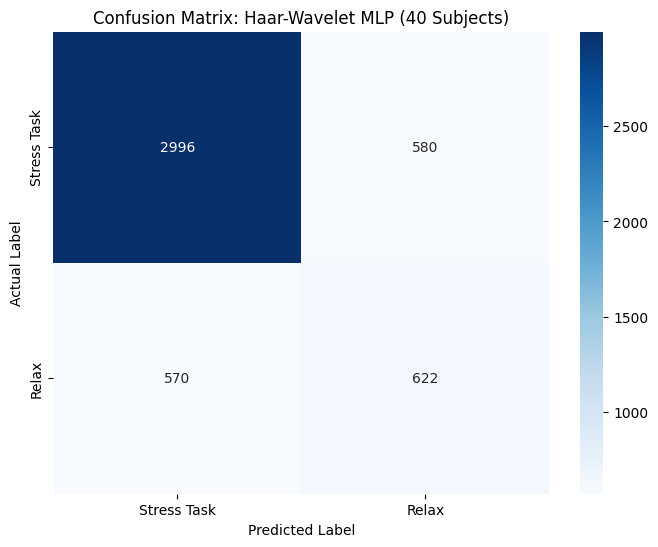

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test_h, y_pred_h)

# 2. Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stress Task', 'Relax'],
            yticklabels=['Stress Task', 'Relax'])
plt.title('Confusion Matrix: Haar-Wavelet MLP (40 Subjects)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Threshold and Penalty Calibration
Following the diagnostic analysis, we will now adjust the classification threshold and apply class weights to mitigate the bias toward stress prediction.

--- Calibrated Model Report (Weighted + Threshold Shift) ---
              precision    recall  f1-score   support

 Stress Task       0.86      0.63      0.73      3576
       Relax       0.38      0.69      0.49      1192

    accuracy                           0.65      4768
   macro avg       0.62      0.66      0.61      4768
weighted avg       0.74      0.65      0.67      4768



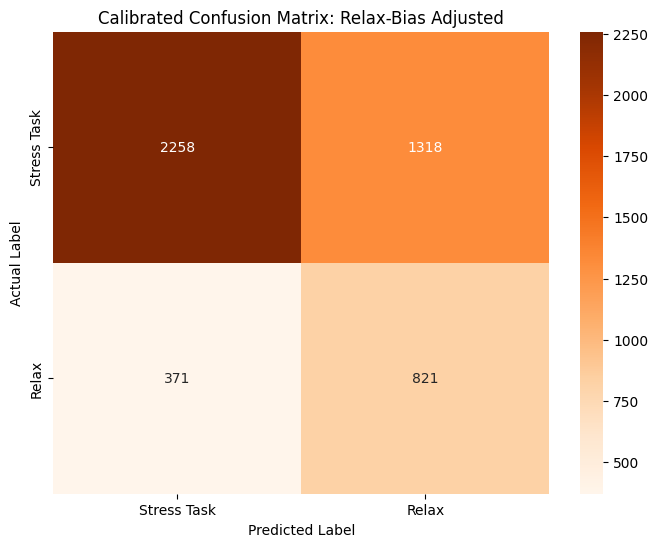

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Adjusting the MLP to handle class weights (using SMOTE-like balancing inside the classifier logic)
# We'll use a Logistic Regression with balanced weights for a clear comparison first
from sklearn.linear_model import LogisticRegression

weighted_model = LogisticRegression(class_weight={0: 1, 1: 2.5}, solver='lbfgs', max_iter=1000)
weighted_model.fit(X_train_h, y_train_h)

# 2. Extract Probabilities for Threshold Shifting
y_probs = weighted_model.predict_proba(X_test_h)[:, 1]

# Adjust threshold: Lower threshold increases Relax recall (Class 1)
custom_threshold = 0.4
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print("--- Calibrated Model Report (Weighted + Threshold Shift) ---")
print(classification_report(y_test_h, y_pred_custom, target_names=['Stress Task', 'Relax']))

# 3. Visual Diagnostic of the Adjusted Model
cm_adj = confusion_matrix(y_test_h, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_adj, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stress Task', 'Relax'],
            yticklabels=['Stress Task', 'Relax'])
plt.title('Calibrated Confusion Matrix: Relax-Bias Adjusted')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Comparative Evaluation: Model vs. Random Baselines
Since our dataset has a **3:1 imbalance** (75% Stress, 25% Relax), a model that simply guesses 'Stress' every time would achieve 75% accuracy but 0% Relax recall.

We will now compare our calibrated model against two baselines:
1.  **Uniform Random:** Flips a coin (50/50).
2.  **Stratified Random:** Guesses based on the training distribution (75% Stress / 25% Relax).

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score
import pandas as pd

# 1. Initialize Baselines
random_uniform = DummyClassifier(strategy='uniform', random_state=42)
random_stratified = DummyClassifier(strategy='stratified', random_state=42)

# 2. Fit and Predict
random_uniform.fit(X_train_h, y_train_h)
random_stratified.fit(X_train_h, y_train_h)

y_pred_uniform = random_uniform.predict(X_test_h)
y_pred_stratified = random_stratified.predict(X_test_h)

# 3. Compile Comparison Table
results = {
    'Metric': ['Accuracy', 'Relax Recall (Sensitivity)', 'Relax Precision'],
    'Calibrated Model': [
        accuracy_score(y_test_h, y_pred_custom),
        recall_score(y_test_h, y_pred_custom),
        precision_score(y_test_h, y_pred_custom)
    ],
    'Random (50/50)': [
        accuracy_score(y_test_h, y_pred_uniform),
        recall_score(y_test_h, y_pred_uniform),
        precision_score(y_test_h, y_pred_uniform)
    ],
    'Stratified (75/25)': [
        accuracy_score(y_test_h, y_pred_stratified),
        recall_score(y_test_h, y_pred_stratified),
        precision_score(y_test_h, y_pred_stratified)
    ]
}

comparison_df = pd.DataFrame(results).set_index('Metric')
display(comparison_df.style.highlight_max(axis=1, color='lightgreen'))

,Calibrated Model,Random (50/50),Stratified (75/25)
Metric,,,
Accuracy,0.645763,0.501678,0.630663
Relax Recall (Sensitivity),0.688758,0.504195,0.255872
Relax Precision,0.383824,0.251886,0.258694


### Advanced Modeling: Multi-Layer Perceptron (MLP) with Class Balancing

To move beyond the linear baseline, we implement a Multi-Layer Perceptron. We will use:
1. **Subject-wise Normalization**: To ensure features are comparable across individuals.
2. **SMOTE (Synthetic Minority Over-sampling Technique)**: To balance the 3:1 ratio in the training set.
3. **MLP Architecture**: A 3-layer dense network to capture non-linear stress signatures.

In [ ]:
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data (using Haar Wavelet features already in memory)
# X_haar_40_norm and y_haar_40 are the normalized features and labels

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_haar_40_norm, y_haar_40, test_size=0.2, random_state=42, stratify=y_haar_40
)

# 2. Apply SMOTE to the training set only to balance classes (3:1 -> 1:1)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_mlp, y_train_mlp)

# 3. Define and Train the MLP
# Architecture: (128, 64, 32) nodes to balance complexity and prevent overfitting
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42
)

print(f"Training MLP on {len(X_train_bal)} balanced segments...")
mlp_model.fit(X_train_bal, y_train_bal)

# 4. Evaluation
y_pred_mlp = mlp_model.predict(X_test_mlp)

print("\n--- MLP Classification Report (Minority Class Aware) ---")
print(classification_report(y_test_mlp, y_pred_mlp, target_names=['Stress', 'Relax']))

balanced_acc = balanced_accuracy_score(y_test_mlp, y_pred_mlp)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Training MLP on 28608 balanced segments...

--- MLP Classification Report (Minority Class Aware) ---
              precision    recall  f1-score   support

      Stress       0.84      0.84      0.84      3576
       Relax       0.52      0.52      0.52      1192

    accuracy                           0.76      4768
   macro avg       0.68      0.68      0.68      4768
weighted avg       0.76      0.76      0.76      4768

Balanced Accuracy: 0.6798


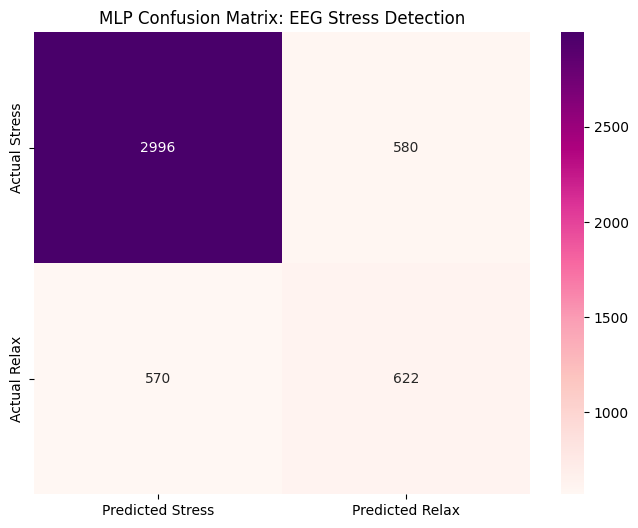

In [ ]:
# Visualize the results for the MLP model
from sklearn.metrics import confusion_matrix

cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Predicted Stress', 'Predicted Relax'],
            yticklabels=['Actual Stress', 'Actual Relax'])
plt.title('MLP Confusion Matrix: EEG Stress Detection')
plt.show()

### **Advanced Sequence Modeling: LSTM for Stress Detection**
We will now use a Recurrent Neural Network (LSTM) to model the raw time-series data. This approach allows the model to learn the temporal 'flow' of the EEG signal rather than just frequency-domain statistics.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# 1. Reshape data for sequence modeling
# LSTM expects (samples, time_steps, features)
# We'll use the existing 128 samples per window as time steps across 32 channels
X_lstm = X_full_raw.reshape(-1, 128, 32)
y_lstm = y_full_raw

# 2. Subject-wise Normalization in 3D
def normalize_subject_wise_3d(X, labels):
    X_norm = np.zeros_like(X)
    for sub in np.unique(labels):
        idx = np.where(labels == sub)[0]
        # Reshape to 2D for scaling, then back to 3D
        original_shape = X[idx].shape
        flattened = X[idx].reshape(-1, 32)
        scaled = StandardScaler().fit_transform(flattened)
        X_norm[idx] = scaled.reshape(original_shape)
    return X_norm

X_lstm_norm = normalize_subject_wise_3d(X_lstm, subject_labels_full)

# 3. Stratified Split
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_lstm_norm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

# 4. Build the LSTM Model
model_lstm = Sequential([
    LSTM(64, input_shape=(128, 32), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training LSTM on sequential EEG data...")
model_lstm.fit(X_train_ls, y_train_ls, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

# 5. Evaluation
y_pred_ls = (model_lstm.predict(X_test_ls) > 0.5).astype(int)
print("\n--- LSTM Classification Report ---")
print(classification_report(y_test_ls, y_pred_ls, target_names=['Stress', 'Relax']))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM on sequential EEG data...
Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 52s 163ms/step - accuracy: 0.7410 - loss: 0.5255 - val_accuracy: 0.7568 - val_loss: 0.5084
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 79s 153ms/step - accuracy: 0.7668 - loss: 0.4914 - val_accuracy: 0.7605 - val_loss: 0.5038
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.7760 - loss: 0.4794 - val_accuracy: 0.7689 - val_loss: 0.4861
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 39s 147ms/step - accuracy: 0.7852 - loss: 0.4671 - val_accuracy: 0.7783 - val_loss: 0.4793
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.7909 - loss: 0.4592 - val_accuracy: 0.7778 - val_loss: 0.4750
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.7966 - loss: 0.4486 - val_accuracy: 0.7809 - val_loss: 0.4779
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.7947 - loss: 0.4504 - val_accuracy: 0.7783 - val_loss: 0.4689
Epoch 8/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 40s

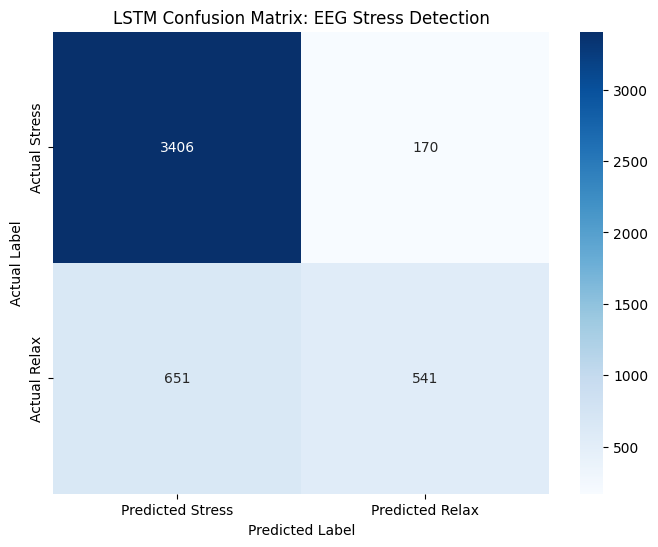

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix for the LSTM model
cm_ls = confusion_matrix(y_test_ls, y_pred_ls)

# 2. Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ls, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stress', 'Predicted Relax'],
            yticklabels=['Actual Stress', 'Actual Relax'])
plt.title('LSTM Confusion Matrix: EEG Stress Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Spiking Neural Network (SNN) for Stress Detection

In this section, we implement a Spiking Neural Network that utilizes the most predictive Haar Wavelet features: **L0 and L1 Energy**.

**Key Architectural Decisions:**
*   **Input Features:** Energy from L0 and L1 across all 32 channels (64 features total).
*   **Encoding:** Threshold-based spiking. We simulate the membrane potential over several time-steps. If the potential exceeds a threshold, a spike is generated.
*   **Learning:** Surrogate Gradient descent (Straight-Through Estimator) to allow standard backpropagation through the discrete spike generation process.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Feature Selection: Prioritize L0 and L1 Energy
priority_cols = [c for c in wav_feature_names if any(lvl in c for lvl in ['L0_Energy', 'L1_Energy'])]
print(f"Selected {len(priority_cols)} priority features (L0/L1 Energy across channels).")

X_snn_raw = wav_df[priority_cols].values
y_snn_raw = wav_df['Task'].apply(lambda x: 1 if x == 'Relax' else 0).values
sub_labels_snn = wav_df['Subject'].values

# 2. Subject-wise Normalization for SNN Stability
def normalize_subject_wise(X, subject_labels):
    X_norm = np.zeros_like(X)
    for sub in np.unique(subject_labels):
        idx = np.where(subject_labels == sub)[0]
        X_norm[idx] = StandardScaler().fit_transform(X[idx])
    return X_norm

X_snn_norm = normalize_subject_wise(X_snn_raw, sub_labels_snn)

# 3. Train/Test Split & Balancing
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_snn_norm, y_snn_raw, test_size=0.2, random_state=42, stratify=y_snn_raw
)

smote_snn = SMOTE(random_state=42)
X_train_bal_s, y_train_bal_s = smote_snn.fit_resample(X_train_s, y_train_s)

# 4. SNN Components with Surrogate Gradient
@tf.custom_gradient
def surrogate_spike(v):
    spike = tf.cast(tf.greater(v, 0.0), tf.float32)
    def grad(dy):
        return dy * tf.cast(tf.abs(v) < 0.5, tf.float32) # Straight-Through Estimator
    return spike, grad

class LeakyIntegrateAndFire(layers.Layer):
    def __init__(self, units, decay=0.8, threshold=1.0, time_steps=10):
        super(LeakyIntegrateAndFire, self).__init__()
        self.units = units
        self.decay = decay
        self.threshold = threshold
        self.time_steps = time_steps

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        mem = tf.zeros((batch_size, self.units))
        spikes_list = []

        for t in range(self.time_steps):
            mem = self.decay * mem + inputs
            spike = surrogate_spike(mem - self.threshold)
            mem = mem * (1.0 - spike) # Soft Reset
            spikes_list.append(spike)

        return tf.reduce_mean(tf.stack(spikes_list), axis=0) # Rate-coded output from spikes

# 5. Build SNN Model
snn_inputs = layers.Input(shape=(len(priority_cols),))
x = layers.Dense(128)(snn_inputs)
x = LeakyIntegrateAndFire(128)(x)
x = layers.Dense(64)(x)
x = LeakyIntegrateAndFire(64)(x)
snn_outputs = layers.Dense(1, activation='sigmoid')(x)

model_snn = Model(snn_inputs, snn_outputs)
model_snn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Training
print("\nTraining SNN on Prioritized Wavelet Features...")
history_snn = model_snn.fit(X_train_bal_s, y_train_bal_s, epochs=30, batch_size=64, validation_split=0.1, verbose=1)

# 7. Evaluation
y_pred_snn = (model_snn.predict(X_test_s) > 0.5).astype(int)
print("\n--- SNN (L0/L1 Energy) Classification Report ---")
print(classification_report(y_test_s, y_pred_snn, target_names=['Stress', 'Relax']))

Selected 64 priority features (L0/L1 Energy across channels).

Training SNN on Prioritized Wavelet Features...
Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.6230 - loss: 0.6548 - val_accuracy: 0.4041 - val_loss: 0.7498
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6395 - loss: 0.6342 - val_accuracy: 0.4041 - val_loss: 0.7466
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6541 - loss: 0.6204 - val_accuracy: 0.4883 - val_loss: 0.7224
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6667 - loss: 0.6070 - val_accuracy: 0.5774 - val_loss: 0.6203
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6763 - loss: 0.5969 - val_accuracy: 0.5215 - val_loss: 0.6816
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6888 - loss: 0.5838 - val_accuracy: 0.5722 - val_loss: 0.6619
Epoch 7/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6996 - loss: 0.5719 - val_accuracy: 0.5575 - val_los

### Statistical Correlation: Haar Wavelet Features vs. Verbal Stress Scores
We will now link the objective wavelet features (Energy, Std, MAV) extracted using the Haar wavelet with the subjective stress scores (0-10) provided in the verbal feedback.

Pearson Correlation (Global Haar Energy vs Stress Score): -0.4392
P-value: 6.2473e-09


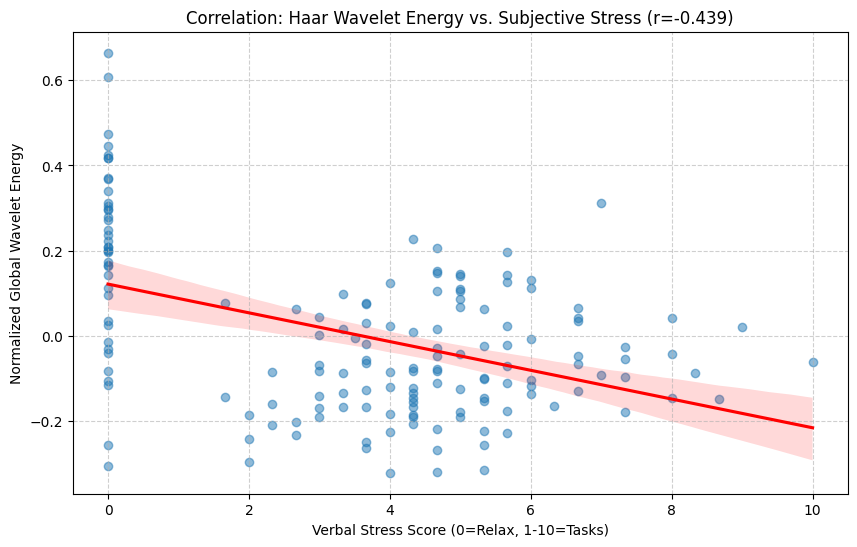

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Re-create extended_aggregated_feedback to fix the NameError
# Get unique subjects from the labels
all_subjects_in_data = np.unique(labels_haar_40)

# Create 'Relax' entries with score 0
relax_scores = pd.DataFrame({
    'Subject': all_subjects_in_data,
    'Task': 'Relax',
    'Stress_Score': 0
})

# Combine with original aggregated_feedback
extended_aggregated_feedback = pd.concat([aggregated_feedback, relax_scores], ignore_index=True)
extended_aggregated_feedback.drop_duplicates(subset=['Subject', 'Task'], inplace=True)

# 2. Prepare Wavelet DataFrame with metadata
wav_feature_names = []
for ch in range(32):
    for level in range(5):
        wav_feature_names.extend([f'Ch{ch}_L{level}_Energy', f'Ch{ch}_L{level}_Std', f'Ch{ch}_L{level}_MAV'])

wav_df = pd.DataFrame(X_haar_40_norm, columns=wav_feature_names)
wav_df['Subject'] = labels_haar_40

# Re-extract specific task names for all segments to enable 4-way merging
task_labels_full = []
for sub_id in range(1, 41):
    for task_name in ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']:
        try:
            file_path = get_subject_file_path(task_name, sub_id)
            df_len = len(pd.read_csv(file_path))
            num_segments = (df_len - 128) // 64 + 1
            task_labels_full.extend([task_name] * num_segments)
        except:
            continue

wav_df['Task'] = task_labels_full

# 3. Group by Subject and Task (160 groups: 40 subjects * 4 tasks)
session_wav_features = wav_df.groupby(['Subject', 'Task']).mean().reset_index()

# 4. Calculate Global Metric
energy_cols = [c for c in wav_feature_names if 'Energy' in c]
session_wav_features['Global_Wavelet_Energy'] = session_wav_features[energy_cols].mean(axis=1)

# 5. Merge with Subjective Stress Scores
correlation_df = pd.merge(session_wav_features, extended_aggregated_feedback, on=['Subject', 'Task'])

# 6. Calculate Pearson Correlation
r_val, p_val = pearsonr(correlation_df['Global_Wavelet_Energy'], correlation_df['Stress_Score'])

print(f"Pearson Correlation (Global Haar Energy vs Stress Score): {r_val:.4f}")
print(f"P-value: {p_val:.4e}")

# 7. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=correlation_df, x='Stress_Score', y='Global_Wavelet_Energy',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Correlation: Haar Wavelet Energy vs. Subjective Stress (r={r_val:.3f})')
plt.xlabel('Verbal Stress Score (0=Relax, 1-10=Tasks)')
plt.ylabel('Normalized Global Wavelet Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Training a Stress Score Predictor (Regression)

We will now use the **L0 and L1 Energy** features from the Haar Wavelet transform to predict the subjective stress scores (0-10) provided by the participants. This allows the model to differentiate between moderate and high stress levels.

Model Performance on Unseen Subjects/Tasks:
Mean Absolute Error: 1.41 units on a 0-10 scale
R-squared Score: 0.24


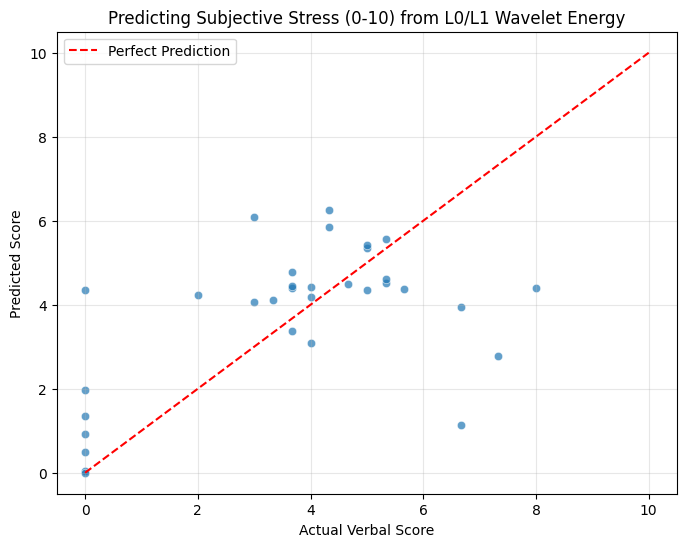

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare features (L0 and L1 Energy) and Target (Stress_Score)
priority_cols = [c for c in wav_feature_names if any(lvl in c for lvl in ['L0_Energy', 'L1_Energy'])]

# Group segment data to match the session-level stress scores
session_features = wav_df.groupby(['Subject', 'Task'])[priority_cols].mean().reset_index()

# Merge with the verbal scores
regression_data = pd.merge(session_features, extended_aggregated_feedback, on=['Subject', 'Task'])

X_reg = regression_data[priority_cols].values
y_reg = regression_data['Stress_Score'].values

# 2. Split into Train/Test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_reg, y_train_reg)

# 4. Evaluate
y_pred_reg = rf_regressor.predict(X_test_reg)

print(f"Model Performance on Unseen Subjects/Tasks:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_reg):.2f} units on a 0-10 scale")
print(f"R-squared Score: {r2_score(y_test_reg, y_pred_reg):.2f}")

# 5. Visualize Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.7)
plt.plot([0, 10], [0, 10], '--r', label='Perfect Prediction')
plt.title('Predicting Subjective Stress (0-10) from L0/L1 Wavelet Energy')
plt.xlabel('Actual Verbal Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Stress Score Prediction using Multi-Layer Perceptron (MLP) Regressor

We are replacing the Random Forest model with an MLP Regressor. Neural networks like MLP can sometimes capture different patterns in high-dimensional EEG feature spaces. We will use the same L0 and L1 Haar Wavelet Energy features (64 total) and apply standard scaling.

Training MLP Regressor...

MLP Performance (Predicting Stress 0-10):
Mean Absolute Error: 2.17 units
R-squared Score: -0.45


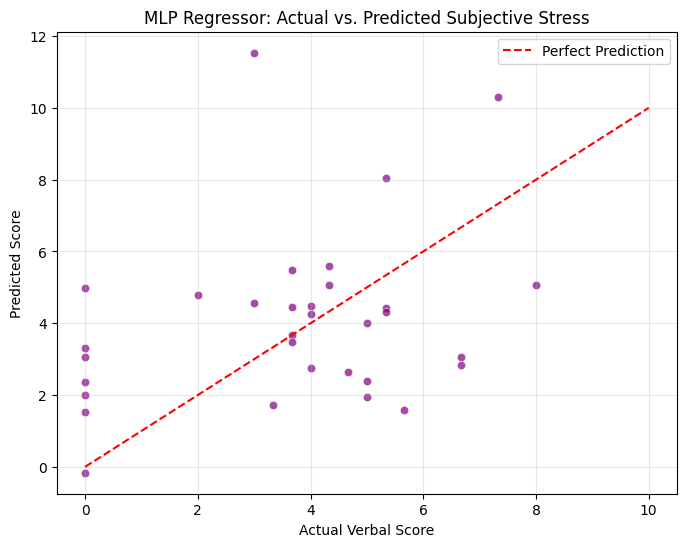

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare features (L0 and L1 Energy) and Target (Stress_Score)
priority_cols = [c for c in wav_feature_names if any(lvl in c for lvl in ['L0_Energy', 'L1_Energy'])]

# Group segment data to match the session-level stress scores
session_features = wav_df.groupby(['Subject', 'Task'])[priority_cols].mean().reset_index()

# Merge with the verbal scores
regression_data = pd.merge(session_features, extended_aggregated_feedback, on=['Subject', 'Task'])

X_reg = regression_data[priority_cols].values
y_reg = regression_data['Stress_Score'].values

# 2. Split into Train/Test sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Scale features (Required for MLP)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_scaled = scaler_reg.transform(X_test_reg)

# 4. Initialize and Train MLP Regressor
# Using a small architecture suitable for ~128 training samples
mlp_regressor = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                             activation='relu', solver='adam', random_state=42)

print("Training MLP Regressor...")
mlp_regressor.fit(X_train_scaled, y_train_reg)

# 5. Evaluate
y_pred_mlp = mlp_regressor.predict(X_test_scaled)

mae_mlp = mean_absolute_error(y_test_reg, y_pred_mlp)
r2_mlp = r2_score(y_test_reg, y_pred_mlp)

print(f"\nMLP Performance (Predicting Stress 0-10):")
print(f"Mean Absolute Error: {mae_mlp:.2f} units")
print(f"R-squared Score: {r2_mlp:.2f}")

# 6. Visualize Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_mlp, alpha=0.7, color='purple')
plt.plot([0, 10], [0, 10], '--r', label='Perfect Prediction')
plt.title('MLP Regressor: Actual vs. Predicted Subjective Stress')
plt.xlabel('Actual Verbal Score')
plt.ylabel('Predicted Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Within-Subject Normalization of Stress Scores
To account for individual differences in how participants report stress (subjectivity bias), we normalize the `Stress_Score` within each subject using Z-scoring. This ensures that the model learns relative changes in stress rather than absolute values that may be biased by personal perception.

Training MLP Regressor on Normalized Targets...

Normalized MLP Performance:
Mean Absolute Error (Z-score units): 0.61
R-squared Score: 0.23


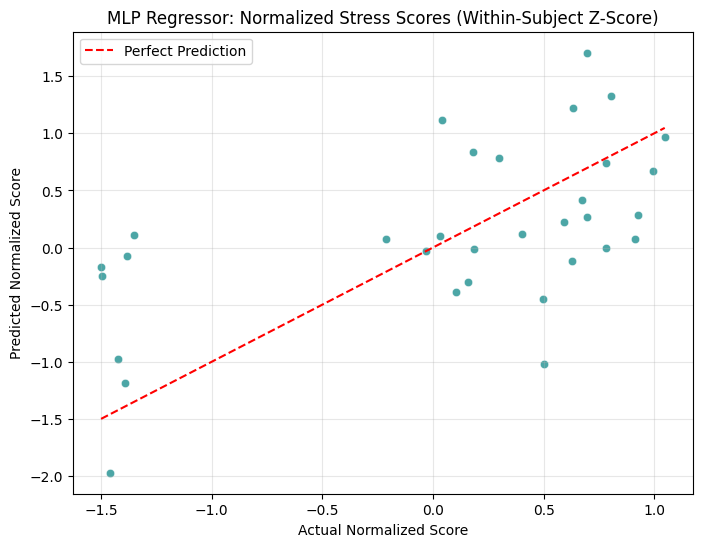

In [ ]:
def normalize_target_subject_wise(df, target_col, subject_col):
    df_norm = df.copy()
    for sub in df[subject_col].unique():
        mask = df[subject_col] == sub
        sub_values = df.loc[mask, target_col]
        if sub_values.std() != 0:
            df_norm.loc[mask, target_col] = (sub_values - sub_values.mean()) / sub_values.std()
        else:
            df_norm.loc[mask, target_col] = 0.0
    return df_norm

# Apply within-subject z-scoring to the regression data
regression_data_norm = normalize_target_subject_wise(regression_data, 'Stress_Score', 'Subject')

# Prepare features and normalized target
X_norm_reg = regression_data_norm[priority_cols].values
y_norm_reg = regression_data_norm['Stress_Score'].values

# Split into Train/Test sets
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_norm_reg, y_norm_reg, test_size=0.2, random_state=42
)

# Scale features
scaler_n = StandardScaler()
X_train_scaled_n = scaler_n.fit_transform(X_train_n)
X_test_scaled_n = scaler_n.transform(X_test_n)

# Retrain MLP Regressor
mlp_regressor_norm = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                                  activation='relu', solver='adam', random_state=42)

print("Training MLP Regressor on Normalized Targets...")
mlp_regressor_norm.fit(X_train_scaled_n, y_train_n)

# Evaluate
y_pred_norm = mlp_regressor_norm.predict(X_test_scaled_n)
mae_norm = mean_absolute_error(y_test_n, y_pred_norm)
r2_norm = r2_score(y_test_n, y_pred_norm)

print(f"\nNormalized MLP Performance:")
print(f"Mean Absolute Error (Z-score units): {mae_norm:.2f}")
print(f"R-squared Score: {r2_norm:.2f}")

# Visualize
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_n, y=y_pred_norm, alpha=0.7, color='teal')
plt.plot([min(y_test_n), max(y_test_n)], [min(y_test_n), max(y_test_n)], '--r', label='Perfect Prediction')
plt.title('MLP Regressor: Normalized Stress Scores (Within-Subject Z-Score)')
plt.xlabel('Actual Normalized Score')
plt.ylabel('Predicted Normalized Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, recall_score

# Calculate metrics for the normalized model
acc_norm = accuracy_score(y_test_n > 0, y_pred_norm > 0) # Using > 0 as a threshold for binary categorization
rec_norm = recall_score(y_test_n > 0, y_pred_norm > 0)

print(f'Normalized MLP Performance Summary:')
print(f'Accuracy (relative stress trend): {acc_norm:.2%}')
print(f'Recall (relative stress trend): {rec_norm:.2%}')

# Also display the standard regression metrics again for context
print(f'MAE (Z-score units): {mae_norm:.2f}')
print(f'R-squared Score: {r2_norm:.2f}')

Normalized MLP Performance Summary:
Accuracy (relative stress trend): 71.88%
Recall (relative stress trend): 69.57%
MAE (Z-score units): 0.61
R-squared Score: 0.23


### Granular Correlation Analysis: Decomposition Levels vs. Stress Scores
We will now iterate through each of the 5 decomposition levels (L0 to L4) and calculate the Pearson correlation between the average energy at that level (across all 32 channels) and the subjective stress scores.

Correlation breakdown by Wavelet Decomposition Level:


,Level,Correlation,P_Value
0,L0,-0.534505,3.343673e-13
1,L1,-0.496159,2.527957e-11
2,L2,-0.435351,8.756765e-09
3,L3,-0.317650,4.258196e-05
4,L4,-0.272848,4.817640e-04


/tmp/ipykernel_2513/3970214277.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=level_corr_summary, x='Level', y='Correlation', palette='coolwarm')


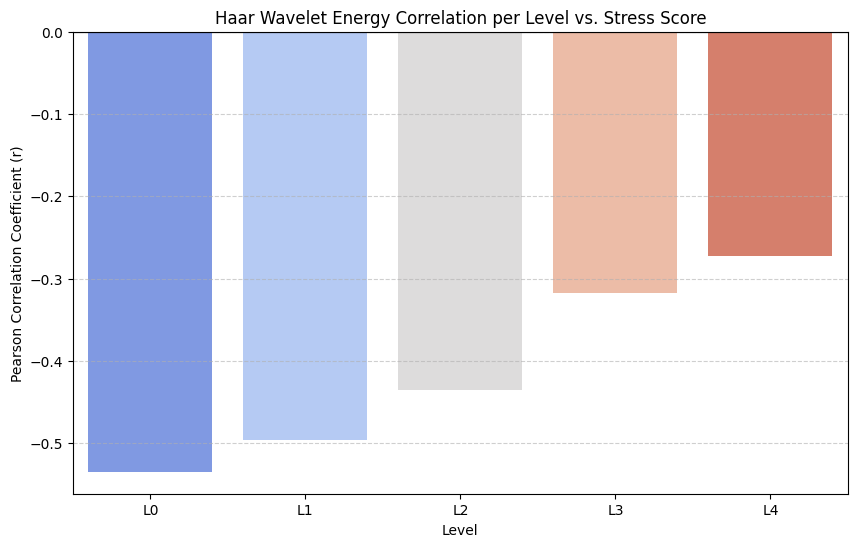

In [ ]:
level_correlations = []

for level in range(5):
    # Identify columns for Energy at the current level
    level_energy_cols = [c for c in wav_feature_names if f'_L{level}_Energy' in c]

    # Calculate mean energy for this level per session (Subject-Task)
    level_energy_series = wav_df.groupby(['Subject', 'Task'])[level_energy_cols].mean().mean(axis=1).reset_index()
    level_energy_series.columns = ['Subject', 'Task', f'L{level}_Energy']

    # Merge with stress scores
    level_corr_df = pd.merge(level_energy_series, extended_aggregated_feedback, on=['Subject', 'Task'])

    # Calculate correlation
    r_val_lvl, p_val_lvl = pearsonr(level_corr_df[f'L{level}_Energy'], level_corr_df['Stress_Score'])

    level_correlations.append({
        'Level': f'L{level}',
        'Correlation': r_val_lvl,
        'P_Value': p_val_lvl
    })

# Display Results
level_corr_summary = pd.DataFrame(level_correlations)
print("Correlation breakdown by Wavelet Decomposition Level:")
display(level_corr_summary)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=level_corr_summary, x='Level', y='Correlation', palette='coolwarm')
plt.title('Haar Wavelet Energy Correlation per Level vs. Stress Score')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Comparison of Energy vs MAV Correlations with Stress Scores:


,Level,Energy_Correlation,Energy_P_Value,MAV_Correlation,MAV_P_Value
0,L0,-0.534505,3.343673e-13,-0.485926,7.341284e-11
1,L1,-0.496159,2.527957e-11,-0.448116,2.816868e-09
2,L2,-0.435351,8.756765e-09,-0.428833,1.535081e-08
3,L3,-0.317650,4.258196e-05,-0.292513,1.744140e-04
4,L4,-0.272848,4.817640e-04,-0.241852,2.062421e-03


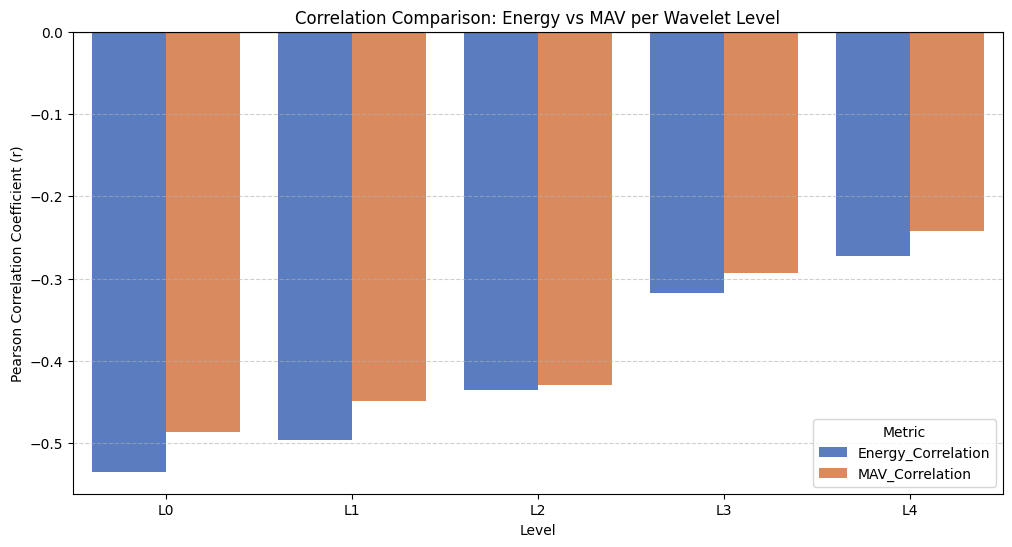

In [ ]:
mav_correlations = []

for level in range(5):
    # Identify columns for MAV at the current level
    level_mav_cols = [c for c in wav_feature_names if f'_L{level}_MAV' in c]

    # Calculate mean MAV for this level per session (Subject-Task)
    level_mav_series = wav_df.groupby(['Subject', 'Task'])[level_mav_cols].mean().mean(axis=1).reset_index()
    level_mav_series.columns = ['Subject', 'Task', f'L{level}_MAV']

    # Merge with stress scores
    level_mav_corr_df = pd.merge(level_mav_series, extended_aggregated_feedback, on=['Subject', 'Task'])

    # Calculate correlation
    r_val_mav, p_val_mav = pearsonr(level_mav_corr_df[f'L{level}_MAV'], level_mav_corr_df['Stress_Score'])

    mav_correlations.append({
        'Level': f'L{level}',
        'MAV_Correlation': r_val_mav,
        'MAV_P_Value': p_val_mav
    })

# Display Results and compare with Energy correlations
mav_corr_summary = pd.DataFrame(mav_correlations)
comparison_summary = level_corr_summary.rename(columns={'Correlation': 'Energy_Correlation', 'P_Value': 'Energy_P_Value'})
comparison_summary = comparison_summary.merge(mav_corr_summary, on='Level')

print("Comparison of Energy vs MAV Correlations with Stress Scores:")
display(comparison_summary)

# Visualization
plt.figure(figsize=(12, 6))
melted_corr = comparison_summary.melt(id_vars='Level', value_vars=['Energy_Correlation', 'MAV_Correlation'], var_name='Metric', value_name='Correlation')
sns.barplot(data=melted_corr, x='Level', y='Correlation', hue='Metric', palette='muted')
plt.title('Correlation Comparison: Energy vs MAV per Wavelet Level')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Visualizing Delta/Alpha Ratio for Most Statistically Variable Channels

In [ ]:
# Re-create stats_norm_df for identifying top channels (if not already available or to ensure it's up-to-date)
# Assumes full_df (uncleaned) is available from cell `e8e6f9fe`

X_pivot_full = full_df.pivot_table(index=['Subject', 'Task', 'Is_Relaxed'], columns='Channel', values='Delta_Alpha_Ratio').reset_index()

channel_cols = [str(i) for i in range(32)]
X_raw_vals = X_pivot_full[channel_cols].values
subject_labels_for_norm = X_pivot_full['Subject'].values

X_norm_vals = normalize_subject_wise(X_raw_vals, subject_labels_for_norm)

X_pivot_norm = pd.DataFrame(X_norm_vals, columns=channel_cols)
X_pivot_norm['Task'] = X_pivot_full['Task'].values
X_pivot_norm['Subject'] = X_pivot_full['Subject'].values

channel_stats_norm = []
for ch in range(32):
    ch_str = str(ch)
    groups = [X_pivot_norm[X_pivot_norm['Task'] == t][ch_str].dropna() for t in tasks]
    # Ensure groups are not empty for f_oneway
    if all(len(g) > 0 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        channel_stats_norm.append({'Channel': ch, 'F_Statistic': f_stat, 'P_Value': p_val})

stats_norm_df = pd.DataFrame(channel_stats_norm).sort_values(by='F_Statistic', ascending=False)

# Get the top 5 most statistically variable channels
top_n_channels = 5 # As an example, can be adjusted
most_variable_channels = stats_norm_df.head(top_n_channels)['Channel'].astype(str).tolist()

print(f"\nMost statistically variable channels (Top {top_n_channels} by F-Statistic): {most_variable_channels}")

# Filter the cleaned data for these top channels
filtered_df = full_df_cleaned[full_df_cleaned['Channel'].isin(most_variable_channels)].copy()

# Calculate the mean Delta/Alpha Ratio across these selected channels for each Subject and Task
# Then, apply subject-wise normalization to this aggregated data

# Aggregate mean Delta/Alpha Ratio for the selected channels per subject and task
mean_ratio_per_session = filtered_df.groupby(['Subject', 'Task'])['Delta_Alpha_Ratio'].mean().reset_index()

# Prepare data for subject-wise normalization
X_mean_ratio = mean_ratio_per_session['Delta_Alpha_Ratio'].values.reshape(-1, 1)
y_mean_ratio_subjects = mean_ratio_per_session['Subject'].values

X_mean_ratio_norm = normalize_subject_wise(X_mean_ratio, y_mean_ratio_subjects)

# Add normalized ratio back to the DataFrame
mean_ratio_per_session['Normalized_Delta_Alpha_Ratio'] = X_mean_ratio_norm


plt.figure(figsize=(16, 8))
sns.lineplot(data=mean_ratio_per_session, x='Subject', y='Normalized_Delta_Alpha_Ratio', hue='Task', marker='o')

plt.title(f'Normalized Delta/Alpha Ratio ({', '.join(most_variable_channels)} Channels) Across 40 Subjects', fontsize=16)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Mean Normalized Delta/Alpha Ratio', fontsize=12)
plt.xticks(range(1, 41)) # Ensure all 40 subjects are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'full_df' is not defined

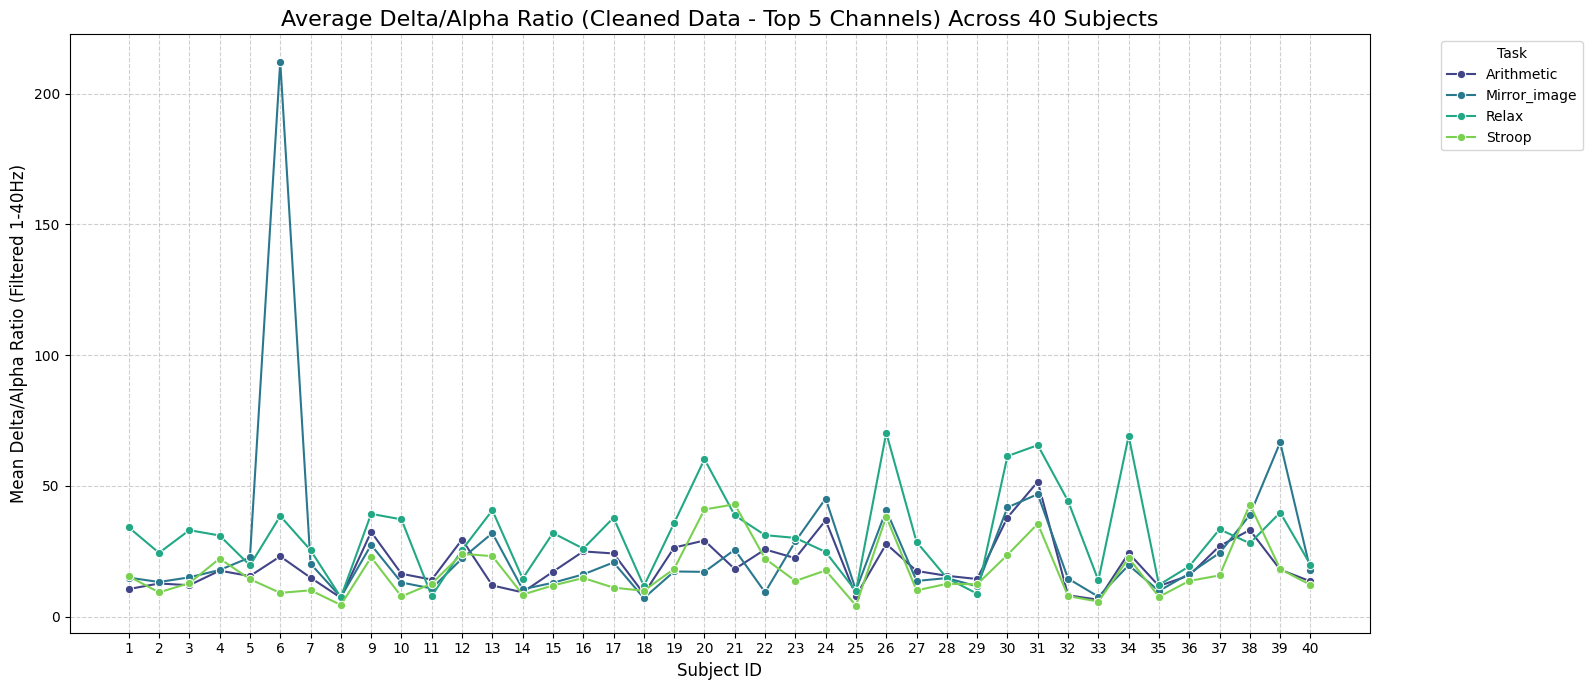

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the top 5 channels based on the previous ANOVA results
# These channels showed the most significant variability across tasks
top_5_channels = ['30', '25', '26', '29', '24']

# 2. Filter the ARTIFACT-CLEANED dataset (full_df_cleaned) for these channels
# This version of the data has been band-pass filtered (1-40Hz)
plot_data_cleaned = full_df_cleaned[full_df_cleaned['Channel'].isin(top_5_channels)].copy()

# 3. Aggregate: Average the Delta_Alpha_Ratio across the top 5 channels for each (Subject, Task) session
subject_task_trends_cleaned = plot_data_cleaned.groupby(['Subject', 'Task'])['Delta_Alpha_Ratio'].mean().reset_index()

# 4. Visualization
plt.figure(figsize=(16, 7))
sns.lineplot(
    data=subject_task_trends_cleaned,
    x='Subject',
    y='Delta_Alpha_Ratio',
    hue='Task',
    marker='o',
    palette='viridis'
)

plt.title('Average Delta/Alpha Ratio (Cleaned Data - Top 5 Channels) Across 40 Subjects', fontsize=16)
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Mean Delta/Alpha Ratio (Filtered 1-40Hz)', fontsize=12)
plt.xticks(range(1, 41))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Prepare data for the remaining 30 subjects (11-40)
test_subjects_mask = subject_labels_full > 10
X_unseen = X_full_norm[test_subjects_mask]
y_unseen = y_full_raw[test_subjects_mask]

# 2. Reshape for LSTM (batch, time_steps, channels)
X_unseen_3d = X_unseen.reshape(-1, 128, 32)

print(f"Evaluating model on {len(X_unseen_3d)} segments from subjects 11-40...")

# 3. Use the balanced model to predict
y_unseen_probs = bal_lstm_model.predict(X_unseen_3d)
y_unseen_pred = (y_unseen_probs > 0.5).astype("int32")

# 4. Final Evaluation
print("\n--- Generalization Report (Subjects 11-40) ---")
print(classification_report(y_unseen, y_unseen_pred, target_names=['Stress Task', 'Relax']))

### Interpretation of the Random Forest Regression Model

*   **R-squared:** Indicates the proportion of variance in the dependent variable (Stress Score) explained by the model. A higher R-squared value means a better fit.
*   **MSE, RMSE, MAE:** These metrics quantify the average magnitude of the errors. Lower values indicate better accuracy.

Compare these metrics to the Linear Regression model to determine if the Random Forest Regressor provides a better fit for predicting stress scores from the Delta/Alpha Ratio. A significantly higher R-squared and lower error metrics would suggest that a non-linear model is more appropriate for this dataset.

### Interpretation of the Regression Model

*   **R-squared:** Indicates the proportion of variance in the dependent variable (Stress Score) that can be predicted from the independent variable (Delta/Alpha Ratio). A higher R-squared value means a better fit.
*   **MSE, RMSE, MAE:** These metrics quantify the average magnitude of the errors. Lower values indicate better accuracy.
*   **Coefficients:** For a simple linear regression, the coefficient indicates how much the dependent variable (Stress Score) is expected to change for each unit increase in the independent variable (Delta/Alpha Ratio), holding other variables constant. A positive coefficient means that as Delta/Alpha Ratio increases, Stress Score tends to increase.

The visualization helps to see how well the predicted values align with the actual values. Points close to the red 'Perfect Prediction' line indicate accurate predictions.

### Verbal Feedback Data Integration

This section integrates the verbal feedback scores provided by the user with the processed EEG data. The feedback scores, representing perceived stress levels for each subject during different tasks, will be used to enhance our stress detection model.

### Correlation Analysis: Verbal Feedback vs. EEG Metrics

Now, we integrate the verbal feedback data (`aggregated_feedback`) with the EEG band power data (`full_df`) to investigate the correlation between the subjective stress scores and objective EEG measures. This will help validate if the physiological indicators align with self-reported stress.

In [ ]:
# Merge the verbal feedback with the EEG band power data
# We'll merge `aggregated_feedback` (subjective scores) with `full_df` (EEG data)
# The `full_df` already contains 'Delta_Alpha_Ratio' for channels 24-31

merged_data = pd.merge(full_df, aggregated_feedback, on=['Subject', 'Task'], how='left')

print("Merged DataFrame with EEG metrics and Stress Scores:")
display(merged_data.head())
display(merged_data.info())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation between Delta/Alpha Ratio and Stress_Score
# Group by Subject and Task to get a single Delta_Alpha_Ratio per session, averaged across channels
correlation_data = merged_data.groupby(['Subject', 'Task', 'Stress_Score'])['Delta_Alpha_Ratio'].mean().reset_index()

# Calculate Pearson correlation coefficient
correlation_coefficient = correlation_data['Delta_Alpha_Ratio'].corr(correlation_data['Stress_Score'])

print(f"Pearson correlation between Delta/Alpha Ratio and Stress Score: {correlation_coefficient:.3f}")

# Visualize the correlation
plt.figure(figsize=(10, 6))
sns.regplot(x='Stress_Score', y='Delta_Alpha_Ratio', data=correlation_data, scatter_kws={'alpha':0.6})
plt.title(f'Correlation between Delta/Alpha Ratio and Verbal Stress Score (r={correlation_coefficient:.3f})')
plt.xlabel('Verbal Stress Score (1-10)')
plt.ylabel('Average Delta/Alpha Ratio (Channels 24-31)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from scipy.stats import pearsonr

# Perform Pearson correlation and get the p-value
# We use the correlation_data from the previous step
stat_correlation_coefficient, p_value = pearsonr(correlation_data['Delta_Alpha_Ratio'], correlation_data['Stress_Score'])

print(f"Pearson correlation coefficient: {stat_correlation_coefficient:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("The correlation is statistically significant (p < 0.05).")
else:
    print("The correlation is not statistically significant (p >= 0.05).")

This statistical test helps confirm whether the linear relationship observed in the scatter plot is likely to be a genuine relationship or if it could have occurred by chance. A p-value less than 0.05 is typically considered statistically significant.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique tasks from merged_data
unique_tasks = merged_data['Task'].unique()

plt.figure(figsize=(15, 10))

for i, task in enumerate(unique_tasks):
    plt.subplot(2, 2, i + 1) # Create a subplot for each task
    task_data = merged_data[merged_data['Task'] == task]

    # Group by Subject and Stress_Score to get a single Delta_Alpha_Ratio per session
    correlation_data_task = task_data.groupby(['Subject', 'Stress_Score'])['Delta_Alpha_Ratio'].mean().reset_index()

    # Calculate Pearson correlation coefficient for the current task
    correlation_coefficient = correlation_data_task['Delta_Alpha_Ratio'].corr(correlation_data_task['Stress_Score'])

    sns.regplot(x='Stress_Score', y='Delta_Alpha_Ratio', data=correlation_data_task, scatter_kws={'alpha':0.6})
    plt.title(f'{task} (r={correlation_coefficient:.3f})')
    plt.xlabel('Verbal Stress Score (1-10)')
    plt.ylabel('Average Delta/Alpha Ratio')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Correlation between Delta/Alpha Ratio and Verbal Stress Score by Task', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Interpretation of Correlation Results

This plot and the Pearson correlation coefficient indicate the linear relationship between the subjective verbal stress scores and the objective Delta/Alpha ratio from EEG.

*   A positive correlation suggests that as verbal stress scores increase, the Delta/Alpha ratio also tends to increase.
*   A negative correlation suggests an inverse relationship.
*   A correlation close to zero indicates little to no linear relationship.

This analysis helps in understanding how well the identified EEG biomarker (Delta/Alpha ratio) reflects the participants' self-reported stress perception.

In [ ]:
import pandas as pd
import io

verbal_feedback_data = """
Subject No.,Trial_1_Stroop Color-word Test,Trial_1_Arithmetic Task,Trial_1_Mirror Image Recognition Task,Trial_2_Stroop Color-word Test,Trial_2_Arithmetic Task,Trial_2_Mirror Image Recognition Task,Trial_3_Stroop Color-word Test,Trial_3_Arithmetic Task,Trial_3_Mirror Image Recognition Task
1,3,6,3,2,7,5,4,4,7
2,5,3,4,4,3,4,3,7,5
3,4,5,3,5,3,5,5,8,7
4,4,5,3,2,3,5,5,7,5
5,6,6,6,2,5,3,3,5,7
6,2,5,4,3,4,3,5,8,6
7,4,5,5,3,3,3,6,6,3
8,4,3,5,3,6,6,3,5,6
9,4,3,6,4,4,4,6,7,4
10,4,3,4,3,4,5,5,6,4
11,4,7,3,5,6,5,5,5,6
12,2,5,7,5,5,4,3,8,6
13,3,3,5,2,3,4,1,3,5
14,3,3,4,2,6,4,4,6,3
15,5,9,6,3,7,5,5,6,5
16,1,4,4,1,5,6,6,8,5
17,8,8,9,4,6,8,6,7,7
18,6,6,5,5,5,6,7,9,6
19,6,4,6,3,2,4,3,4,1
20,7,10,9,5,10,9,6,10,8
21,9,7,8,9,8,8,9,7,8
22,5,9,8,6,8,8,5,7,6
23,1,3,2,1,4,2,5,8,4
24,1,4,2,1,2,1,4,5,7
25,2,2,1,2,2,1,5,5,7
26,8,6,7,7,6,8,6,4,5
27,3,5,5,2,3,4,3,5,3
28,7,7,8,5,7,7,4,6,5
29,6,6,7,6,8,7,5,6,6
30,5,7,6,5,8,6,4,7,5
31,4,10,8,3,9,7,7,6,3
32,1,5,5,1,1,2,3,7,6
33,3,5,4,2,3,2,6,8,3
34,1,2,3,1,3,1,3,2,2
35,1,6,5,1,5,2,5,4,6
36,6,4,4,3,5,4,5,5,5
37,4,6,5,2,5,3,6,8,4
38,5,6,4,3,5,6,3,4,5
39,3,6,4,3,5,5,5,6,3
40,5,3,5,5,4,6,3,4,5
"""

# Read the data into a DataFrame
feedback_df = pd.read_csv(io.StringIO(verbal_feedback_data))

# Reshape the DataFrame to have one row per Subject-Task-Trial
# First, melt the DataFrame to long format for trials and tasks
feedback_long = feedback_df.melt(id_vars=['Subject No.'], var_name='Trial_Task_Column', value_name='Stress_Score')

# Split the 'Trial_Task_Column' into three parts: 'Trial', the trial number, and the task description
split_parts = feedback_long['Trial_Task_Column'].str.split('_', n=2, expand=True)

# The trial number is the second part (index 1)
feedback_long['Trial'] = split_parts[1].astype(int)

# The task description is the third part (index 2)
feedback_long['Task_Description'] = split_parts[2]

# Further split 'Task_Description' to get clean Task names
def extract_task_name(description):
    if 'Stroop Color-word Test' in description:
        return 'Stroop'
    elif 'Arithmetic Task' in description:
        return 'Arithmetic'
    elif 'Mirror Image Recognition Task' in description:
        return 'Mirror_image'
    return None # Should not happen with current data

feedback_long['Task'] = feedback_long['Task_Description'].apply(extract_task_name)

# Drop intermediate columns and reorder
feedback_long = feedback_long[['Subject No.', 'Task', 'Trial', 'Stress_Score']]

# Aggregate scores for each Subject and Task (e.g., take the mean across trials)
# This assumes the stress score is consistent enough across trials for a given subject and task
# Alternatively, we could keep trials separate if we want to model trial-specific effects
aggregated_feedback = feedback_long.groupby(['Subject No.', 'Task'])['Stress_Score'].mean().reset_index()

# Rename 'Subject No.' to 'Subject' to match EEG data DataFrame
aggregated_feedback = aggregated_feedback.rename(columns={'Subject No.': 'Subject'})

print("Aggregated Verbal Feedback Data (Mean Stress Score per Subject and Task):")
display(aggregated_feedback.head())
display(aggregated_feedback.tail())

In [ ]:
import pandas as pd
import io

verbal_feedback_data = """
Subject No.,Trial_1_Stroop Color-word Test,Trial_1_Arithmetic Task,Trial_1_Mirror Image Recognition Task,Trial_2_Stroop Color-word Test,Trial_2_Arithmetic Task,Trial_2_Mirror Image Recognition Task,Trial_3_Stroop Color-word Test,Trial_3_Arithmetic Task,Trial_3_Mirror Image Recognition Task
1,3,6,3,2,7,5,4,4,7
2,5,3,4,3,4,3,7,5
3,4,5,3,5,3,5,5,8,7
4,4,5,3,2,3,5,5,7,5
5,6,6,6,2,5,3,3,5,7
6,2,5,4,3,4,3,5,8,6
7,4,5,5,3,3,3,6,6,3
8,4,3,5,3,6,6,3,5,6
9,4,3,6,4,4,4,6,7,4
10,4,3,4,3,4,5,5,6,4
11,4,7,3,5,6,5,5,5,6
12,2,5,7,5,5,4,3,8,6
13,3,3,5,2,3,4,1,3,5
14,3,3,4,2,6,4,4,6,3
15,5,9,6,3,7,5,5,6,5
16,1,4,4,1,5,6,6,8,5
17,8,8,9,4,6,8,6,7,7
18,6,6,5,5,5,6,7,9,6
19,6,4,6,3,2,4,3,4,1
20,7,10,9,5,10,9,6,10,8
21,9,7,8,9,8,8,9,7,8
22,5,9,8,6,8,8,5,7,6
23,1,3,2,1,4,2,5,8,4
24,1,4,2,1,2,1,4,5,7
25,2,2,1,2,2,1,5,5,7
26,8,6,7,7,6,8,6,4,5
27,3,5,5,2,3,4,3,5,3
28,7,7,8,5,7,7,4,6,5
29,6,6,7,6,8,7,5,6,6
30,5,7,6,5,8,6,4,7,5
31,4,10,8,3,9,7,7,6,3
32,1,5,5,1,1,2,3,7,6
33,3,5,4,2,3,2,6,8,3
34,1,2,3,1,3,1,3,2,2
35,1,6,5,1,5,2,5,4,6
36,6,4,4,3,5,4,5,5,5
37,4,6,5,2,5,3,6,8,4
38,5,6,4,3,5,6,3,4,5
39,3,6,4,3,5,5,5,6,3
40,5,3,5,5,4,6,3,4,5
"""

# Read the data into a DataFrame
feedback_df = pd.read_csv(io.StringIO(verbal_feedback_data))

# Reshape the DataFrame to have one row per Subject-Task-Trial
# First, melt the DataFrame to long format for trials and tasks
feedback_long = feedback_df.melt(id_vars=['Subject No.'], var_name='Trial_Task_Column', value_name='Stress_Score')

# Split the 'Trial_Task_Column' into three parts: 'Trial', the trial number, and the task description
split_parts = feedback_long['Trial_Task_Column'].str.split('_', n=2, expand=True)

# The trial number is the second part (index 1)
feedback_long['Trial'] = split_parts[1].astype(int)

# The task description is the third part (index 2)
feedback_long['Task_Description'] = split_parts[2]

# Further split 'Task_Description' to get clean Task names
def extract_task_name(description):
    if 'Stroop Color-word Test' in description:
        return 'Stroop'
    elif 'Arithmetic Task' in description:
        return 'Arithmetic'
    elif 'Mirror Image Recognition Task' in description:
        return 'Mirror_image'
    return None # Should not happen with current data

feedback_long['Task'] = feedback_long['Task_Description'].apply(extract_task_name)

# Drop intermediate columns and reorder
feedback_long = feedback_long[['Subject No.', 'Task', 'Trial', 'Stress_Score']]

# Aggregate scores for each Subject and Task (e.g., take the mean across trials)
# This assumes the stress score is consistent enough across trials for a given subject and task
# Alternatively, we could keep trials separate if we want to model trial-specific effects
aggregated_feedback = feedback_long.groupby(['Subject No.', 'Task'])['Stress_Score'].mean().reset_index()

# Rename 'Subject No.' to 'Subject' to match EEG data DataFrame
aggregated_feedback = aggregated_feedback.rename(columns={'Subject No.': 'Subject'})

print("Aggregated Verbal Feedback Data (Mean Stress Score per Subject and Task):")
display(aggregated_feedback.head())
display(aggregated_feedback.tail())

Aggregated Verbal Feedback Data (Mean Stress Score per Subject and Task):


,Subject,Task,Stress_Score
0,1,Arithmetic,5.666667
1,1,Mirror_image,5.000000
2,1,Stroop,3.000000
3,2,Arithmetic,4.000000
4,2,Mirror_image,3.500000


,Subject,Task,Stress_Score
115,39,Mirror_image,4.000000
116,39,Stroop,3.666667
117,40,Arithmetic,3.666667
118,40,Mirror_image,5.333333
119,40,Stroop,4.333333


In [ ]:
# Install MNE library if not already installed
!pip install mne --quiet

import pandas as pd
import numpy as np
import mne # Import MNE library
import os # For file path operations
import kagglehub

# Re-define path and functions that might not be in scope
path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")

def get_subject_file_path(task_folder, subject_id):
    base_path = path
    task_data_folder = None
    for item in os.listdir(base_path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None:
        raise FileNotFoundError(f"Task folder for {task_folder} not found in {base_path}")

    subject_filename = f'{task_folder}_sub_{subject_id}.csv'
    full_path = os.path.join(base_path, task_data_folder, task_folder, subject_filename)
    return full_path

# The dataset specifies a sampling rate of 128 SPS (Samples Per Second).
sampling_rate = 128 # Hz
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

def df_to_raw(df, info, title="EEG Data"):
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    return raw

def extract_band_power(raw_obj, bands):
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)
    freqs = spectrums.freqs
    psds = spectrums.data

    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_psds = psds[:, idx_band]
        band_powers[band_name] = band_psds.mean(axis=1)
    return pd.DataFrame(band_powers, index=raw_obj.ch_names)


# Define the list of all 40 subjects
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

# Re-define `bands` to ensure it's available
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}

full_dataset_powers = []

print("Re-processing all 40 subjects to construct full_df...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)

            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0 # Used for binary classification later

            full_dataset_powers.append(powers)
        except Exception as e:
            print(f"Skipping {task_name} for Subject {subject_id} due to error: {e}")
            continue

full_df = pd.concat(full_dataset_powers, ignore_index=True)
print(f"Finished constructing full_df. Total instances: {len(full_df)} (channels x subjects x tasks)")
display(full_df.head())

Using Colab cache for faster access to the 'raw-eeg-stress-dataset-sam40' dataset.
Re-processing all 40 subjects to construct full_df...
Finished constructing full_df. Total instances: 5120 (channels x subjects x tasks)


,Delta,Theta,Alpha,Beta,Delta_Alpha_Ratio,Task,Subject,Channel,Is_Relaxed
0,2.549931e-11,7.246292e-12,2.898997e-12,1.192411e-12,8.795906,Arithmetic,1,0,0
1,1.569288e-10,2.104471e-11,4.603157e-12,1.063326e-12,34.091564,Arithmetic,1,1,0
2,2.214318e-10,2.575207e-11,4.684770e-12,9.421421e-13,47.266316,Arithmetic,1,2,0
3,1.273739e-10,1.804709e-11,3.571644e-12,7.615674e-13,35.662548,Arithmetic,1,3,0
4,2.560717e-11,6.515294e-12,2.175881e-12,6.753606e-13,11.768646,Arithmetic,1,4,0


In [ ]:
# Re-running the data loading and band power extraction with the correct 128Hz sampling rate
subjects_to_analyze = [1, 2, 3]
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']
all_subjects_band_powers = []

for subject_id in subjects_to_analyze:
    subject_band_powers = []
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            subject_band_powers.append(powers)
        except Exception as e:
            print(f"Error processing {task_name} Subject {subject_id}: {e}")

    if subject_band_powers:
        all_subjects_band_powers.append(pd.concat(subject_band_powers, ignore_index=True))

combined_multi_subject_band_powers = pd.concat(all_subjects_band_powers, ignore_index=True)
print("Re-calculated band powers for 128 Hz sampling rate.")
display(combined_multi_subject_band_powers.head())

Re-calculated band powers for 128 Hz sampling rate.


,Delta,Theta,Alpha,Beta,Task,Subject,Channel
0,2.549931e-11,7.246292e-12,2.898997e-12,1.192411e-12,Arithmetic,1,0
1,1.569288e-10,2.104471e-11,4.603157e-12,1.063326e-12,Arithmetic,1,1
2,2.214318e-10,2.575207e-11,4.684770e-12,9.421421e-13,Arithmetic,1,2
3,1.273739e-10,1.804709e-11,3.571644e-12,7.615674e-13,Arithmetic,1,3
4,2.560717e-11,6.515294e-12,2.175881e-12,6.753606e-13,Arithmetic,1,4


### Reconstructing `full_df` for Correlation Analysis

The `full_df` DataFrame, which contains the processed EEG band power data including the Delta/Alpha ratio for all subjects and channels, was not found in the current execution context. This cell reconstructs `full_df` to ensure all necessary data is available for the subsequent correlation analysis with verbal feedback scores.

In [ ]:
# Install MNE library if not already installed
!pip install mne --quiet

import pandas as pd
import numpy as np
import mne # Import MNE library
import os # For file path operations
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Re-define path and functions that might not be in scope
import kagglehub
path = kagglehub.dataset_download("ayushtibrewal/raw-eeg-stress-dataset-sam40")

def get_subject_file_path(task_folder, subject_id):
    base_path = path
    task_data_folder = None
    for item in os.listdir(base_path):
        if item.startswith(task_folder) and item.endswith('-001'):
            task_data_folder = item
            break
    if task_data_folder is None:
        raise FileNotFoundError(f"Task folder for {task_folder} not found in {base_path}")

    subject_filename = f'{task_folder}_sub_{subject_id}.csv'
    full_path = os.path.join(base_path, task_data_folder, task_folder, subject_filename)
    return full_path

# The dataset specifies a sampling rate of 128 SPS (Samples Per Second).
sampling_rate = 128 # Hz
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

def df_to_raw(df, info, title="EEG Data"):
    eeg_data = df.drop(columns=['Unnamed: 0'], errors='ignore').values.T * 1e-6
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    return raw

def extract_band_power(raw_obj, bands):
    spectrums = raw_obj.compute_psd(method='welch', fmin=0.5, fmax=40, picks='eeg', verbose=False)
    freqs = spectrums.freqs
    psds = spectrums.data

    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_psds = psds[:, idx_band]
        band_powers[band_name] = band_psds.mean(axis=1)
    return pd.DataFrame(band_powers, index=raw_obj.ch_names)


# Define the list of all 40 subjects
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

# Re-define `bands` to ensure it's available
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}

full_dataset_powers = []

print("Re-processing all 40 subjects to construct full_df...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)

            # --- FIX: Removed filtering to include all 32 channels ---
            # The previous code filtered for channels 24-31, which corresponds
            # only to the Occipital region. This caused the KeyError.
            # target_chans = [str(i) for i in range(24, 32)]
            # powers = powers.loc[target_chans].copy()
            # ---------------------------------------------------------

            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0 # Used for binary classification later

            full_dataset_powers.append(powers)
        except Exception as e:
            print(f"Skipping {task_name} for Subject {subject_id} due to error: {e}")
            continue

full_df = pd.concat(full_dataset_powers, ignore_index=True)
print(f"Finished constructing full_df. Total instances: {len(full_df)} (channels x subjects x tasks)")
display(full_df.head())

### Reconstructing `full_df` for Correlation Analysis

The `full_df` DataFrame, which contains the processed EEG band power data including the Delta/Alpha ratio for all subjects and channels, was not found in the current execution context. This cell reconstructs `full_df` to ensure all necessary data is available for the subsequent correlation analysis with verbal feedback scores.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the list of all 40 subjects
all_subjects = list(range(1, 41))
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

# Ensure `bands`, `info`, `get_subject_file_path`, `df_to_raw`, `extract_band_power` are defined.
# These functions are assumed to be defined in previous cells and their definitions are crucial here.
# Re-define `bands` to ensure it's available
bands = {
    'Delta': [0.5, 4],
    'Theta': [4, 8],
    'Alpha': [8, 12],
    'Beta': [12, 30] # Broad Beta range
}

# Re-create info object (assuming sampling_rate is defined as 128 Hz)
ch_names = [str(i) for i in range(32)]
ch_types = ['eeg'] * 32
info = mne.create_info(ch_names=ch_names, sfreq=sampling_rate, ch_types=ch_types)

full_dataset_powers = []

print("Re-processing all 40 subjects to construct full_df...")

for subject_id in all_subjects:
    for task_name in tasks:
        try:
            file_path = get_subject_file_path(task_name, subject_id)
            df = pd.read_csv(file_path)
            raw_obj = df_to_raw(df, info)
            powers = extract_band_power(raw_obj, bands)

            # Focus on posterior/parietal channels 24-31 as previously decided for modeling
            target_chans = [str(i) for i in range(24, 32)]
            # Filter powers for relevant channels; ensure index is string for matching
            powers = powers.loc[target_chans].copy()

            powers['Delta_Alpha_Ratio'] = powers['Delta'] / powers['Alpha']
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            powers['Is_Relaxed'] = 1 if task_name == 'Relax' else 0 # Used for binary classification later

            full_dataset_powers.append(powers)
        except Exception as e:
            # print(f"Skipping {task_name} for Subject {subject_id} due to error: {e}")
            continue

full_df = pd.concat(full_dataset_powers, ignore_index=True)
print(f"Finished constructing full_df. Total instances: {len(full_df)} (channels x subjects x tasks)")
display(full_df.head())


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import classification_report

# 1. Define the restricted feature set
top_3_channels = ['30', '25', '26']
X_top3 = X_pivot_full[top_3_channels].values
y_top3 = X_pivot_full['Is_Relaxed'].values

# 2. Scale the restricted features
scaler_top3 = StandardScaler()
X_scaled_top3 = scaler_top3.fit_transform(X_top3)

# 3. LOOCV for the Top 3 model
loo_top3 = LeaveOneOut()
y_true_top3 = []
y_pred_top3 = []

for train_idx, test_idx in loo_top3.split(X_scaled_top3):
    X_tr, X_te = X_scaled_top3[train_idx], X_scaled_top3[test_idx]
    y_tr, y_te = y_top3[train_idx], y_top3[test_idx]

    clf_top3 = LogisticRegression(class_weight='balanced')
    clf_top3.fit(X_tr, y_tr)
    y_true_top3.append(y_te[0])
    y_pred_top3.append(clf_top3.predict(X_te)[0])

# 4. Comparative Results
print("--- Top 3 Channels (30, 25, 26) Results ---")
print(classification_report(y_true_top3, y_pred_top3, target_names=['Task', 'Relax']))

print("\n--- Reminder: Full 8-Channel Model Results ---")
# Printing a summary of the previous results for easy comparison
print("Accuracy: 0.74, Relax Recall: 0.65, Task Precision: 0.87")

### Delta/Alpha Ratio Across Tasks (All Subjects)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the 'Delta_Alpha_Ratio' is calculated in full_df
# This check is crucial if full_df might be loaded from a different state or processed differently.
if 'Delta_Alpha_Ratio' not in full_df.columns:
    full_df['Delta_Alpha_Ratio'] = full_df['Delta'] / full_df['Alpha']

plt.figure(figsize=(10, 6))
sns.boxplot(data=full_df, x='Task', y='Delta_Alpha_Ratio', palette='coolwarm')
plt.title('Delta/Alpha Ratio Across Tasks (All 40 Subjects)')
plt.ylabel('Delta / Alpha Ratio')
plt.xlabel('Task')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Calculate mean Delta power for Arithmetic and Relax tasks
mean_delta_arithmetic = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Arithmetic']['Delta'].mean()
mean_delta_relax = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Relax']['Delta'].mean()

print(f"\nAverage Delta Power for Arithmetic Task: {mean_delta_arithmetic:.3e} µV²/Hz")
print(f"Average Delta Power for Relax Task: {mean_delta_relax:.3e} µV²/Hz")

if mean_delta_arithmetic > mean_delta_relax:
    print("Delta band power is higher in the Arithmetic task compared to the Relax task.")
elif mean_delta_arithmetic < mean_delta_relax:
    print("Delta band power is lower in the Arithmetic task compared to the Relax task.")
else:
    print("Delta band power is approximately the same in the Arithmetic and Relax tasks.")


#### Psychological Implications of Delta Band Differences

Delta waves (0.5-4 Hz) are typically associated with deep, dreamless sleep. However, increased Delta activity in waking states, particularly in specific brain regions, can be indicative of several cognitive and emotional states:

*   **Cognitive Load / Mental Effort:** While often linked to sleep, an increase in Delta power during waking tasks can sometimes occur in response to high cognitive load, mental effort, or task demands, especially in frontal brain regions. This might reflect inhibitory processes or the brain's attempt to allocate resources to a demanding task.
*   **Stress or Fatigue:** In some contexts, elevated Delta power during stressful or mentally fatiguing tasks can be observed. It might signify a state of mental exhaustion or an overload of processing, where the brain is struggling to maintain optimal performance.
*   **Attention and Vigilance Decrements:** Increased Delta activity can also be a marker of reduced vigilance or attention, indicating a shift away from an alert, focused state. This could be a compensatory mechanism or a sign of task disengagement under stress.

Given that the 'Arithmetic' task is designed to be mentally demanding, an observed increase in Delta band power compared to the 'Relax' task could imply:

1.  **Increased Cognitive Workload:** The brain is working harder to process the arithmetic problems, leading to a rise in low-frequency activity.
2.  **Mental Fatigue or Early Stress Response:** The task might be inducing a level of mental fatigue or stress that manifests as higher Delta power, possibly indicating a less optimal processing state compared to relaxation.

It is important to consider these interpretations in conjunction with other band power changes (e.g., Alpha, Beta, Theta) and potential topographical information if available, as the significance of Delta activity can vary based on its location and co-occurrence with other EEG patterns.

In [ ]:
import numpy as np

# Calculate mean Delta power for Arithmetic and Relax tasks
mean_delta_arithmetic = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Arithmetic']['Delta'].mean()
mean_delta_relax = combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == 'Relax']['Delta'].mean()

print(f"\nAverage Delta Power for Arithmetic Task: {mean_delta_arithmetic:.3e} µV²/Hz")
print(f"Average Delta Power for Relax Task: {mean_delta_relax:.3e} µV²/Hz")

if mean_delta_arithmetic > mean_delta_relax:
    print("Delta band power is higher in the Arithmetic task compared to the Relax task.")
elif mean_delta_arithmetic < mean_delta_relax:
    print("Delta band power is lower in the Arithmetic task compared to the Relax task.")
else:
    print("Delta band power is approximately the same in the Arithmetic and Relax tasks.")


#### Psychological Implications of Delta Band Differences

Delta waves (0.5-4 Hz) are typically associated with deep, dreamless sleep. However, increased Delta activity in waking states, particularly in specific brain regions, can be indicative of several cognitive and emotional states:

*   **Cognitive Load / Mental Effort:** While often linked to sleep, an increase in Delta power during waking tasks can sometimes occur in response to high cognitive load, mental effort, or task demands, especially in frontal brain regions. This might reflect inhibitory processes or the brain's attempt to allocate resources to a demanding task.
*   **Stress or Fatigue:** In some contexts, elevated Delta power during stressful or mentally fatiguing tasks can be observed. It might signify a state of mental exhaustion or an overload of processing, where the brain is struggling to maintain optimal performance.
*   **Attention and Vigilance Decrements:** Increased Delta activity can also be a marker of reduced vigilance or attention, indicating a shift away from an alert, focused state. This could be a compensatory mechanism or a sign of task disengagement under stress.

Given that the 'Arithmetic' task is designed to be mentally demanding, an observed increase in Delta band power compared to the 'Relax' task could imply:

1.  **Increased Cognitive Workload:** The brain is working harder to process the arithmetic problems, leading to a rise in low-frequency activity.
2.  **Mental Fatigue or Early Stress Response:** The task might be inducing a level of mental fatigue or stress that manifests as higher Delta power, possibly indicating a less optimal processing state compared to relaxation.

It is important to consider these interpretations in conjunction with other band power changes (e.g., Alpha, Beta, Theta) and potential topographical information if available, as the significance of Delta activity can vary based on its location and co-occurrence with other EEG patterns.

In [ ]:
# Define the list of subjects to analyze
subjects_to_analyze = [1, 2, 3] # Example: Subject 1, 2, and 3
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

all_subjects_band_powers = []

for subject_id in subjects_to_analyze:
    print(f"\nProcessing Subject: {subject_id}")
    subject_band_powers = []
    for task_name in tasks:
        try:
            # Get file path
            file_path = get_subject_file_path(task_name, subject_id)

            # Load data
            df = pd.read_csv(file_path)

            # Convert to MNE Raw object
            raw_obj = df_to_raw(df, info, f'{task_name} Task (Subject {subject_id})')

            # Extract band powers
            powers = extract_band_power(raw_obj, bands)
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            subject_band_powers.append(powers)
            print(f"  Successfully processed {task_name} for Subject {subject_id}")

        except FileNotFoundError:
            print(f"  Skipping {task_name} for Subject {subject_id}: File not found at {file_path}")
        except Exception as e:
            print(f"  Error processing {task_name} for Subject {subject_id}: {e}")

    if subject_band_powers:
        all_subjects_band_powers.append(pd.concat(subject_band_powers, ignore_index=True))

# Concatenate all subjects' band powers into a single DataFrame
if all_subjects_band_powers:
    combined_multi_subject_band_powers = pd.concat(all_subjects_band_powers, ignore_index=True)
    print("\nCombined DataFrame of all subjects' and tasks' band powers:")
    display(combined_multi_subject_band_powers.head())
    display(combined_multi_subject_band_powers.tail())
else:
    print("No data was processed for any subject.")

Now that we have combined band powers for multiple subjects and tasks, we can perform a multi-factor ANOVA to investigate the effects of 'Task', 'Subject', and their interaction on band power. For simplicity, we will start with one-way ANOVAs for each band across tasks, similar to the single-subject analysis, but now on the aggregated data. We will also perform post-hoc tests if significant differences are found.

In [ ]:
from scipy.stats import f_oneway

print("Performing ANOVA for each frequency band across tasks (all subjects combined):")

for band in bands.keys():
    print(f"\n--- {band} Band ---")
    # Prepare data for ANOVA for the current band
    data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == task_name][band].dropna() for task_name in tasks]

    if all(len(d) > 0 for d in data_for_anova):
        # Perform one-way ANOVA
        f_statistic, p_value = f_oneway(*data_for_anova)

        print(f"F-statistic: {f_statistic:.3f}")
        print(f"P-value: {p_value:.3f}")

        if p_value < 0.05:
            print(f"There is a statistically significant difference in {band} power across tasks (p < 0.05).")
        else:
            print(f"No statistically significant difference in {band} power across tasks (p >= 0.05).")
    else:
        print(f"Insufficient data for {band} band ANOVA across all tasks.")

If any bands show a statistically significant difference in the ANOVA, we can proceed with post-hoc Tukey's HSD tests to determine which specific task pairs differ. We will also visualize the band power distributions across tasks for all subjects.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify bands with significant ANOVA results from the previous cell
significant_bands = []
for band in bands.keys():
    data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == task_name][band].dropna() for task_name in tasks]
    if all(len(d) > 0 for d in data_for_anova):
        f_statistic, p_value = f_oneway(*data_for_anova)
        if p_value < 0.05:
            significant_bands.append(band)

if significant_bands:
    print("Performing Tukey's HSD post-hoc test for significant bands:")
    for band in significant_bands:
        print(f"\n--- Tukey's HSD for {band} Band ---")
        # Extract band power and task labels for the current significant band
        band_power_data = combined_multi_subject_band_powers[band].dropna()
        task_labels_data = combined_multi_subject_band_powers.loc[band_power_data.index, 'Task']

        if len(task_labels_data) > 0 and len(task_labels_data.unique()) > 1:
            tukey_result = pairwise_tukeyhsd(endog=band_power_data, groups=task_labels_data, alpha=0.05)
            print(tukey_result)

            plt.figure(figsize=(10, 6))
            tukey_result.plot_simultaneous(figsize=(10,6))
            plt.title(f"Tukey's HSD for {band} Band Power (All Subjects)")
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Insufficient data for Tukey's HSD for {band} band.")
else:
    print("No significant bands found for post-hoc analysis.")

# Visualize band power distributions across tasks for all subjects
print("\nVisualizing Band Power Distribution Across Tasks (All Subjects):")
plot_data_multi_subject = combined_multi_subject_band_powers.melt(id_vars=['Task', 'Subject', 'Channel'], var_name='Band', value_name='Power')

plt.figure(figsize=(18, 12))
sns.boxplot(data=plot_data_multi_subject, x='Band', y='Power', hue='Task', palette='viridis')
plt.title('EEG Band Power Distribution Across Tasks (All Subjects)')
plt.xlabel('Frequency Band')
plt.ylabel('Average Power (µV²/Hz)')
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Define the list of subjects to analyze
subjects_to_analyze = [1, 2, 3] # Example: Subject 1, 2, and 3
tasks = ['Arithmetic', 'Relax', 'Stroop', 'Mirror_image']

all_subjects_band_powers = []

for subject_id in subjects_to_analyze:
    print(f"\nProcessing Subject: {subject_id}")
    subject_band_powers = []
    for task_name in tasks:
        try:
            # Get file path
            file_path = get_subject_file_path(task_name, subject_id)

            # Load data
            df = pd.read_csv(file_path)

            # Convert to MNE Raw object
            raw_obj = df_to_raw(df, info, f'{task_name} Task (Subject {subject_id})')

            # Extract band powers
            powers = extract_band_power(raw_obj, bands)
            powers['Task'] = task_name
            powers['Subject'] = subject_id
            powers['Channel'] = powers.index
            subject_band_powers.append(powers)
            print(f"  Successfully processed {task_name} for Subject {subject_id}")

        except FileNotFoundError:
            print(f"  Skipping {task_name} for Subject {subject_id}: File not found at {file_path}")
        except Exception as e:
            print(f"  Error processing {task_name} for Subject {subject_id}: {e}")

    if subject_band_powers:
        all_subjects_band_powers.append(pd.concat(subject_band_powers, ignore_index=True))

# Concatenate all subjects' band powers into a single DataFrame
if all_subjects_band_powers:
    combined_multi_subject_band_powers = pd.concat(all_subjects_band_powers, ignore_index=True)
    print("\nCombined DataFrame of all subjects' and tasks' band powers:")
    display(combined_multi_subject_band_powers.head())
    display(combined_multi_subject_band_powers.tail())
else:
    print("No data was processed for any subject.")

Now that we have combined band powers for multiple subjects and tasks, we can perform a multi-factor ANOVA to investigate the effects of 'Task', 'Subject', and their interaction on band power. For simplicity, we will start with one-way ANOVAs for each band across tasks, similar to the single-subject analysis, but now on the aggregated data. We will also perform post-hoc tests if significant differences are found.

In [ ]:
from scipy.stats import f_oneway

print("Performing ANOVA for each frequency band across tasks (all subjects combined):")

for band in bands.keys():
    print(f"\n--- {band} Band ---")
    # Prepare data for ANOVA for the current band
    data_for_anova = [combined_multi_subject_band_powers[combined_multi_subject_band_powers['Task'] == task_name][band].dropna() for task_name in tasks]

    if all(len(d) > 0 for d in data_for_anova):
        # Perform one-way ANOVA
        f_statistic, p_value = f_oneway(*data_for_anova)

        print(f"F-statistic: {f_statistic:.3f}")
        print(f"P-value: {p_value:.3f}")

        if p_value < 0.05:
            print(f"There is a statistically significant difference in {band} power across tasks (p < 0.05).")
        else:
            print(f"No statistically significant difference in {band} power across tasks (p >= 0.05).")
    else:
        print(f"Insufficient data for {band} band ANOVA across all tasks.")

If any bands show a statistically significant difference in the ANOVA, we can proceed with post-hoc Tukey's HSD tests to determine which specific task pairs differ. We will also visualize the band power distributions across tasks for all subjects.

Now that we have the band powers for each task, we can prepare this data for statistical testing. We'll combine these into a single DataFrame, adding a 'Task' column to differentiate them, and then proceed with statistical comparisons.

In [ ]:
import pandas as pd

# Add a 'Task' column to each DataFrame
powers_arithmetic['Task'] = 'Arithmetic'
powers_relax['Task'] = 'Relax'
powers_stroop['Task'] = 'Stroop'
powers_mirror_image['Task'] = 'Mirror_image'

# Add a 'Channel' column (from the index)
powers_arithmetic['Channel'] = powers_arithmetic.index
powers_relax['Channel'] = powers_relax.index
powers_stroop['Channel'] = powers_stroop.index
powers_mirror_image['Channel'] = powers_mirror_image.index

# Concatenate all band power DataFrames
all_band_powers = pd.concat([
    powers_arithmetic,
    powers_relax,
    powers_stroop,
    powers_mirror_image
])

# Reset index for cleaner DataFrame structure
all_band_powers.reset_index(drop=True, inplace=True)

print("Combined DataFrame of all band powers:")
display(all_band_powers.head())

With the band powers organized, we can now perform statistical tests. A common approach for comparing means across multiple groups (our tasks) for a single dependent variable (each band power) is Analysis of Variance (ANOVA). We can perform a separate ANOVA for each frequency band.

In [ ]:
from scipy.stats import f_oneway

print("Performing ANOVA for each frequency band across tasks:")

for band in bands.keys():
    # Extract power values for each task for the current band
    arithmetic_power = all_band_powers[all_band_powers['Task'] == 'Arithmetic'][band]
    relax_power = all_band_powers[all_band_powers['Task'] == 'Relax'][band]
    stroop_power = all_band_powers[all_band_powers['Task'] == 'Stroop'][band]
    mirror_image_power = all_band_powers[all_band_powers['Task'] == 'Mirror_image'][band]

    # Perform one-way ANOVA
    f_statistic, p_value = f_oneway(
        arithmetic_power,
        relax_power,
        stroop_power,
        mirror_image_power
    )

    print(f"\n--- {band} Band ---")
    print(f"F-statistic: {f_statistic:.3f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print(f"There is a statistically significant difference in {band} power across tasks (p < 0.05).")
    else:
        print(f"No statistically significant difference in {band} power across tasks (p >= 0.05).")

The ANOVA results indicate whether there are overall significant differences in band powers across the tasks. If a significant difference is found, a post-hoc test (like Tukey's HSD) would be necessary to determine which specific task pairs differ significantly. Let's visualize these band power differences to get a clearer picture.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame for easier plotting with seaborn
plot_data = all_band_powers.melt(id_vars=['Task', 'Channel'], var_name='Band', value_name='Power')

plt.figure(figsize=(15, 10))
sns.boxplot(data=plot_data, x='Band', y='Power', hue='Task', palette='viridis')
plt.title('EEG Band Power Distribution Across Tasks')
plt.xlabel('Frequency Band')
plt.ylabel('Average Power (µV²/Hz)')
plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Post-hoc Analysis for Delta Band Power

Since the ANOVA indicated a statistically significant difference in Delta band power across tasks, we will perform a post-hoc test to determine which specific task pairs show significant differences. Tukey's HSD (Honestly Significant Difference) test is a common choice for this, as it controls for the family-wise error rate across multiple comparisons.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

print("Performing Tukey's HSD post-hoc test for Delta band power:")

# Extract Delta band power and task labels
delta_power = all_band_powers['Delta']
task_labels = all_band_powers['Task']

# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=delta_power, groups=task_labels, alpha=0.05)

print(tukey_result)

plt.figure(figsize=(10, 6))
tukey_result.plot_simultaneous(figsize=(10,6))
plt.title("Tukey's HSD for Delta Band Power")
plt.tight_layout()
plt.show()

The Tukey's HSD results and plot show the pairwise comparisons for the Delta band. If the confidence interval for a comparison does not cross zero, and the p-value is less than 0.05, then that pair of tasks has a statistically significant difference in Delta band power. This analysis helps us pinpoint where the significant differences lie.

### Summary and Next Steps

We have successfully:
1.  Loaded and processed EEG data for 'subject1' across four tasks.
2.  Converted data to MNE Raw objects and visualized raw EEG.
3.  Calculated and visualized Power Spectral Density (PSD) for each task.
4.  Extracted Delta, Theta, Alpha, and Beta band powers.
5.  Performed ANOVA, identifying a significant difference in Delta band power across tasks.
6.  Performed a post-hoc Tukey's HSD test for the Delta band to identify specific task differences.

From these results, we can interpret if and when stress is revealed in the EEG data for 'subject1' based on the changes in Delta band power. Typically, stress is more associated with changes in Alpha and Beta bands, so the Delta finding is an interesting outcome that warrants further investigation.

**To continue the analysis, we could:**
*   **Investigate Delta Band Differences:** Explore the specific nature of the Delta band changes in the significant pairs (e.g., higher or lower in which task). Delta power is usually associated with deep sleep, but can also be linked to cognitive load or processing, especially in frontal areas.
*   **Analyze other subjects:** This analysis was for a single subject. Generalizing these findings would require analyzing data from multiple subjects.
*   **Topographical Analysis:** If electrode location information is available, we could map band power changes across the scalp to identify localized effects.
*   **Time-Frequency Analysis:** Look at how band power changes over the duration of the task, rather than just an average.
*   **Relative Power Calculation:** Calculate relative band powers (e.g., Alpha/Total Power) to account for individual differences in overall power.

Do you have a specific aspect you'd like to explore further, or would you like to summarize the findings for 'subject1' and conclude the analysis for now?

### Post-hoc Analysis for Delta Band Power

Since the ANOVA indicated a statistically significant difference in Delta band power across tasks, we will perform a post-hoc test to determine which specific task pairs show significant differences. Tukey's HSD (Honestly Significant Difference) test is a common choice for this, as it controls for the family-wise error rate across multiple comparisons.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("Performing Tukey's HSD post-hoc test for Delta band power:")

# Extract Delta band power and task labels
delta_power = all_band_powers['Delta']
task_labels = all_band_powers['Task']

# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=delta_power, groups=task_labels, alpha=0.05)

print(tukey_result)

plt.figure(figsize=(10, 6))
tukey_result.plot_simultaneous(figsize=(10,6))
plt.title("Tukey's HSD for Delta Band Power")
plt.show()

The Tukey's HSD results and plot show the pairwise comparisons for the Delta band. If the confidence interval for a comparison does not cross zero, and the p-value is less than 0.05, then that pair of tasks has a statistically significant difference in Delta band power. This analysis helps us pinpoint where the significant differences lie.

### Summary and Next Steps

We have successfully:
1.  Loaded and processed EEG data for 'subject1' across four tasks.
2.  Converted data to MNE Raw objects and visualized raw EEG.
3.  Calculated and visualized Power Spectral Density (PSD) for each task.
4.  Extracted Delta, Theta, Alpha, and Beta band powers.
5.  Performed ANOVA, identifying a significant difference in Delta band power across tasks.
6.  Performed a post-hoc Tukey's HSD test for the Delta band to identify specific task differences.

From these results, we can interpret if and when stress is revealed in the EEG data for 'subject1' based on the changes in Delta band power. Typically, stress is more associated with changes in Alpha and Beta bands, so the Delta finding is an interesting outcome that warrants further investigation.

**To continue the analysis, we could:**
*   **Investigate Delta Band Differences:** Explore the specific nature of the Delta band changes in the significant pairs (e.g., higher or lower in which task). Delta power is usually associated with deep sleep, but can also be linked to cognitive load or processing, especially in frontal areas.
*   **Analyze other subjects:** This analysis was for a single subject. Generalizing these findings would require analyzing data from multiple subjects.
*   **Topographical Analysis:** If electrode location information is available, we could map band power changes across the scalp to identify localized effects.
*   **Time-Frequency Analysis:** Look at how band power changes over the duration of the task, rather than just an average.
*   **Relative Power Calculation:** Calculate relative band powers (e.g., Alpha/Total Power) to account for individual differences in overall power.

Do you have a specific aspect you'd like to explore further, or would you like to summarize the findings for 'subject1' and conclude the analysis for now?

In [ ]:
# Function to calculate and plot PSD using MNE
def plot_mne_psd(raw, title):
    # Compute PSD and store the figure object returned by plot()
    fig = raw.compute_psd(method='welch', fmin=0.5, fmax=50, picks='eeg', verbose=False).plot(average=True, spatial_colors=True, exclude='bads', picks='eeg', show=False)
    fig.axes[0].set_title(f'{title} - MNE PSD (Subject 1)') # Set title on the first subplot
    fig.tight_layout()
    fig.show()

# Plot PSD for each MNE Raw object
print("Calculating and Plotting MNE PSD for Arithmetic Task...")
plot_mne_psd(raw_arithmetic, 'Arithmetic Task')

print("Calculating and Plotting MNE PSD for Relax Task...")
plot_mne_psd(raw_relax, 'Relax Task')

print("Calculating and Plotting MNE PSD for Stroop Task...")
plot_mne_psd(raw_stroop, 'Stroop Task')

print("Calculating and Plotting MNE PSD for Mirror Image Task...")
plot_mne_psd(raw_mirror_image, 'Mirror Image Task')

### Interpreting Power Spectral Density (PSD) Plots for Stress Detection:

*   **Frequency Bands:** Different frequency bands in EEG are associated with different brain states:
    *   **Delta (0.5-4 Hz):** Deep sleep.
    *   **Theta (4-8 Hz):** Drowsiness, meditation, early stages of sleep, creative states. Can also be associated with stress or cognitive load in some contexts.
    *   **Alpha (8-12 Hz):** Relaxed wakefulness, eyes closed. Reduced alpha power might indicate mental effort or stress.
    *   **Beta (13-30 Hz):** Active thinking, alertness, problem-solving, anxiety, stress. Increased beta power, especially in higher frequencies, is often linked to stress and tension.
    *   **Gamma (30-100 Hz):** High-level cognitive processing, learning, memory. (Less commonly used for general stress detection without specific paradigms).

*   **Comparing Tasks:**
    *   **Relax Task:** We would expect higher alpha power and lower beta power compared to the other tasks, as this is a baseline for relaxation.
    *   **Arithmetic/Stroop/Mirror Image Tasks:** These are mentally demanding tasks and could induce stress. We might observe:
        *   **Increased Beta Power:** A general increase in beta activity, particularly in frontal regions, is a common indicator of mental workload and stress.
        *   **Decreased Alpha Power:** Alpha blocking (reduction in alpha power) can occur with increased mental effort and stress.
        *   **Changes in Theta Power:** Theta power can increase with mental effort or certain types of stress.

*   **Next Steps for Deeper Analysis:**
    *   **Quantify Band Power:** Calculate the absolute or relative power in specific frequency bands (e.g., alpha, beta) for each task.
    *   **Statistical Comparison:** Perform statistical tests (e.g., t-tests, ANOVA) to compare band power across different tasks.
    *   **Topographical Maps:** If electrode location information is available, topographical maps can show where these changes are occurring on the scalp.
    *   **Individual Differences:** Note that responses to stress can vary significantly between individuals.